# Overlap Group-Rep Signature Similarity

This notebook starts from the overlap-filtered `.h5ad` files produced by `scripts/build_overlap_filtered_h5ads.py` to determine the retained lines and matched grouped-replicate samples, then loads the corresponding per-line DE files from the source result directories.

For each dataset pair, it reconstructs matches using the same rule as the overlap script / heatmap notebook:

- same `pubchem_cid`
- same `cell_type`
- same `pert_time_h`
- mutual nearest neighbors in `log10(pert_dose_uM)`
- `|Δ log10 dose| <= 1`
- a `cell_type + pert_time_h` context is included for a dataset pair only if that pair shares at least `10` matched drugs in that context

For every matched grouped-replicate sample pair, the notebook computes:

- signed Spearman correlation across genes on `logFC`
- signed Spearman correlation across genes on `t`
- signed overlap@50 on `t`, using the top 50 and bottom 50 genes

All signature metrics are computed twice:

- on the usual pairwise shared gene set for that dataset pair / line comparison
- on the line-specific multi-dataset gene set for that `cell_type`, defined as the genes shared across all active datasets that retain that line, exposed via `*_global` columns in the saved tables

It also computes a baseline for each matched sample: the average signature across other non-control compounds from the same dataset, line, dose, and time. Baseline metrics are evaluated on the same gene space as the corresponding observed metric, both for the pairwise shared-gene evaluation and for the line-specific multi-dataset shared-gene evaluation.

For summary tables, matched sample pairs are first averaged within each `pubchem_cid + cell_type + pert_time_h` case across all matched doses, then those drug-line-time cases are averaged to get the dataset-pair and dataset-pair-line summaries.

Outputs are written to `results/overlap_signature_similarity_group_rep/`.


In [1]:
from __future__ import annotations

from collections import defaultdict
from dataclasses import dataclass, field
from pathlib import Path
from typing import Optional
import itertools
import os

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.stats import rankdata


sns.set_theme(style="whitegrid")


In [2]:
PRODUCTION_DATASET_ORDER = [
    "l1000_phase1",
    "l1000_phase2",
    "tahoe",
    "cigs_mce",
    "novartis_batch_2500",
    "vcpi_0001",
    "cigs_tcm",
    "vcpi_0002",
    "gdpx2",
    "sciplex",
    "dilimap_train_val",
    "op3",
]
# Set this to a list such as ["tahoe", "sciplex"] for an isolated test run.
# Leave it as None for the production dataset set and production output directory.
DATASET_SUBSET_ENV = os.environ.get("CPB_DATASET_SUBSET", "").strip()
TEST_DATASET_SUBSET = (
    None
    if not DATASET_SUBSET_ENV
    else [value.strip() for value in DATASET_SUBSET_ENV.split(",") if value.strip()]
)
DATASET_ORDER = (
    list(PRODUCTION_DATASET_ORDER)
    if TEST_DATASET_SUBSET is None
    else list(dict.fromkeys(TEST_DATASET_SUBSET))
)
unknown_subset_datasets = sorted(set(DATASET_ORDER) - set(PRODUCTION_DATASET_ORDER))
if unknown_subset_datasets:
    raise ValueError(f"Unknown TEST_DATASET_SUBSET entries: {unknown_subset_datasets}")
if len(DATASET_ORDER) < 2:
    raise ValueError("Cross-dataset analysis requires at least two selected datasets.")
DISPLAY_LABELS = {
    "l1000_phase1": "L1000 Phase I",
    "l1000_phase2": "L1000 Phase II",
    "tahoe": "Tahoe-100M",
    "cigs_mce": "CIGS-MCE",
    "novartis_batch_2500": "Novartis/DRUG-seq U2OS",
    "vcpi_0001": "VCPI-0001",
    "cigs_tcm": "CIGS-TCM",
    "vcpi_0002": "VCPI-0002",
    "gdpx2": "GDPx2",
    "sciplex": "sci-Plex",
    "dilimap_train_val": "DILImap",
    "op3": "OP3",
}
config_start = Path.cwd().resolve()
REPO_ROOT = next(
    (candidate for candidate in [config_start, *config_start.parents]
     if (candidate / "results" / "overlap_filtered_h5ads").exists()),
    None,
)
if REPO_ROOT is None:
    raise FileNotFoundError("Could not locate the repository root from the current working directory.")
DATA_ROOT = REPO_ROOT / "data" / "theislab_temp"
SOURCE_DATASET_DIRS = {
    "l1000_phase1": DATA_ROOT / "l1000_phase1" / "group_rep",
    "l1000_phase2": DATA_ROOT / "l1000_phase2" / "group_rep",
    "tahoe": DATA_ROOT / "tahoe" / "group_rep",
    "cigs_mce": DATA_ROOT / "cigs_mce" / "group_rep_extracted" / "deg_data" / "group_rep" / "full" / "qc_false" / "filter_min_cells_0" / "results",
    "novartis_batch_2500": DATA_ROOT / "novartis_batch_2500" / "group_rep",
    "vcpi_0001": DATA_ROOT / "vcpi_0001" / "group_rep",
    "cigs_tcm": DATA_ROOT / "cigs_tcm" / "group_rep_extracted" / "deg_data" / "group_rep" / "full" / "qc_false" / "filter_min_cells_0" / "results",
    "vcpi_0002": DATA_ROOT / "vcpi_0002" / "group_rep",
    "gdpx2": DATA_ROOT / "gdpx2" / "group_rep",
    "sciplex": DATA_ROOT / "sciplex" / "group_rep",
    "dilimap_train_val": DATA_ROOT / "dilimap_train_val" / "group_rep",
    "op3": DATA_ROOT / "op3" / "group_rep",
}
MAX_LOG10_DOSE_DIFF = 1.0
MIN_CONTEXT_SHARED_DRUGS = 10
TOP_K = 50
NUMERIC_SIG_FIGS = 12
INVALID_STRING_VALUES = {"", "nan", "none", "<na>"}


def find_repo_root(start=None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "results" / "overlap_filtered_h5ads").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repository root from the current working directory.")


REPO_ROOT = find_repo_root()
OVERLAP_DIR = REPO_ROOT / "results" / "overlap_filtered_h5ads"
PRODUCTION_OUTPUT_DIR = REPO_ROOT / "results" / "overlap_signature_similarity_group_rep"
RUN_TAG = os.environ.get("CPB_RUN_TAG", "").strip()
if TEST_DATASET_SUBSET is None and not RUN_TAG:
    OUTPUT_DIR = PRODUCTION_OUTPUT_DIR
elif TEST_DATASET_SUBSET is None:
    OUTPUT_DIR = PRODUCTION_OUTPUT_DIR.parent / "production_runs" / PRODUCTION_OUTPUT_DIR.name / RUN_TAG
else:
    subset_run_label = RUN_TAG or "__".join(DATASET_ORDER)
    OUTPUT_DIR = PRODUCTION_OUTPUT_DIR.parent / "subset_runs" / PRODUCTION_OUTPUT_DIR.name / subset_run_label
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Repository root: {REPO_ROOT}")
print(f"Overlap directory: {OVERLAP_DIR}")
print(f"Datasets selected: {', '.join(DATASET_ORDER)}")
print(f"Output directory: {OUTPUT_DIR}")

# --- Resumability -----------------------------------------------------------------
# Expensive stages below go through cached_frame: if the stage's output TSV already
# exists it is reloaded instead of recomputed, so this notebook can be restarted after
# a crash without redoing the work above the failure.
#
#   force_recompute("peer_baselines")   # rebuild one stage
#   CPB_FORCE_RECOMPUTE=all jupyter lab # ignore every cache
# Deleting a stage's TSV has the same effect as naming it.
import sys

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from scripts.cross_source_strata import SignatureStratum
from scripts.notebook_cache import (
    ProgressReporter,
    cache_summary,
    cached_frame,
    force_recompute,
    frame_identity_fingerprint,
    is_cached,
    stable_json_fingerprint,
)

Repository root: /home/cirro/Chem-PerturBridge_analysis
Overlap directory: /home/cirro/Chem-PerturBridge_analysis/results/overlap_filtered_h5ads
Datasets selected: l1000_phase1, l1000_phase2, tahoe, novartis_batch_2500, vcpi_0001, vcpi_0002, sciplex, op3
Output directory: /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_signature_similarity_group_rep/l1000_phase1__l1000_phase2__tahoe__novartis_batch_2500__vcpi_0001__vcpi_0002__sciplex__op3


In [3]:
def pretty_label(dataset_name: str) -> str:
    return DISPLAY_LABELS.get(dataset_name, dataset_name)


def format_numeric(value: float) -> str:
    formatted = f"{value:.{NUMERIC_SIG_FIGS}g}"
    return "0" if formatted == "-0" else formatted


def sanitize_string_values(series: pd.Series) -> pd.Series:
    normalized = series.astype("string").fillna("").astype(str).str.strip()
    normalized.loc[normalized.str.lower().isin(INVALID_STRING_VALUES)] = ""
    return normalized


def format_pubchem_cid(value: float) -> str:
    if float(value).is_integer():
        return str(int(value))
    return format_numeric(float(value))


def normalize_pubchem_cid_values(series: pd.Series) -> pd.Series:
    normalized = sanitize_string_values(series)
    numeric = pd.to_numeric(normalized, errors="coerce")
    finite_mask = np.isfinite(numeric.to_numpy(dtype=float))
    if not finite_mask.any():
        return normalized

    normalized = normalized.copy()
    normalized.loc[finite_mask] = numeric.loc[finite_mask].map(format_pubchem_cid)
    return normalized


def coerce_control_mask(values: pd.Series) -> pd.Series:
    if pd.api.types.is_bool_dtype(values):
        return values.fillna(False).astype(bool)
    normalized = values.astype("string").fillna("").astype(str).str.strip().str.lower()
    return normalized.isin({"true", "1", "yes"})


EMPTY_OVERLAP_FRAME = pd.DataFrame(
    columns=[
        "dataset_name",
        "obs_id",
        "plate",
        "well",
        "pubchem_cid",
        "cell_type",
        "pert_time_h",
        "pert_dose_uM",
        "time_key",
        "dose_key",
        "log10_dose",
    ]
)


def load_overlap_obs(dataset_name: str, overlap_dir: Path = OVERLAP_DIR) -> pd.DataFrame:
    h5ad_path = overlap_dir / f"{dataset_name}_overlap_filtered.h5ad"
    if not h5ad_path.exists():
        raise FileNotFoundError(f"Missing overlap file: {h5ad_path}")

    adata = ad.read_h5ad(h5ad_path, backed="r")
    try:
        obs = adata.obs.copy()
    finally:
        adata.file.close()

    if obs.empty:
        return EMPTY_OVERLAP_FRAME.copy()
    if "is_control" not in obs.columns:
        raise KeyError(f"{h5ad_path} is missing obs['is_control']")

    obs = obs.loc[~coerce_control_mask(obs["is_control"])].copy()
    if obs.empty:
        return EMPTY_OVERLAP_FRAME.copy()

    frame = pd.DataFrame(index=obs.index.copy())
    frame["dataset_name"] = dataset_name
    frame["obs_id"] = frame.index.astype(str)
    frame["plate"] = (
        obs["plate"].astype("string").fillna("").astype(str).str.strip()
        if "plate" in obs.columns
        else ""
    )
    frame["well"] = (
        obs["well"].astype("string").fillna("").astype(str).str.strip()
        if "well" in obs.columns
        else ""
    )
    context_column = "harmonized_context_key" if "harmonized_context_key" in obs.columns else "cell_type"
    frame["pubchem_cid"] = normalize_pubchem_cid_values(obs["pubchem_cid"])
    frame["cell_type"] = sanitize_string_values(obs[context_column])
    frame["pert_time_h"] = pd.to_numeric(obs["pert_time_h"], errors="coerce")
    frame["pert_dose_uM"] = pd.to_numeric(obs["pert_dose_uM"], errors="coerce")

    valid_mask = (
        (frame["pubchem_cid"] != "")
        & (frame["cell_type"] != "")
        & np.isfinite(frame["pert_time_h"].to_numpy(dtype=float))
        & np.isfinite(frame["pert_dose_uM"].to_numpy(dtype=float))
        & (frame["pert_dose_uM"].to_numpy(dtype=float) > 0.0)
    )
    frame = frame.loc[valid_mask].copy().reset_index(drop=True)
    if frame.empty:
        return EMPTY_OVERLAP_FRAME.copy()

    frame["time_key"] = frame["pert_time_h"].map(lambda value: format_numeric(float(value)))
    frame["dose_key"] = frame["pert_dose_uM"].map(lambda value: format_numeric(float(value)))
    frame["log10_dose"] = np.log10(frame["pert_dose_uM"].to_numpy(dtype=np.float64))
    return frame[EMPTY_OVERLAP_FRAME.columns.tolist()]


def ensure_overlap_frame_schema(frame: pd.DataFrame, dataset_name: str) -> pd.DataFrame:
    if frame is None or frame.empty:
        return EMPTY_OVERLAP_FRAME.copy()

    frame = frame.copy()
    if "dataset_name" not in frame.columns:
        frame["dataset_name"] = dataset_name
    else:
        frame["dataset_name"] = frame["dataset_name"].astype("string").fillna(dataset_name).astype(str).str.strip()

    if "obs_id" not in frame.columns:
        frame["obs_id"] = pd.Index(frame.index).astype(str)
    else:
        frame["obs_id"] = frame["obs_id"].astype("string").fillna("").astype(str).str.strip()

    for column_name in ["plate", "well"]:
        if column_name not in frame.columns:
            frame[column_name] = ""
        else:
            frame[column_name] = frame[column_name].astype("string").fillna("").astype(str).str.strip()

    required_columns = ["pubchem_cid", "cell_type", "pert_time_h", "pert_dose_uM"]
    missing_columns = [column_name for column_name in required_columns if column_name not in frame.columns]
    if missing_columns:
        raise KeyError(
            f"Overlap frame for {dataset_name} is missing required columns: {missing_columns}"
        )

    frame["pubchem_cid"] = normalize_pubchem_cid_values(frame["pubchem_cid"])
    frame["cell_type"] = sanitize_string_values(frame["cell_type"])
    frame["pert_time_h"] = pd.to_numeric(frame["pert_time_h"], errors="coerce")
    frame["pert_dose_uM"] = pd.to_numeric(frame["pert_dose_uM"], errors="coerce")

    valid_mask = (
        (frame["pubchem_cid"] != "")
        & (frame["cell_type"] != "")
        & np.isfinite(frame["pert_time_h"].to_numpy(dtype=float))
        & np.isfinite(frame["pert_dose_uM"].to_numpy(dtype=float))
        & (frame["pert_dose_uM"].to_numpy(dtype=float) > 0.0)
    )
    frame = frame.loc[valid_mask].copy().reset_index(drop=True)
    if frame.empty:
        return EMPTY_OVERLAP_FRAME.copy()

    frame["time_key"] = frame["pert_time_h"].map(lambda value: format_numeric(float(value)))
    frame["dose_key"] = frame["pert_dose_uM"].map(lambda value: format_numeric(float(value)))
    frame["log10_dose"] = np.log10(frame["pert_dose_uM"].to_numpy(dtype=np.float64))
    return frame[EMPTY_OVERLAP_FRAME.columns.tolist()]


def build_groups(frame: pd.DataFrame) -> dict[tuple[str, str, str], np.ndarray]:
    if frame.empty:
        return {}
    grouped = frame.groupby(["pubchem_cid", "cell_type", "time_key"], sort=False).groups
    return {
        key: np.asarray(list(row_positions), dtype=np.int64)
        for key, row_positions in grouped.items()
    }


def build_dataset_index(dataset_name: str) -> dict[str, object]:
    frame = ensure_overlap_frame_schema(load_overlap_obs(dataset_name), dataset_name)
    return {
        "frame": frame,
        "groups": build_groups(frame),
    }


def active_dataset_names(dataset_indices: dict[str, dict[str, object]]) -> list[str]:
    return [
        dataset_name
        for dataset_name in DATASET_ORDER
        if dataset_name in dataset_indices and not dataset_indices[dataset_name]["frame"].empty
    ]


def mutual_nearest_logdose_pairs(
    left_log10_doses: np.ndarray,
    right_log10_doses: np.ndarray,
    max_log10_dose_diff: float = MAX_LOG10_DOSE_DIFF,
) -> np.ndarray:
    if left_log10_doses.size == 0 or right_log10_doses.size == 0:
        return np.empty((0, 2), dtype=np.int64)

    diff = np.abs(left_log10_doses[:, None] - right_log10_doses[None, :])
    left_min = diff.min(axis=1, keepdims=True)
    right_min = diff.min(axis=0, keepdims=True)
    is_mnn = (
        (diff <= max_log10_dose_diff + 1e-12)
        & np.isclose(diff, left_min, rtol=0.0, atol=1e-12)
        & np.isclose(diff, right_min, rtol=0.0, atol=1e-12)
    )
    return np.argwhere(is_mnn)


MATCH_PAIR_COLUMNS = [
    "dataset_a",
    "dataset_b",
    "cell_type",
    "pubchem_cid",
    "time_key",
    "left_obs_id",
    "right_obs_id",
    "left_plate",
    "right_plate",
    "left_well",
    "right_well",
    "left_dose_key",
    "right_dose_key",
    "left_log10_dose",
    "right_log10_dose",
    "abs_delta_log10_dose",
    "matched_condition_key",
    "n_context_matching_drugs",
]


def pair_match_frame(
    left_dataset: str,
    right_dataset: str,
    left_index: dict[str, object],
    right_index: dict[str, object],
    *,
    max_log10_dose_diff: float = MAX_LOG10_DOSE_DIFF,
    min_context_shared_drugs: int = MIN_CONTEXT_SHARED_DRUGS,
) -> pd.DataFrame:
    left_frame = ensure_overlap_frame_schema(left_index["frame"], left_dataset)
    right_frame = ensure_overlap_frame_schema(right_index["frame"], right_dataset)
    left_groups = left_index["groups"]
    right_groups = right_index["groups"]

    if set(build_groups(left_frame)) != set(left_groups):
        left_groups = build_groups(left_frame)
    if set(build_groups(right_frame)) != set(right_groups):
        right_groups = build_groups(right_frame)

    if left_frame.empty or right_frame.empty:
        return pd.DataFrame(columns=MATCH_PAIR_COLUMNS)

    shared_keys = sorted(set(left_groups) & set(right_groups))
    if not shared_keys:
        return pd.DataFrame(columns=MATCH_PAIR_COLUMNS)

    left_obs_ids = left_frame["obs_id"].to_numpy(dtype=object)
    right_obs_ids = right_frame["obs_id"].to_numpy(dtype=object)
    left_plates = left_frame["plate"].to_numpy(dtype=object)
    right_plates = right_frame["plate"].to_numpy(dtype=object)
    left_wells = left_frame["well"].to_numpy(dtype=object)
    right_wells = right_frame["well"].to_numpy(dtype=object)
    left_log10_dose = left_frame["log10_dose"].to_numpy(dtype=np.float64)
    right_log10_dose = right_frame["log10_dose"].to_numpy(dtype=np.float64)
    left_dose_keys = left_frame["dose_key"].to_numpy(dtype=object)
    right_dose_keys = right_frame["dose_key"].to_numpy(dtype=object)

    context_matching_drugs: dict[tuple[str, str], set[str]] = defaultdict(set)
    rows: list[dict[str, object]] = []

    for pubchem_cid, cell_type, time_key in shared_keys:
        left_rows = left_groups[(pubchem_cid, cell_type, time_key)]
        right_rows = right_groups[(pubchem_cid, cell_type, time_key)]
        pairs = mutual_nearest_logdose_pairs(
            left_log10_doses=left_log10_dose[left_rows],
            right_log10_doses=right_log10_dose[right_rows],
            max_log10_dose_diff=max_log10_dose_diff,
        )
        if pairs.size == 0:
            continue

        for left_pos, right_pos in pairs:
            left_row = int(left_rows[left_pos])
            right_row = int(right_rows[right_pos])
            left_dose_key = str(left_dose_keys[left_row])
            right_dose_key = str(right_dose_keys[right_row])
            context_matching_drugs[(str(cell_type), str(time_key))].add(str(pubchem_cid))
            rows.append(
                {
                    "dataset_a": left_dataset,
                    "dataset_b": right_dataset,
                    "cell_type": str(cell_type),
                    "pubchem_cid": str(pubchem_cid),
                    "time_key": str(time_key),
                    "left_obs_id": str(left_obs_ids[left_row]),
                    "right_obs_id": str(right_obs_ids[right_row]),
                    "left_plate": str(left_plates[left_row]),
                    "right_plate": str(right_plates[right_row]),
                    "left_well": str(left_wells[left_row]),
                    "right_well": str(right_wells[right_row]),
                    "left_dose_key": left_dose_key,
                    "right_dose_key": right_dose_key,
                    "left_log10_dose": float(left_log10_dose[left_row]),
                    "right_log10_dose": float(right_log10_dose[right_row]),
                    "abs_delta_log10_dose": float(abs(left_log10_dose[left_row] - right_log10_dose[right_row])),
                    "matched_condition_key": "|".join(
                        [
                            str(pubchem_cid),
                            str(cell_type),
                            str(time_key),
                            left_dose_key,
                            right_dose_key,
                        ]
                    ),
                }
            )

    if not rows:
        return pd.DataFrame(columns=MATCH_PAIR_COLUMNS)

    frame = pd.DataFrame(rows)
    qualifying_context_drug_counts = {
        context_key: len(compounds)
        for context_key, compounds in context_matching_drugs.items()
        if len(compounds) >= int(min_context_shared_drugs)
    }
    if not qualifying_context_drug_counts:
        return pd.DataFrame(columns=MATCH_PAIR_COLUMNS)

    frame["_context_key"] = list(zip(frame["cell_type"], frame["time_key"]))
    frame["n_context_matching_drugs"] = frame["_context_key"].map(qualifying_context_drug_counts)
    frame = frame.loc[frame["n_context_matching_drugs"].notna()].copy()
    frame["n_context_matching_drugs"] = frame["n_context_matching_drugs"].astype(int)
    frame = frame.drop(columns="_context_key")
    return frame[MATCH_PAIR_COLUMNS].reset_index(drop=True)



In [4]:
@dataclass
class LineSource:
    dataset_name: str
    cell_type: str
    path: Path
    adata: ad.AnnData = field(init=False, repr=False)
    obs: pd.DataFrame = field(init=False, repr=False)
    unique_gene_keys: np.ndarray = field(init=False, repr=False)
    unique_gene_positions: np.ndarray = field(init=False, repr=False)
    gene_to_pos: dict[str, int] = field(init=False, repr=False)
    lookup_row_pos: dict[str, int] = field(init=False, repr=False)
    _vector_cache: dict[tuple[str, int], np.ndarray] = field(default_factory=dict, init=False, repr=False)
    _baseline_cache: dict[tuple[str, str, str, str], object] = field(default_factory=dict, init=False, repr=False)
    _baseline_peer_counts: dict[int, int] = field(default_factory=dict, init=False, repr=False)
    _stratum_cache: dict[tuple[str, str, str], SignatureStratum] = field(default_factory=dict, init=False, repr=False)

    def __post_init__(self) -> None:
        self.adata = ad.read_h5ad(self.path, backed="r")
        obs = self.adata.obs.copy()
        row_positions = np.arange(self.adata.n_obs, dtype=np.int64)

        if "is_control" not in obs.columns:
            raise KeyError(f"{self.path} is missing obs['is_control']")

        obs["source_index"] = obs.index.astype(str)
        control_mask = coerce_control_mask(obs["is_control"]).to_numpy(dtype=bool)
        obs = obs.loc[~control_mask].copy()
        row_positions = row_positions[~control_mask]

        obs["source_row_pos"] = row_positions
        for column_name in [
            "id",
            "plate",
            "well",
            "cell_type",
            "perturbagen",
            "perturbagen_name",
            "perturbation_label",
            "pubchem_cid",
        ]:
            if column_name in obs.columns:
                obs[column_name] = obs[column_name].astype("string").fillna("").astype(str).str.strip()

        if "pubchem_cid" in obs.columns:
            obs["pubchem_cid"] = normalize_pubchem_cid_values(obs["pubchem_cid"])

        obs["pert_time_h"] = pd.to_numeric(obs["pert_time_h"], errors="coerce")
        obs["pert_dose_uM"] = pd.to_numeric(obs["pert_dose_uM"], errors="coerce")
        obs["time_key"] = obs["pert_time_h"].map(
            lambda value: format_numeric(float(value)) if pd.notna(value) else ""
        )
        obs["dose_key"] = obs["pert_dose_uM"].map(
            lambda value: format_numeric(float(value)) if pd.notna(value) and float(value) > 0 else ""
        )

        valid_mask = (
            (obs["pubchem_cid"] != "")
            & np.isfinite(obs["pert_time_h"].to_numpy(dtype=float))
            & np.isfinite(obs["pert_dose_uM"].to_numpy(dtype=float))
            & (obs["pert_dose_uM"].to_numpy(dtype=float) > 0.0)
        )
        obs = obs.loc[valid_mask].copy()
        obs = obs.set_index("source_row_pos", drop=False)
        self.obs = obs
        self.lookup_row_pos = self._build_lookup_row_pos()

        var = self.adata.var.copy()
        if "symbol" in var.columns:
            gene_key_series = pd.Series(
                var["symbol"].astype("string").fillna("").astype(str).str.strip().to_numpy(),
                index=np.arange(self.adata.n_vars, dtype=np.int64),
            )
        else:
            gene_key_series = pd.Series(
                pd.Index(self.adata.var_names.astype(str)).astype(str).str.strip().to_numpy(),
                index=np.arange(self.adata.n_vars, dtype=np.int64),
            )
        keep_mask = (gene_key_series != "") & ~gene_key_series.duplicated(keep="first")
        self.unique_gene_positions = gene_key_series.index[keep_mask].to_numpy(dtype=np.int64)
        self.unique_gene_keys = gene_key_series.loc[keep_mask].to_numpy(dtype=object)
        self.gene_to_pos = {
            str(gene_key): int(pos)
            for pos, gene_key in enumerate(self.unique_gene_keys.tolist())
        }

    def _build_lookup_row_pos(self) -> dict[str, int]:
        lookup_row_pos: dict[str, int] = {}

        def add_lookup_key(key: str, row_pos: int) -> None:
            if not key or key.lower() == "nan":
                return
            lookup_row_pos.setdefault(key, row_pos)

        for row_pos, row in self.obs.iterrows():
            row_pos = int(row_pos)
            for column_name in ["source_index", "id"]:
                if column_name in row.index:
                    add_lookup_key(str(row[column_name]).strip(), row_pos)

            cell_type = str(row.get("cell_type", "")).strip()
            pubchem_cid = str(row.get("pubchem_cid", "")).strip()
            dose_key = str(row.get("dose_key", "")).strip()
            time_key = str(row.get("time_key", "")).strip()

            if pubchem_cid and dose_key and time_key and cell_type:
                add_lookup_key(
                    f"{pubchem_cid}|{dose_key}|{time_key}|{cell_type}",
                    row_pos,
                )
        return lookup_row_pos

    def resolve_row_pos(
        self,
        obs_id: str,
        *,
        pubchem_cid=None,
        dose_key=None,
        time_key=None,
        plate=None,
        well=None,
    ) -> int:
        obs_id = str(obs_id)
        candidate_keys = [obs_id]

        pubchem_cid = "" if pubchem_cid is None else str(pubchem_cid).strip()
        dose_key = "" if dose_key is None else str(dose_key).strip()
        time_key = "" if time_key is None else str(time_key).strip()

        if pubchem_cid and dose_key and time_key:
            candidate_keys.append(f"{pubchem_cid}|{dose_key}|{time_key}|{self.cell_type}")

        for candidate_key in candidate_keys:
            if candidate_key in self.lookup_row_pos:
                return int(self.lookup_row_pos[candidate_key])

        raise KeyError(
            f"Could not resolve obs_id={obs_id!r} in {self.path}. "
            f"Tried {candidate_keys!r}. Available lookup keys: {len(self.lookup_row_pos):,}"
        )

    def get_vector(
        self,
        obs_id: str,
        layer_name: str,
        *,
        pubchem_cid=None,
        dose_key=None,
        time_key=None,
        plate=None,
        well=None,
    ) -> np.ndarray:
        row_pos = self.resolve_row_pos(
            obs_id,
            pubchem_cid=pubchem_cid,
            dose_key=dose_key,
            time_key=time_key,
            plate=plate,
            well=well,
        )
        cache_key = (layer_name, row_pos)
        if cache_key not in self._vector_cache:
            if len(self._vector_cache) >= 512:
                self._vector_cache.pop(next(iter(self._vector_cache)))
            vector = np.asarray(self.adata.layers[layer_name][row_pos], dtype=np.float32).reshape(-1)
            self._vector_cache[cache_key] = vector[self.unique_gene_positions]
        return self._vector_cache[cache_key]

    def get_value_stratum(self, layer_name: str, dose_key: str, time_key: str) -> SignatureStratum:
        dose_key = str(dose_key)
        time_key = str(time_key)
        cache_key = (str(layer_name), dose_key, time_key)
        if cache_key not in self._stratum_cache:
            # Only retain the three layers for the active dose/time context.
            if any(key[1:] != cache_key[1:] for key in self._stratum_cache):
                self._stratum_cache.clear()
            context_obs = self.obs.loc[
                (self.obs["dose_key"] == dose_key)
                & (self.obs["time_key"] == time_key)
            ]
            context_rows = context_obs["source_row_pos"].to_numpy(dtype=np.int64)
            matrix = np.asarray(self.adata.layers[layer_name][context_rows], dtype=np.float32)
            if matrix.ndim == 1:
                matrix = matrix[np.newaxis, :]
            self._stratum_cache[cache_key] = SignatureStratum(
                context_obs["pubchem_cid"].astype(str).to_numpy(),
                matrix[:, self.unique_gene_positions],
                gene_keys=np.asarray(self.unique_gene_keys).astype(str),
            )
        return self._stratum_cache[cache_key]

    def get_baseline_vector(
        self,
        obs_id: str,
        layer_name: str,
        *,
        pubchem_cid=None,
        dose_key=None,
        time_key=None,
        plate=None,
        well=None,
    ):
        row_pos = self.resolve_row_pos(
            obs_id,
            pubchem_cid=pubchem_cid,
            dose_key=dose_key,
            time_key=time_key,
            plate=plate,
            well=well,
        )
        row = self.obs.loc[row_pos]
        cache_key = (
            str(layer_name),
            str(row["dose_key"]),
            str(row["time_key"]),
            str(row["pubchem_cid"]),
        )
        if cache_key not in self._baseline_cache:
            if len(self._baseline_cache) >= 512:
                self._baseline_cache.pop(next(iter(self._baseline_cache)))
            stratum = self.get_value_stratum(
                layer_name,
                str(row["dose_key"]),
                str(row["time_key"]),
            )
            peer_count = stratum.n_rows - len(
                stratum.compound_row_indices(str(row["pubchem_cid"]))
            )
            self._baseline_peer_counts[row_pos] = int(peer_count)
            if peer_count == 0:
                self._baseline_cache[cache_key] = None
            else:
                baseline = stratum.different_compound_centroid(
                    str(row["pubchem_cid"]),
                    require_all_finite=True,
                )
                self._baseline_cache[cache_key] = np.asarray(baseline, dtype=np.float32)
        return self._baseline_cache[cache_key]

    def baseline_peer_count(
        self,
        obs_id: str,
        *,
        pubchem_cid=None,
        dose_key=None,
        time_key=None,
        plate=None,
        well=None,
    ) -> int:
        row_pos = self.resolve_row_pos(
            obs_id,
            pubchem_cid=pubchem_cid,
            dose_key=dose_key,
            time_key=time_key,
            plate=plate,
            well=well,
        )
        if row_pos not in self._baseline_peer_counts:
            _ = self.get_baseline_vector(
                obs_id,
                "logFC",
                pubchem_cid=pubchem_cid,
                dose_key=dose_key,
                time_key=time_key,
                plate=plate,
                well=well,
            )
        return int(self._baseline_peer_counts.get(row_pos, 0))

    def close(self) -> None:
        self.adata.file.close()


def resolve_line_path(dataset_name: str, cell_type: str) -> Path:
    dataset_dir = SOURCE_DATASET_DIRS[dataset_name]
    candidates = [
        dataset_dir / f"{cell_type}_de.h5ad",
        dataset_dir / f"{cell_type}.h5ad",
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find a line file for dataset={dataset_name}, cell_type={cell_type} in {dataset_dir}"
    )


LINE_SOURCE_CACHE: dict[tuple[str, str], LineSource] = {}
COMMON_GENE_CACHE: dict[tuple[str, str, str], tuple[np.ndarray, np.ndarray, np.ndarray]] = {}


def get_line_source(dataset_name: str, cell_type: str) -> LineSource:
    cache_key = (dataset_name, cell_type)
    if cache_key not in LINE_SOURCE_CACHE:
        LINE_SOURCE_CACHE[cache_key] = LineSource(
            dataset_name=dataset_name,
            cell_type=cell_type,
            path=resolve_line_path(dataset_name, cell_type),
        )
    return LINE_SOURCE_CACHE[cache_key]


def shared_gene_positions(
    left_source: LineSource,
    right_source: LineSource,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    cache_key = (left_source.dataset_name, right_source.dataset_name, left_source.cell_type)
    if cache_key not in COMMON_GENE_CACHE:
        shared_genes = [
            gene_key
            for gene_key in left_source.unique_gene_keys.tolist()
            if str(gene_key) in right_source.gene_to_pos
        ]
        left_positions = np.fromiter(
            (left_source.gene_to_pos[str(gene_key)] for gene_key in shared_genes),
            dtype=np.int64,
            count=len(shared_genes),
        )
        right_positions = np.fromiter(
            (right_source.gene_to_pos[str(gene_key)] for gene_key in shared_genes),
            dtype=np.int64,
            count=len(shared_genes),
        )
        COMMON_GENE_CACHE[cache_key] = (
            np.asarray(shared_genes, dtype=object),
            left_positions,
            right_positions,
        )
    return COMMON_GENE_CACHE[cache_key]

LINE_GLOBAL_SHARED_GENE_KEYS: dict[str, np.ndarray] = {}
GLOBAL_GENE_POSITION_CACHE: dict[tuple[str, str], np.ndarray] = {}


def set_global_shared_gene_keys(
    retained_lines: dict[str, list[str]],
    dataset_names: list[str],
) -> dict[str, np.ndarray]:
    global LINE_GLOBAL_SHARED_GENE_KEYS, GLOBAL_GENE_POSITION_CACHE

    cell_types = sorted(
        {
            cell_type
            for dataset_name in dataset_names
            for cell_type in retained_lines.get(dataset_name, [])
        }
    )
    line_gene_map: dict[str, np.ndarray] = {}
    for cell_type in cell_types:
        gene_sets: list[set[str]] = []
        for dataset_name in dataset_names:
            if cell_type not in retained_lines.get(dataset_name, []):
                continue
            source = get_line_source(dataset_name, cell_type)
            gene_sets.append({str(gene_key) for gene_key in source.unique_gene_keys.tolist()})
        if not gene_sets:
            line_gene_map[cell_type] = np.empty(0, dtype=object)
        else:
            line_gene_map[cell_type] = np.asarray(sorted(set.intersection(*gene_sets)), dtype=object)

    LINE_GLOBAL_SHARED_GENE_KEYS = line_gene_map
    GLOBAL_GENE_POSITION_CACHE = {}
    return LINE_GLOBAL_SHARED_GENE_KEYS


def global_gene_positions(source: LineSource) -> tuple[np.ndarray, np.ndarray]:
    cache_key = (source.dataset_name, source.cell_type)
    line_gene_keys = LINE_GLOBAL_SHARED_GENE_KEYS.get(source.cell_type, np.empty(0, dtype=object))
    if line_gene_keys.size == 0:
        return line_gene_keys, np.empty(0, dtype=np.int64)
    if cache_key not in GLOBAL_GENE_POSITION_CACHE:
        missing_gene_keys = [
            str(gene_key)
            for gene_key in line_gene_keys.tolist()
            if str(gene_key) not in source.gene_to_pos
        ]
        if missing_gene_keys:
            raise KeyError(
                f"Line-specific shared-gene set is inconsistent for {(source.dataset_name, source.cell_type)}; "
                f"missing {len(missing_gene_keys)} genes."
            )
        GLOBAL_GENE_POSITION_CACHE[cache_key] = np.fromiter(
            (source.gene_to_pos[str(gene_key)] for gene_key in line_gene_keys.tolist()),
            dtype=np.int64,
            count=int(line_gene_keys.size),
        )
    return line_gene_keys, GLOBAL_GENE_POSITION_CACHE[cache_key]



def filter_finite_pair(left_values: np.ndarray, right_values: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    mask = np.isfinite(left_values) & np.isfinite(right_values)
    return left_values[mask], right_values[mask]


def signed_spearman(left_values: np.ndarray, right_values: np.ndarray) -> float:
    left_values, right_values = filter_finite_pair(
        np.asarray(left_values, dtype=np.float64),
        np.asarray(right_values, dtype=np.float64),
    )
    if left_values.size < 2:
        return float("nan")

    left_ranks = rankdata(left_values, method="average")
    right_ranks = rankdata(right_values, method="average")
    if np.allclose(left_ranks, left_ranks[0]) or np.allclose(right_ranks, right_ranks[0]):
        return float("nan")
    return float(np.corrcoef(left_ranks, right_ranks)[0, 1])


def signed_overlap_at_k(left_values: np.ndarray, right_values: np.ndarray, *, k: int = TOP_K) -> float:
    left_values, right_values = filter_finite_pair(
        np.asarray(left_values, dtype=np.float64),
        np.asarray(right_values, dtype=np.float64),
    )
    n_genes = int(left_values.size)
    k_eff = min(int(k), n_genes // 2)
    if k_eff < 1:
        return float("nan")

    top_left = np.argpartition(left_values, -k_eff)[-k_eff:]
    top_right = np.argpartition(right_values, -k_eff)[-k_eff:]
    bottom_left = np.argpartition(left_values, k_eff - 1)[:k_eff]
    bottom_right = np.argpartition(right_values, k_eff - 1)[:k_eff]

    top_overlap = np.intersect1d(top_left, top_right, assume_unique=False).size / k_eff
    bottom_overlap = np.intersect1d(bottom_left, bottom_right, assume_unique=False).size / k_eff
    return float(0.5 * (top_overlap + bottom_overlap))


def score_signature_pair(
    left_logfc: np.ndarray,
    right_logfc: np.ndarray,
    left_t: np.ndarray,
    right_t: np.ndarray,
) -> dict[str, float]:
    return {
        "spearman_logfc": signed_spearman(left_logfc, right_logfc),
        "spearman_t": signed_spearman(left_t, right_t),
        f"signed_overlap_t_top{TOP_K}": signed_overlap_at_k(left_t, right_t, k=TOP_K),
    }


def mean_available(values: list[float]) -> float:
    finite_values = [value for value in values if pd.notna(value)]
    if not finite_values:
        return float("nan")
    return float(np.mean(finite_values))

def empty_score_dict() -> dict[str, float]:
    return {
        "spearman_logfc": float("nan"),
        "spearman_t": float("nan"),
        f"signed_overlap_t_top{TOP_K}": float("nan"),
    }



def compute_metric_record(match_row: pd.Series) -> dict[str, object]:
    left_source = get_line_source(str(match_row["dataset_a"]), str(match_row["cell_type"]))
    right_source = get_line_source(str(match_row["dataset_b"]), str(match_row["cell_type"]))
    shared_genes, left_gene_pos, right_gene_pos = shared_gene_positions(left_source, right_source)
    if shared_genes.size < 2:
        raise ValueError(
            f"Fewer than two shared genes for {match_row['dataset_a']} vs {match_row['dataset_b']} / {match_row['cell_type']}"
        )

    global_shared_genes, left_global_gene_pos = global_gene_positions(left_source)
    _, right_global_gene_pos = global_gene_positions(right_source)

    left_obs_id = str(match_row["left_obs_id"])
    right_obs_id = str(match_row["right_obs_id"])
    pubchem_cid = str(match_row["pubchem_cid"])
    time_key = str(match_row["time_key"])

    left_lookup = {
        "pubchem_cid": pubchem_cid,
        "dose_key": str(match_row["left_dose_key"]),
        "time_key": time_key,
    }
    right_lookup = {
        "pubchem_cid": pubchem_cid,
        "dose_key": str(match_row["right_dose_key"]),
        "time_key": time_key,
    }

    left_logfc_full = left_source.get_vector(left_obs_id, "logFC", **left_lookup)
    right_logfc_full = right_source.get_vector(right_obs_id, "logFC", **right_lookup)
    left_t_full = left_source.get_vector(left_obs_id, "t", **left_lookup)
    right_t_full = right_source.get_vector(right_obs_id, "t", **right_lookup)

    observed_scores = score_signature_pair(
        left_logfc=left_logfc_full[left_gene_pos],
        right_logfc=right_logfc_full[right_gene_pos],
        left_t=left_t_full[left_gene_pos],
        right_t=right_t_full[right_gene_pos],
    )

    observed_scores_global = empty_score_dict()
    if global_shared_genes.size >= 2:
        observed_scores_global = score_signature_pair(
            left_logfc=left_logfc_full[left_global_gene_pos],
            right_logfc=right_logfc_full[right_global_gene_pos],
            left_t=left_t_full[left_global_gene_pos],
            right_t=right_t_full[right_global_gene_pos],
        )

    left_mean_abs_t = mean_available(np.abs(left_t_full[left_gene_pos]).tolist())
    right_mean_abs_t = mean_available(np.abs(right_t_full[right_gene_pos]).tolist())
    pair_mean_abs_t = mean_available([left_mean_abs_t, right_mean_abs_t])

    left_mean_abs_t_global = float("nan")
    right_mean_abs_t_global = float("nan")
    pair_mean_abs_t_global = float("nan")
    if global_shared_genes.size >= 2:
        left_mean_abs_t_global = mean_available(np.abs(left_t_full[left_global_gene_pos]).tolist())
        right_mean_abs_t_global = mean_available(np.abs(right_t_full[right_global_gene_pos]).tolist())
        pair_mean_abs_t_global = mean_available([left_mean_abs_t_global, right_mean_abs_t_global])

    left_baseline_logfc_full = left_source.get_baseline_vector(left_obs_id, "logFC", **left_lookup)
    left_baseline_t_full = left_source.get_baseline_vector(left_obs_id, "t", **left_lookup)
    right_baseline_logfc_full = right_source.get_baseline_vector(right_obs_id, "logFC", **right_lookup)
    right_baseline_t_full = right_source.get_baseline_vector(right_obs_id, "t", **right_lookup)

    left_baseline_scores = empty_score_dict()
    left_baseline_scores_global = empty_score_dict()
    if left_baseline_logfc_full is not None and left_baseline_t_full is not None:
        left_baseline_scores = score_signature_pair(
            left_logfc=left_logfc_full[left_gene_pos],
            right_logfc=left_baseline_logfc_full[left_gene_pos],
            left_t=left_t_full[left_gene_pos],
            right_t=left_baseline_t_full[left_gene_pos],
        )
        if global_shared_genes.size >= 2:
            left_baseline_scores_global = score_signature_pair(
                left_logfc=left_logfc_full[left_global_gene_pos],
                right_logfc=left_baseline_logfc_full[left_global_gene_pos],
                left_t=left_t_full[left_global_gene_pos],
                right_t=left_baseline_t_full[left_global_gene_pos],
            )

    right_baseline_scores = empty_score_dict()
    right_baseline_scores_global = empty_score_dict()
    if right_baseline_logfc_full is not None and right_baseline_t_full is not None:
        right_baseline_scores = score_signature_pair(
            left_logfc=right_logfc_full[right_gene_pos],
            right_logfc=right_baseline_logfc_full[right_gene_pos],
            left_t=right_t_full[right_gene_pos],
            right_t=right_baseline_t_full[right_gene_pos],
        )
        if global_shared_genes.size >= 2:
            right_baseline_scores_global = score_signature_pair(
                left_logfc=right_logfc_full[right_global_gene_pos],
                right_logfc=right_baseline_logfc_full[right_global_gene_pos],
                left_t=right_t_full[right_global_gene_pos],
                right_t=right_baseline_t_full[right_global_gene_pos],
            )

    overlap_column = f"signed_overlap_t_top{TOP_K}"
    return {
        **match_row.to_dict(),
        "n_common_genes": int(shared_genes.size),
        "n_global_common_genes": int(global_shared_genes.size),
        "left_mean_abs_t": left_mean_abs_t,
        "right_mean_abs_t": right_mean_abs_t,
        "pair_mean_abs_t": pair_mean_abs_t,
        "left_mean_abs_t_global": left_mean_abs_t_global,
        "right_mean_abs_t_global": right_mean_abs_t_global,
        "pair_mean_abs_t_global": pair_mean_abs_t_global,
        "observed_spearman_logfc": observed_scores["spearman_logfc"],
        "observed_spearman_logfc_global": observed_scores_global["spearman_logfc"],
        "observed_spearman_t": observed_scores["spearman_t"],
        "observed_spearman_t_global": observed_scores_global["spearman_t"],
        f"observed_{overlap_column}": observed_scores[overlap_column],
        f"observed_{overlap_column}_global": observed_scores_global[overlap_column],
        "left_baseline_peer_count": left_source.baseline_peer_count(left_obs_id, **left_lookup),
        "left_baseline_spearman_logfc": left_baseline_scores["spearman_logfc"],
        "left_baseline_spearman_logfc_global": left_baseline_scores_global["spearman_logfc"],
        "left_baseline_spearman_t": left_baseline_scores["spearman_t"],
        "left_baseline_spearman_t_global": left_baseline_scores_global["spearman_t"],
        f"left_baseline_{overlap_column}": left_baseline_scores[overlap_column],
        f"left_baseline_{overlap_column}_global": left_baseline_scores_global[overlap_column],
        "right_baseline_peer_count": right_source.baseline_peer_count(right_obs_id, **right_lookup),
        "right_baseline_spearman_logfc": right_baseline_scores["spearman_logfc"],
        "right_baseline_spearman_logfc_global": right_baseline_scores_global["spearman_logfc"],
        "right_baseline_spearman_t": right_baseline_scores["spearman_t"],
        "right_baseline_spearman_t_global": right_baseline_scores_global["spearman_t"],
        f"right_baseline_{overlap_column}": right_baseline_scores[overlap_column],
        f"right_baseline_{overlap_column}_global": right_baseline_scores_global[overlap_column],
        "baseline_pair_mean_spearman_logfc": mean_available(
            [left_baseline_scores["spearman_logfc"], right_baseline_scores["spearman_logfc"]]
        ),
        "baseline_pair_mean_spearman_logfc_global": mean_available(
            [left_baseline_scores_global["spearman_logfc"], right_baseline_scores_global["spearman_logfc"]]
        ),
        "baseline_pair_mean_spearman_t": mean_available(
            [left_baseline_scores["spearman_t"], right_baseline_scores["spearman_t"]]
        ),
        "baseline_pair_mean_spearman_t_global": mean_available(
            [left_baseline_scores_global["spearman_t"], right_baseline_scores_global["spearman_t"]]
        ),
        f"baseline_pair_mean_{overlap_column}": mean_available(
            [left_baseline_scores[overlap_column], right_baseline_scores[overlap_column]]
        ),
        f"baseline_pair_mean_{overlap_column}_global": mean_available(
            [left_baseline_scores_global[overlap_column], right_baseline_scores_global[overlap_column]]
        ),
    }

def close_all_line_sources() -> None:
    for line_source in LINE_SOURCE_CACHE.values():
        line_source.close()



In [5]:
dataset_indices = {dataset_name: build_dataset_index(dataset_name) for dataset_name in DATASET_ORDER}
active_datasets = active_dataset_names(dataset_indices)
if not active_datasets:
    raise ValueError("No overlap-filtered non-control samples were found for the configured datasets.")

print("Datasets in scope:", ", ".join(pretty_label(dataset_name) for dataset_name in active_datasets))

retained_lines = {
    dataset_name: sorted(dataset_indices[dataset_name]["frame"]["cell_type"].unique().tolist())
    for dataset_name in active_datasets
}
retained_lines_display = pd.DataFrame(
    {
        "dataset": [pretty_label(dataset_name) for dataset_name in retained_lines],
        "cell_types": [", ".join(lines) for lines in retained_lines.values()],
    }
)
display(retained_lines_display)

line_global_gene_keys = set_global_shared_gene_keys(retained_lines, active_datasets)
line_global_gene_counts = {
    cell_type: int(gene_keys.size)
    for cell_type, gene_keys in line_global_gene_keys.items()
}
print(f"Line-specific shared-gene sets computed for {len(line_global_gene_counts):,} retained lines.")
if not line_global_gene_counts or max(line_global_gene_counts.values()) < 2:
    print(
        "Line-specific shared-gene evaluation will be unavailable because no retained line has at least two genes shared across the datasets that retain it."
    )
else:
    print(
        f"Line-specific shared-gene count range across retained lines: {min(line_global_gene_counts.values()):,} to {max(line_global_gene_counts.values()):,}"
    )

pair_match_frames: list[pd.DataFrame] = []
for dataset_a, dataset_b in itertools.combinations(active_datasets, 2):
    frame = pair_match_frame(
        left_dataset=dataset_a,
        right_dataset=dataset_b,
        left_index=dataset_indices[dataset_a],
        right_index=dataset_indices[dataset_b],
    )
    if not frame.empty:
        pair_match_frames.append(frame)

if not pair_match_frames:
    raise ValueError("No matched grouped-replicate sample pairs were found.")

def build_matched_pairs() -> pd.DataFrame:
    matched_pairs = pd.concat(pair_match_frames, ignore_index=True)
    return matched_pairs


matched_pairs_path = OUTPUT_DIR / "matched_sample_pairs.tsv"
matched_pairs = cached_frame("matched_pairs", matched_pairs_path, build_matched_pairs)

pair_match_summary = (
    matched_pairs.groupby(["dataset_a", "dataset_b"], as_index=False)
    .agg(
        n_matched_sample_pairs=("left_obs_id", "size"),
        n_matching_drugs=("pubchem_cid", "nunique"),
        n_matching_lines=("cell_type", "nunique"),
        n_matching_conditions=("matched_condition_key", "nunique"),
    )
)
pair_match_summary_display = pair_match_summary.copy()
pair_match_summary_display["dataset_a"] = pair_match_summary_display["dataset_a"].map(pretty_label)
pair_match_summary_display["dataset_b"] = pair_match_summary_display["dataset_b"].map(pretty_label)
display(pair_match_summary_display)

line_match_summary = (
    matched_pairs.groupby(["dataset_a", "dataset_b", "cell_type"], as_index=False)
    .agg(
        n_matched_sample_pairs=("left_obs_id", "size"),
        n_matching_drugs=("pubchem_cid", "nunique"),
        n_matching_conditions=("matched_condition_key", "nunique"),
    )
    .sort_values(["dataset_a", "dataset_b", "cell_type"]) 
    .reset_index(drop=True)
)
line_match_summary_display = line_match_summary.copy()
line_match_summary_display["dataset_a"] = line_match_summary_display["dataset_a"].map(pretty_label)
line_match_summary_display["dataset_b"] = line_match_summary_display["dataset_b"].map(pretty_label)
display(line_match_summary_display)

Datasets in scope: L1000 Phase I, L1000 Phase II, Tahoe-100M, sci-Plex


,dataset,cell_types
0,L1000 Phase I,"CVCL_0023, CVCL_0027, CVCL_0031, CVCL_0033, CV..."
1,L1000 Phase II,"CVCL_0023, CVCL_0027, CVCL_0031, CVCL_0033, CV..."
2,Tahoe-100M,"CVCL_0023, CVCL_0320, CVCL_0332"
3,sci-Plex,"CVCL_0023, CVCL_0031"


/home/cirro/Chem-PerturBridge_analysis/.venv/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/cirro/Chem-PerturBridge_analysis/.venv/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/cirro/Chem-PerturBridge_analysis/.venv/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/cirro/Chem-PerturBridge_analysis/.venv/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/cirro/Chem-PerturBridge_analysis/.

Line-specific shared-gene sets computed for 17 retained lines.
Line-specific shared-gene count range across retained lines: 599 to 978
[matched_pairs] computed and saved 58,835 rows to matched_sample_pairs.tsv


,dataset_a,dataset_b,n_matched_sample_pairs,n_matching_drugs,n_matching_lines,n_matching_conditions
0,L1000 Phase I,L1000 Phase II,50695,257,15,2836
1,L1000 Phase I,sci-Plex,2695,90,2,291
2,L1000 Phase I,Tahoe-100M,610,86,3,152
3,L1000 Phase II,sci-Plex,3192,83,2,381
4,L1000 Phase II,Tahoe-100M,1473,110,2,402
5,Tahoe-100M,sci-Plex,170,23,1,69


,dataset_a,dataset_b,cell_type,n_matched_sample_pairs,n_matching_drugs,n_matching_conditions
0,L1000 Phase I,L1000 Phase II,CVCL_0023,8049,152,237
1,L1000 Phase I,L1000 Phase II,CVCL_0031,11741,179,615
2,L1000 Phase I,L1000 Phase II,CVCL_0033,3143,63,247
3,L1000 Phase I,L1000 Phase II,CVCL_0035,6722,118,190
4,L1000 Phase I,L1000 Phase II,CVCL_0062,3739,94,370
5,L1000 Phase I,L1000 Phase II,CVCL_0132,3121,43,114
6,L1000 Phase I,L1000 Phase II,CVCL_0178,2670,63,251
7,L1000 Phase I,L1000 Phase II,CVCL_0320,1824,34,68
8,L1000 Phase I,L1000 Phase II,CVCL_0332,2220,63,251
9,L1000 Phase I,L1000 Phase II,CVCL_0598,2348,63,250


In [6]:
metric_records: list[dict[str, object]] = []
unresolved_records: list[dict[str, object]] = []
context_join_columns = [
    "dataset_a",
    "dataset_b",
    "cell_type",
    "time_key",
    "left_dose_key",
    "right_dose_key",
]
matched_pair_metrics_path = OUTPUT_DIR / "matched_sample_pair_metrics.tsv"
SIGNATURE_METRICS_FINGERPRINT = stable_json_fingerprint(
    {
        "version": "signature-metrics-v2",
        "datasets": DATASET_ORDER,
        "matched_pairs": frame_identity_fingerprint(matched_pairs, MATCH_PAIR_COLUMNS),
        "top_k": TOP_K,
    }
)
signature_metrics_is_cached = is_cached(
    "signature_metrics",
    matched_pair_metrics_path,
    fingerprint=SIGNATURE_METRICS_FINGERPRINT,
)
signature_progress = ProgressReporter(
    total=len(matched_pairs),
    label="signature_metrics",
    every=100,
    min_interval_seconds=20.0,
)
signature_metric_input = matched_pairs.iloc[0:0] if signature_metrics_is_cached else matched_pairs
for (dataset_a, dataset_b, cell_type, time_key, left_dose_key, right_dose_key), group in signature_metric_input.groupby(
    context_join_columns,
    sort=False,
):
    print(
        f"Scoring {pretty_label(dataset_a)} vs {pretty_label(dataset_b)} / {cell_type} / time={time_key} / doses={left_dose_key} vs {right_dose_key}: "
        f"{len(group)} matched sample pairs across {group['pubchem_cid'].nunique()} shared compounds"
    )
    for _, match_row in group.iterrows():
        try:
            metric_records.append(compute_metric_record(match_row))
        except KeyError as exc:
            unresolved_records.append(
                {
                    **match_row.to_dict(),
                    "error": str(exc),
                }
            )
        finally:
            signature_progress.update(
                detail=f"{pretty_label(dataset_a)} vs {pretty_label(dataset_b)} / {cell_type}"
            )

def build_signature_metrics() -> pd.DataFrame:
    matched_pair_metrics = pd.DataFrame(metric_records)
    return matched_pair_metrics


matched_pair_metrics = cached_frame(
    "signature_metrics",
    matched_pair_metrics_path,
    build_signature_metrics,
    fingerprint=SIGNATURE_METRICS_FINGERPRINT,
)
if matched_pair_metrics.empty:
    raise ValueError("No matched sample pairs could be resolved in the source line files.")

print(f"Scored {len(matched_pair_metrics):,} matched sample pairs")

unresolved_matches = pd.DataFrame(unresolved_records)
if unresolved_matches.empty:
    print("All matched sample pairs were resolved in the source line files.")
else:
    unresolved_matches_path = OUTPUT_DIR / "unresolved_matched_sample_pairs.tsv"
    unresolved_matches.to_csv(unresolved_matches_path, sep="	", index=False)
    print(
        f"Skipped {len(unresolved_matches):,} matched sample pairs with no corresponding grouped result in the source line files. "
        f"Saved details to {unresolved_matches_path}"
    )
    display(
        unresolved_matches.groupby(context_join_columns, as_index=False)
        .agg(n_unresolved=("error", "size"))
        .sort_values(context_join_columns)
        .reset_index(drop=True)
    )

matched_pair_metrics.head()

Scoring L1000 Phase I vs L1000 Phase II / CVCL_0023 / time=24 / doses=10 vs 10: 5788 matched sample pairs across 128 shared compounds
Scoring L1000 Phase I vs L1000 Phase II / CVCL_0031 / time=24 / doses=10 vs 10: 7803 matched sample pairs across 178 shared compounds
Scoring L1000 Phase I vs L1000 Phase II / CVCL_0031 / time=24 / doses=2 vs 3.33: 746 matched sample pairs across 96 shared compounds
Scoring L1000 Phase I vs L1000 Phase II / CVCL_0031 / time=24 / doses=0.4 vs 0.37037: 278 matched sample pairs across 48 shared compounds
Scoring L1000 Phase I vs L1000 Phase II / CVCL_0031 / time=24 / doses=0.08 vs 0.12: 807 matched sample pairs across 103 shared compounds
Scoring L1000 Phase I vs L1000 Phase II / CVCL_0035 / time=24 / doses=10 vs 10: 5660 matched sample pairs across 112 shared compounds
Scoring L1000 Phase I vs L1000 Phase II / CVCL_U602 / time=24 / doses=10 vs 10: 763 matched sample pairs across 34 shared compounds
Scoring L1000 Phase I vs L1000 Phase II / NEU / time=24 / 

,dataset_a,dataset_b,cell_type,time_key,left_dose_key,right_dose_key,n_unresolved
0,l1000_phase1,sciplex,CVCL_0023,24,0.119999997318,0.1,6
1,l1000_phase1,sciplex,CVCL_0023,24,10,10,6
2,l1000_phase1,sciplex,CVCL_0031,24,1.11000001431,1,6
3,l1000_phase1,sciplex,CVCL_0031,24,10,10,24
4,l1000_phase2,sciplex,CVCL_0023,24,1.11,1,22
5,l1000_phase2,sciplex,CVCL_0023,24,10,10,22
6,l1000_phase2,sciplex,CVCL_0031,24,1.11,1,8
7,l1000_phase2,sciplex,CVCL_0031,24,10,10,7


,dataset_a,dataset_b,cell_type,pubchem_cid,time_key,left_obs_id,right_obs_id,left_plate,right_plate,left_well,...,right_baseline_spearman_t,right_baseline_spearman_t_global,right_baseline_signed_overlap_t_top50,right_baseline_signed_overlap_t_top50_global,baseline_pair_mean_spearman_logfc,baseline_pair_mean_spearman_logfc_global,baseline_pair_mean_spearman_t,baseline_pair_mean_spearman_t_global,baseline_pair_mean_signed_overlap_t_top50,baseline_pair_mean_signed_overlap_t_top50_global
0,l1000_phase1,l1000_phase2,CVCL_0023,10074640,24,CPC014_A549_24H_X1_F1B6_DUO52HI53LO_K20_masiti...,LJP007_A549_24H_X1_F1B19_I13_masitinib_CVCL_0023,CPC014_A549_24H_X1_F1B6_DUO52HI53LO,LJP007_A549_24H_X1_F1B19,K20,...,0.231432,0.250305,0.19,0.21,0.323004,0.3275,0.34372,0.352676,0.295,0.275
1,l1000_phase1,l1000_phase2,CVCL_0023,10074640,24,CPC014_A549_24H_X1_F1B6_DUO52HI53LO_K20_masiti...,LJP007_A549_24H_X2_F1B19_I13_masitinib_CVCL_0023,CPC014_A549_24H_X1_F1B6_DUO52HI53LO,LJP007_A549_24H_X2_F1B19,K20,...,0.231432,0.250305,0.19,0.21,0.323004,0.3275,0.34372,0.352676,0.295,0.275
2,l1000_phase1,l1000_phase2,CVCL_0023,10074640,24,CPC014_A549_24H_X1_F1B6_DUO52HI53LO_K20_masiti...,LJP007_A549_24H_X4_F1B19_I13_masitinib_CVCL_0023,CPC014_A549_24H_X1_F1B6_DUO52HI53LO,LJP007_A549_24H_X4_F1B19,K20,...,0.231432,0.250305,0.19,0.21,0.323004,0.3275,0.34372,0.352676,0.295,0.275
3,l1000_phase1,l1000_phase2,CVCL_0023,10074640,24,CPC014_A549_24H_X1_F1B6_DUO52HI53LO_K20_masiti...,LJP007_A549_24H_X6_F1B19_I13_masitinib_CVCL_0023,CPC014_A549_24H_X1_F1B6_DUO52HI53LO,LJP007_A549_24H_X6_F1B19,K20,...,0.231432,0.250305,0.19,0.21,0.323004,0.3275,0.34372,0.352676,0.295,0.275
4,l1000_phase1,l1000_phase2,CVCL_0023,10074640,24,CPC014_A549_24H_X2_F1B6_DUO52HI53LO_K20_masiti...,LJP007_A549_24H_X1_F1B19_I13_masitinib_CVCL_0023,CPC014_A549_24H_X2_F1B6_DUO52HI53LO,LJP007_A549_24H_X1_F1B19,K20,...,0.231432,0.250305,0.19,0.21,0.323004,0.3275,0.34372,0.352676,0.295,0.275


In [7]:
overlap_metric_column = f"observed_signed_overlap_t_top{TOP_K}"
baseline_overlap_column = f"baseline_pair_mean_signed_overlap_t_top{TOP_K}"
left_baseline_overlap_column = f"left_baseline_signed_overlap_t_top{TOP_K}"
right_baseline_overlap_column = f"right_baseline_signed_overlap_t_top{TOP_K}"
drug_line_time_group_columns = ["dataset_a", "dataset_b", "cell_type", "time_key", "pubchem_cid"]

metric_mean_columns = {
    "mean_common_genes": "n_common_genes",
    "mean_global_common_genes": "n_global_common_genes",
    "mean_left_mean_abs_t": "left_mean_abs_t",
    "mean_right_mean_abs_t": "right_mean_abs_t",
    "mean_pair_mean_abs_t": "pair_mean_abs_t",
    "mean_left_mean_abs_t_global": "left_mean_abs_t_global",
    "mean_right_mean_abs_t_global": "right_mean_abs_t_global",
    "mean_pair_mean_abs_t_global": "pair_mean_abs_t_global",
    "mean_observed_spearman_logfc": "observed_spearman_logfc",
    "mean_observed_spearman_logfc_global": "observed_spearman_logfc_global",
    "mean_observed_spearman_t": "observed_spearman_t",
    "mean_observed_spearman_t_global": "observed_spearman_t_global",
    f"mean_observed_signed_overlap_t_top{TOP_K}": overlap_metric_column,
    f"mean_observed_signed_overlap_t_top{TOP_K}_global": f"{overlap_metric_column}_global",
    "mean_baseline_pair_spearman_logfc": "baseline_pair_mean_spearman_logfc",
    "mean_baseline_pair_spearman_logfc_global": "baseline_pair_mean_spearman_logfc_global",
    "mean_baseline_pair_spearman_t": "baseline_pair_mean_spearman_t",
    "mean_baseline_pair_spearman_t_global": "baseline_pair_mean_spearman_t_global",
    f"mean_baseline_pair_signed_overlap_t_top{TOP_K}": baseline_overlap_column,
    f"mean_baseline_pair_signed_overlap_t_top{TOP_K}_global": f"{baseline_overlap_column}_global",
    "mean_left_baseline_spearman_logfc": "left_baseline_spearman_logfc",
    "mean_left_baseline_spearman_logfc_global": "left_baseline_spearman_logfc_global",
    "mean_left_baseline_spearman_t": "left_baseline_spearman_t",
    "mean_left_baseline_spearman_t_global": "left_baseline_spearman_t_global",
    f"mean_left_baseline_signed_overlap_t_top{TOP_K}": left_baseline_overlap_column,
    f"mean_left_baseline_signed_overlap_t_top{TOP_K}_global": f"{left_baseline_overlap_column}_global",
    "mean_right_baseline_spearman_logfc": "right_baseline_spearman_logfc",
    "mean_right_baseline_spearman_logfc_global": "right_baseline_spearman_logfc_global",
    "mean_right_baseline_spearman_t": "right_baseline_spearman_t",
    "mean_right_baseline_spearman_t_global": "right_baseline_spearman_t_global",
    f"mean_right_baseline_signed_overlap_t_top{TOP_K}": right_baseline_overlap_column,
    f"mean_right_baseline_signed_overlap_t_top{TOP_K}_global": f"{right_baseline_overlap_column}_global",
    "mean_left_baseline_peer_count": "left_baseline_peer_count",
    "mean_right_baseline_peer_count": "right_baseline_peer_count",
}

drug_line_time_agg = {
    "n_matched_sample_pairs": ("left_obs_id", "size"),
    "n_matching_conditions": ("matched_condition_key", "nunique"),
}
for target_column, source_column in metric_mean_columns.items():
    drug_line_time_agg[target_column] = (source_column, "mean")
drug_line_time_agg["n_pair_baselines_available"] = (
    "baseline_pair_mean_spearman_logfc",
    lambda values: int(values.notna().sum()),
)
drug_line_time_agg["n_pair_baselines_available_global"] = (
    "baseline_pair_mean_spearman_logfc_global",
    lambda values: int(values.notna().sum()),
)

drug_line_time_metric_summary = (
    matched_pair_metrics.groupby(drug_line_time_group_columns, as_index=False)
    .agg(**drug_line_time_agg)
    .sort_values(drug_line_time_group_columns)
    .reset_index(drop=True)
)
drug_line_time_metric_summary_path = OUTPUT_DIR / "matched_drug_line_time_metric_summary.tsv"
drug_line_time_metric_summary.to_csv(drug_line_time_metric_summary_path, sep="	", index=False)
print(f"Saved drug-line-time metric summary to {drug_line_time_metric_summary_path}")

summary_mean_columns = [
    column_name for column_name in drug_line_time_metric_summary.columns if column_name.startswith("mean_")
]

pair_agg = {
    "n_matched_sample_pairs": ("n_matched_sample_pairs", "sum"),
    "n_matching_lines": ("cell_type", "nunique"),
    "n_matching_drugs": ("pubchem_cid", "nunique"),
    "n_matching_conditions": ("n_matching_conditions", "sum"),
    "n_matching_drug_line_times": ("pubchem_cid", "size"),
}
for column_name in summary_mean_columns:
    pair_agg[column_name] = (column_name, "mean")
pair_agg["n_pair_baselines_available"] = (
    "mean_baseline_pair_spearman_logfc",
    lambda values: int(values.notna().sum()),
)
pair_agg["n_pair_baselines_available_global"] = (
    "mean_baseline_pair_spearman_logfc_global",
    lambda values: int(values.notna().sum()),
)

pair_metric_summary = (
    drug_line_time_metric_summary.groupby(["dataset_a", "dataset_b"], as_index=False)
    .agg(**pair_agg)
    .sort_values(["dataset_a", "dataset_b"])
    .reset_index(drop=True)
)

line_agg = {
    "n_matched_sample_pairs": ("n_matched_sample_pairs", "sum"),
    "n_matching_drugs": ("pubchem_cid", "nunique"),
    "n_matching_conditions": ("n_matching_conditions", "sum"),
    "n_matching_drug_line_times": ("pubchem_cid", "size"),
}
for column_name in summary_mean_columns:
    line_agg[column_name] = (column_name, "mean")
line_agg["n_pair_baselines_available"] = (
    "mean_baseline_pair_spearman_logfc",
    lambda values: int(values.notna().sum()),
)
line_agg["n_pair_baselines_available_global"] = (
    "mean_baseline_pair_spearman_logfc_global",
    lambda values: int(values.notna().sum()),
)

line_metric_summary = (
    drug_line_time_metric_summary.groupby(["dataset_a", "dataset_b", "cell_type"], as_index=False)
    .agg(**line_agg)
    .sort_values(["dataset_a", "dataset_b", "cell_type"])
    .reset_index(drop=True)
)

pair_metric_summary_path = OUTPUT_DIR / "dataset_pair_metric_summary.tsv"
line_metric_summary_path = OUTPUT_DIR / "dataset_pair_line_metric_summary.tsv"
pair_metric_summary.to_csv(pair_metric_summary_path, sep="	", index=False)
line_metric_summary.to_csv(line_metric_summary_path, sep="	", index=False)
print(f"Saved dataset-pair summary to {pair_metric_summary_path}")
print(f"Saved dataset-pair-line summary to {line_metric_summary_path}")

pair_metric_summary_display = pair_metric_summary.copy()
pair_metric_summary_display["dataset_a"] = pair_metric_summary_display["dataset_a"].map(pretty_label)
pair_metric_summary_display["dataset_b"] = pair_metric_summary_display["dataset_b"].map(pretty_label)
display(pair_metric_summary_display)

line_metric_summary_display = line_metric_summary.copy()
line_metric_summary_display["dataset_a"] = line_metric_summary_display["dataset_a"].map(pretty_label)
line_metric_summary_display["dataset_b"] = line_metric_summary_display["dataset_b"].map(pretty_label)
display(line_metric_summary_display)


Saved drug-line-time metric summary to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_signature_similarity_group_rep/l1000_phase1__l1000_phase2__tahoe__novartis_batch_2500__vcpi_0001__vcpi_0002__sciplex__op3/matched_drug_line_time_metric_summary.tsv
Saved dataset-pair summary to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_signature_similarity_group_rep/l1000_phase1__l1000_phase2__tahoe__novartis_batch_2500__vcpi_0001__vcpi_0002__sciplex__op3/dataset_pair_metric_summary.tsv
Saved dataset-pair-line summary to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_signature_similarity_group_rep/l1000_phase1__l1000_phase2__tahoe__novartis_batch_2500__vcpi_0001__vcpi_0002__sciplex__op3/dataset_pair_line_metric_summary.tsv


,dataset_a,dataset_b,n_matched_sample_pairs,n_matching_lines,n_matching_drugs,n_matching_conditions,n_matching_drug_line_times,mean_common_genes,mean_global_common_genes,mean_left_mean_abs_t,...,mean_right_baseline_spearman_logfc,mean_right_baseline_spearman_logfc_global,mean_right_baseline_spearman_t,mean_right_baseline_spearman_t_global,mean_right_baseline_signed_overlap_t_top50,mean_right_baseline_signed_overlap_t_top50_global,mean_left_baseline_peer_count,mean_right_baseline_peer_count,n_pair_baselines_available,n_pair_baselines_available_global
0,L1000 Phase I,L1000 Phase II,50695,15,257,2836,1060,978.000000,905.129245,1.263072,...,0.270612,0.270275,0.283488,0.283214,0.225603,0.232162,2313.117741,689.235045,1060,1060
1,L1000 Phase I,sci-Plex,2653,2,90,285,162,776.790123,769.024691,1.376499,...,0.242426,0.242382,0.245101,0.245165,0.177142,0.178183,4272.128825,180.745964,162,162
2,L1000 Phase I,Tahoe-100M,610,3,86,152,114,940.903509,691.903509,1.112814,...,0.378645,0.398448,0.399722,0.411569,0.219842,0.259364,3189.242168,377.705044,114,114
3,L1000 Phase II,sci-Plex,3133,2,83,375,127,809.448819,803.559055,1.198436,...,0.230082,0.230075,0.233876,0.233869,0.163084,0.164374,911.512599,182.581014,127,127
4,L1000 Phase II,Tahoe-100M,1473,2,110,402,134,941.000000,879.746269,0.937878,...,0.417183,0.422610,0.442152,0.445580,0.245722,0.255126,1266.545136,376.639239,134,134
5,Tahoe-100M,sci-Plex,170,1,23,69,23,6742.000000,599.000000,1.301665,...,0.220218,0.230437,0.219530,0.224634,0.047065,0.171159,376.416667,180.463768,23,23


,dataset_a,dataset_b,cell_type,n_matched_sample_pairs,n_matching_drugs,n_matching_conditions,n_matching_drug_line_times,mean_common_genes,mean_global_common_genes,mean_left_mean_abs_t,...,mean_right_baseline_spearman_logfc,mean_right_baseline_spearman_logfc_global,mean_right_baseline_spearman_t,mean_right_baseline_spearman_t_global,mean_right_baseline_signed_overlap_t_top50,mean_right_baseline_signed_overlap_t_top50_global,mean_left_baseline_peer_count,mean_right_baseline_peer_count,n_pair_baselines_available,n_pair_baselines_available_global
0,L1000 Phase I,L1000 Phase II,CVCL_0023,8049,152,237,163,978.0,599.0,1.408337,...,0.364488,0.360175,0.378248,0.373357,0.279092,0.314775,3941.918881,280.824366,163,163
1,L1000 Phase I,L1000 Phase II,CVCL_0031,11741,179,615,179,978.0,912.0,1.327026,...,0.206479,0.208407,0.214202,0.217102,0.192707,0.197176,3692.950055,1295.424585,179,179
2,L1000 Phase I,L1000 Phase II,CVCL_0033,3143,63,247,63,978.0,978.0,1.124445,...,0.241826,0.241826,0.250907,0.250907,0.205083,0.205083,255.482303,132.584103,63,63
3,L1000 Phase I,L1000 Phase II,CVCL_0035,6722,118,190,118,978.0,978.0,1.429081,...,0.174755,0.174755,0.190778,0.190778,0.196347,0.196347,5167.563092,1703.439025,118,118
4,L1000 Phase I,L1000 Phase II,CVCL_0062,3739,94,370,94,978.0,978.0,1.061750,...,0.334215,0.334215,0.351789,0.351789,0.255094,0.255094,180.285186,133.108215,94,94
5,L1000 Phase I,L1000 Phase II,CVCL_0132,3121,43,114,48,978.0,978.0,1.654690,...,0.357825,0.357825,0.366917,0.366917,0.272888,0.272888,1585.930526,1140.163856,48,48
6,L1000 Phase I,L1000 Phase II,CVCL_0178,2670,63,251,63,978.0,978.0,1.073211,...,0.243578,0.243578,0.255531,0.255531,0.182576,0.182576,181.452750,121.857143,63,63
7,L1000 Phase I,L1000 Phase II,CVCL_0320,1824,34,68,34,978.0,941.0,1.427466,...,0.217163,0.217812,0.233676,0.233950,0.214674,0.215044,656.112496,1562.037162,34,34
8,L1000 Phase I,L1000 Phase II,CVCL_0332,2220,63,251,63,978.0,940.0,0.995701,...,0.330316,0.330049,0.340176,0.339901,0.226986,0.231568,211.124497,131.090546,63,63
9,L1000 Phase I,L1000 Phase II,CVCL_0598,2348,63,250,63,978.0,978.0,1.066221,...,0.406931,0.406931,0.421580,0.421580,0.311199,0.311199,197.052913,133.039492,63,63


In [8]:
display(pair_metric_summary.pivot(index="dataset_a", columns="dataset_b", values="mean_observed_spearman_logfc"))
display(pair_metric_summary.pivot(index="dataset_a", columns="dataset_b", values="mean_observed_spearman_logfc_global"))


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,0.239247,0.094697,0.037681
l1000_phase2,NaN,0.102026,0.027033
tahoe,NaN,0.052575,NaN


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,0.241222,0.095744,0.044732
l1000_phase2,NaN,0.102162,0.028212
tahoe,NaN,0.044298,NaN


In [9]:
display(pair_metric_summary.pivot(index="dataset_a", columns="dataset_b", values="mean_observed_spearman_t"))
display(pair_metric_summary.pivot(index="dataset_a", columns="dataset_b", values="mean_observed_spearman_t_global"))


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,0.252047,0.097796,0.038882
l1000_phase2,NaN,0.107800,0.030230
tahoe,NaN,0.053621,NaN


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,0.25409,0.098748,0.044413
l1000_phase2,NaN,0.107875,0.030858
tahoe,NaN,0.046449,NaN


In [10]:
display(pair_metric_summary.pivot(index="dataset_a", columns="dataset_b", values=f"mean_observed_signed_overlap_t_top{TOP_K}"))
display(pair_metric_summary.pivot(index="dataset_a", columns="dataset_b", values=f"mean_observed_signed_overlap_t_top{TOP_K}_global"))


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,0.211803,0.115424,0.069840
l1000_phase2,NaN,0.115262,0.069446
tahoe,NaN,0.025254,NaN


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,0.217674,0.116428,0.093461
l1000_phase2,NaN,0.116121,0.074681
tahoe,NaN,0.110242,NaN


Baseline-adjusted final scores:

For each matched sample pair, these scores subtract the within-dataset same-line / same-time / same-dose other-compound baseline from the observed cross-dataset score. The subtraction is done separately for dataset A and dataset B on the same shared-gene subset used for the observed cross-dataset score, then averaged across the two sides.


In [11]:
drug_line_time_group_columns = ["dataset_a", "dataset_b", "cell_type", "time_key", "pubchem_cid"]
baseline_adjusted_metrics = matched_pair_metrics.copy()

metric_names = [
    "spearman_logfc",
    "spearman_t",
    f"signed_overlap_t_top{TOP_K}",
    "spearman_logfc_global",
    "spearman_t_global",
    f"signed_overlap_t_top{TOP_K}_global",
]

for metric_name in metric_names:
    observed_col = f"observed_{metric_name}"
    left_baseline_col = f"left_baseline_{metric_name}"
    right_baseline_col = f"right_baseline_{metric_name}"

    left_delta_col = f"delta_vs_left_baseline_{metric_name}"
    right_delta_col = f"delta_vs_right_baseline_{metric_name}"
    pair_mean_delta_col = f"delta_pair_mean_{metric_name}"

    baseline_adjusted_metrics[left_delta_col] = (
        baseline_adjusted_metrics[observed_col] - baseline_adjusted_metrics[left_baseline_col]
    )
    baseline_adjusted_metrics[right_delta_col] = (
        baseline_adjusted_metrics[observed_col] - baseline_adjusted_metrics[right_baseline_col]
    )
    baseline_adjusted_metrics[pair_mean_delta_col] = baseline_adjusted_metrics[
        [left_delta_col, right_delta_col]
    ].mean(axis=1)

baseline_adjusted_metrics_path = OUTPUT_DIR / "matched_sample_pair_metrics_baseline_adjusted.tsv"
baseline_adjusted_metrics.to_csv(baseline_adjusted_metrics_path, sep="	", index=False)
print(f"Saved baseline-adjusted matched-pair metrics to {baseline_adjusted_metrics_path}")

mean_delta_columns = {
    "mean_delta_pair_mean_spearman_logfc": "delta_pair_mean_spearman_logfc",
    "mean_delta_pair_mean_spearman_t": "delta_pair_mean_spearman_t",
    f"mean_delta_pair_mean_signed_overlap_t_top{TOP_K}": f"delta_pair_mean_signed_overlap_t_top{TOP_K}",
    "mean_delta_pair_mean_spearman_logfc_global": "delta_pair_mean_spearman_logfc_global",
    "mean_delta_pair_mean_spearman_t_global": "delta_pair_mean_spearman_t_global",
    f"mean_delta_pair_mean_signed_overlap_t_top{TOP_K}_global": f"delta_pair_mean_signed_overlap_t_top{TOP_K}_global",
    "mean_delta_vs_left_baseline_spearman_logfc": "delta_vs_left_baseline_spearman_logfc",
    "mean_delta_vs_left_baseline_spearman_t": "delta_vs_left_baseline_spearman_t",
    f"mean_delta_vs_left_baseline_signed_overlap_t_top{TOP_K}": f"delta_vs_left_baseline_signed_overlap_t_top{TOP_K}",
    "mean_delta_vs_left_baseline_spearman_logfc_global": "delta_vs_left_baseline_spearman_logfc_global",
    "mean_delta_vs_left_baseline_spearman_t_global": "delta_vs_left_baseline_spearman_t_global",
    f"mean_delta_vs_left_baseline_signed_overlap_t_top{TOP_K}_global": f"delta_vs_left_baseline_signed_overlap_t_top{TOP_K}_global",
    "mean_delta_vs_right_baseline_spearman_logfc": "delta_vs_right_baseline_spearman_logfc",
    "mean_delta_vs_right_baseline_spearman_t": "delta_vs_right_baseline_spearman_t",
    f"mean_delta_vs_right_baseline_signed_overlap_t_top{TOP_K}": f"delta_vs_right_baseline_signed_overlap_t_top{TOP_K}",
    "mean_delta_vs_right_baseline_spearman_logfc_global": "delta_vs_right_baseline_spearman_logfc_global",
    "mean_delta_vs_right_baseline_spearman_t_global": "delta_vs_right_baseline_spearman_t_global",
    f"mean_delta_vs_right_baseline_signed_overlap_t_top{TOP_K}_global": f"delta_vs_right_baseline_signed_overlap_t_top{TOP_K}_global",
}

drug_line_time_delta_agg = {
    "n_matched_sample_pairs": ("left_obs_id", "size"),
    "n_matching_conditions": ("matched_condition_key", "nunique"),
}
for target_column, source_column in mean_delta_columns.items():
    drug_line_time_delta_agg[target_column] = (source_column, "mean")
drug_line_time_delta_agg["n_pair_mean_deltas_available"] = (
    "delta_pair_mean_spearman_logfc",
    lambda values: int(values.notna().sum()),
)
drug_line_time_delta_agg["n_pair_mean_deltas_available_global"] = (
    "delta_pair_mean_spearman_logfc_global",
    lambda values: int(values.notna().sum()),
)

drug_line_time_metric_baseline_adjusted_summary = (
    baseline_adjusted_metrics.groupby(drug_line_time_group_columns, as_index=False)
    .agg(**drug_line_time_delta_agg)
    .sort_values(drug_line_time_group_columns)
    .reset_index(drop=True)
)
drug_line_time_metric_baseline_adjusted_summary_path = OUTPUT_DIR / "matched_drug_line_time_metric_baseline_adjusted_summary.tsv"
drug_line_time_metric_baseline_adjusted_summary.to_csv(drug_line_time_metric_baseline_adjusted_summary_path, sep="	", index=False)
print(f"Saved drug-line-time baseline-adjusted summary to {drug_line_time_metric_baseline_adjusted_summary_path}")

summary_mean_delta_columns = [
    column_name
    for column_name in drug_line_time_metric_baseline_adjusted_summary.columns
    if column_name.startswith("mean_delta_")
]

pair_delta_agg = {
    "n_matched_sample_pairs": ("n_matched_sample_pairs", "sum"),
    "n_matching_lines": ("cell_type", "nunique"),
    "n_matching_drugs": ("pubchem_cid", "nunique"),
    "n_matching_conditions": ("n_matching_conditions", "sum"),
    "n_matching_drug_line_times": ("pubchem_cid", "size"),
}
for column_name in summary_mean_delta_columns:
    pair_delta_agg[column_name] = (column_name, "mean")
pair_delta_agg["n_pair_mean_deltas_available"] = (
    "mean_delta_pair_mean_spearman_logfc",
    lambda values: int(values.notna().sum()),
)
pair_delta_agg["n_pair_mean_deltas_available_global"] = (
    "mean_delta_pair_mean_spearman_logfc_global",
    lambda values: int(values.notna().sum()),
)

pair_metric_baseline_adjusted_summary = (
    drug_line_time_metric_baseline_adjusted_summary.groupby(["dataset_a", "dataset_b"], as_index=False)
    .agg(**pair_delta_agg)
    .sort_values(["dataset_a", "dataset_b"])
    .reset_index(drop=True)
)

line_delta_agg = {
    "n_matched_sample_pairs": ("n_matched_sample_pairs", "sum"),
    "n_matching_drugs": ("pubchem_cid", "nunique"),
    "n_matching_conditions": ("n_matching_conditions", "sum"),
    "n_matching_drug_line_times": ("pubchem_cid", "size"),
}
for column_name in summary_mean_delta_columns:
    line_delta_agg[column_name] = (column_name, "mean")
line_delta_agg["n_pair_mean_deltas_available"] = (
    "mean_delta_pair_mean_spearman_logfc",
    lambda values: int(values.notna().sum()),
)
line_delta_agg["n_pair_mean_deltas_available_global"] = (
    "mean_delta_pair_mean_spearman_logfc_global",
    lambda values: int(values.notna().sum()),
)

line_metric_baseline_adjusted_summary = (
    drug_line_time_metric_baseline_adjusted_summary.groupby(["dataset_a", "dataset_b", "cell_type"], as_index=False)
    .agg(**line_delta_agg)
    .sort_values(["dataset_a", "dataset_b", "cell_type"])
    .reset_index(drop=True)
)

pair_metric_baseline_adjusted_summary_path = OUTPUT_DIR / "dataset_pair_metric_baseline_adjusted_summary.tsv"
line_metric_baseline_adjusted_summary_path = OUTPUT_DIR / "dataset_pair_line_metric_baseline_adjusted_summary.tsv"
pair_metric_baseline_adjusted_summary.to_csv(pair_metric_baseline_adjusted_summary_path, sep="	", index=False)
line_metric_baseline_adjusted_summary.to_csv(line_metric_baseline_adjusted_summary_path, sep="	", index=False)
print(f"Saved baseline-adjusted dataset-pair summary to {pair_metric_baseline_adjusted_summary_path}")
print(f"Saved baseline-adjusted dataset-pair-line summary to {line_metric_baseline_adjusted_summary_path}")

pair_metric_baseline_adjusted_summary_display = pair_metric_baseline_adjusted_summary.copy()
pair_metric_baseline_adjusted_summary_display["dataset_a"] = pair_metric_baseline_adjusted_summary_display["dataset_a"].map(pretty_label)
pair_metric_baseline_adjusted_summary_display["dataset_b"] = pair_metric_baseline_adjusted_summary_display["dataset_b"].map(pretty_label)
display(pair_metric_baseline_adjusted_summary_display)

line_metric_baseline_adjusted_summary_display = line_metric_baseline_adjusted_summary.copy()
line_metric_baseline_adjusted_summary_display["dataset_a"] = line_metric_baseline_adjusted_summary_display["dataset_a"].map(pretty_label)
line_metric_baseline_adjusted_summary_display["dataset_b"] = line_metric_baseline_adjusted_summary_display["dataset_b"].map(pretty_label)
display(line_metric_baseline_adjusted_summary_display)


Saved baseline-adjusted matched-pair metrics to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_signature_similarity_group_rep/l1000_phase1__l1000_phase2__tahoe__novartis_batch_2500__vcpi_0001__vcpi_0002__sciplex__op3/matched_sample_pair_metrics_baseline_adjusted.tsv
Saved drug-line-time baseline-adjusted summary to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_signature_similarity_group_rep/l1000_phase1__l1000_phase2__tahoe__novartis_batch_2500__vcpi_0001__vcpi_0002__sciplex__op3/matched_drug_line_time_metric_baseline_adjusted_summary.tsv
Saved baseline-adjusted dataset-pair summary to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_signature_similarity_group_rep/l1000_phase1__l1000_phase2__tahoe__novartis_batch_2500__vcpi_0001__vcpi_0002__sciplex__op3/dataset_pair_metric_baseline_adjusted_summary.tsv
Saved baseline-adjusted dataset-pair-line summary to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_signatu

,dataset_a,dataset_b,n_matched_sample_pairs,n_matching_lines,n_matching_drugs,n_matching_conditions,n_matching_drug_line_times,mean_delta_pair_mean_spearman_logfc,mean_delta_pair_mean_spearman_t,mean_delta_pair_mean_signed_overlap_t_top50,...,mean_delta_vs_left_baseline_spearman_t_global,mean_delta_vs_left_baseline_signed_overlap_t_top50_global,mean_delta_vs_right_baseline_spearman_logfc,mean_delta_vs_right_baseline_spearman_t,mean_delta_vs_right_baseline_signed_overlap_t_top50,mean_delta_vs_right_baseline_spearman_logfc_global,mean_delta_vs_right_baseline_spearman_t_global,mean_delta_vs_right_baseline_signed_overlap_t_top50_global,n_pair_mean_deltas_available,n_pair_mean_deltas_available_global
0,L1000 Phase I,L1000 Phase II,50695,15,257,2836,1060,-0.048442,-0.047084,-0.002126,...,-0.061227,0.007448,-0.030978,-0.031065,-0.013714,-0.028647,-0.028728,-0.014387,1060,1060
1,L1000 Phase I,sci-Plex,2653,2,90,285,162,-0.169095,-0.172284,-0.081913,...,-0.196705,-0.102922,-0.147729,-0.147305,-0.061718,-0.146638,-0.146416,-0.061754,162,162
2,L1000 Phase I,Tahoe-100M,610,3,86,152,114,-0.236574,-0.255859,-0.121689,...,-0.142486,-0.095958,-0.340964,-0.360840,-0.150001,-0.353716,-0.367155,-0.165903,114,114
3,L1000 Phase II,sci-Plex,3133,2,83,375,127,-0.102361,-0.103945,-0.059501,...,-0.082337,-0.071968,-0.128057,-0.126076,-0.047822,-0.127913,-0.125994,-0.048254,127,127
4,L1000 Phase II,Tahoe-100M,1473,2,110,402,134,-0.249328,-0.261580,-0.117596,...,-0.108433,-0.059943,-0.390150,-0.411922,-0.176276,-0.394398,-0.414722,-0.180444,134,134
5,Tahoe-100M,sci-Plex,170,1,23,69,23,-0.285875,-0.291656,-0.060236,...,-0.421355,-0.177959,-0.167643,-0.165910,-0.021812,-0.186139,-0.178186,-0.060918,23,23


,dataset_a,dataset_b,cell_type,n_matched_sample_pairs,n_matching_drugs,n_matching_conditions,n_matching_drug_line_times,mean_delta_pair_mean_spearman_logfc,mean_delta_pair_mean_spearman_t,mean_delta_pair_mean_signed_overlap_t_top50,...,mean_delta_vs_left_baseline_spearman_t_global,mean_delta_vs_left_baseline_signed_overlap_t_top50_global,mean_delta_vs_right_baseline_spearman_logfc,mean_delta_vs_right_baseline_spearman_t,mean_delta_vs_right_baseline_signed_overlap_t_top50,mean_delta_vs_right_baseline_spearman_logfc_global,mean_delta_vs_right_baseline_spearman_t_global,mean_delta_vs_right_baseline_signed_overlap_t_top50_global,n_pair_mean_deltas_available,n_pair_mean_deltas_available_global
0,L1000 Phase I,L1000 Phase II,CVCL_0023,8049,152,237,163,-0.041845,-0.031082,0.006622,...,0.039457,0.039362,-0.095639,-0.090234,-0.030646,-0.085153,-0.078429,-0.036273,163,163
1,L1000 Phase I,L1000 Phase II,CVCL_0031,11741,179,615,179,-0.067527,-0.063241,-0.010845,...,-0.132149,-0.025078,0.010171,0.014861,-0.000343,0.014002,0.017307,0.001303,179,179
2,L1000 Phase I,L1000 Phase II,CVCL_0033,3143,63,247,63,-0.095450,-0.096252,-0.022323,...,-0.112805,-0.000989,-0.084513,-0.079699,-0.043656,-0.084513,-0.079699,-0.043656,63,63
3,L1000 Phase I,L1000 Phase II,CVCL_0035,6722,118,190,118,0.008260,0.012776,0.020078,...,-0.046375,0.013037,0.070402,0.073057,0.027522,0.070402,0.073057,0.027522,118,118
4,L1000 Phase I,L1000 Phase II,CVCL_0062,3739,94,370,94,-0.061352,-0.064525,-0.027433,...,-0.050439,0.004183,-0.070672,-0.078612,-0.059049,-0.070672,-0.078612,-0.059049,94,94
5,L1000 Phase I,L1000 Phase II,CVCL_0132,3121,43,114,48,-0.003917,-0.010161,0.023405,...,-0.050322,0.004029,0.022993,0.020599,0.039411,0.022993,0.020599,0.039411,48,48
6,L1000 Phase I,L1000 Phase II,CVCL_0178,2670,63,251,63,-0.073109,-0.078647,-0.011840,...,-0.102192,-0.018816,-0.051776,-0.055103,-0.004864,-0.051776,-0.055103,-0.004864,63,63
7,L1000 Phase I,L1000 Phase II,CVCL_0320,1824,34,68,34,0.035284,0.032217,0.051343,...,-0.048122,0.022663,0.103264,0.099176,0.075807,0.103154,0.099578,0.079854,34,34
8,L1000 Phase I,L1000 Phase II,CVCL_0332,2220,63,251,63,-0.055255,-0.048529,0.002686,...,-0.011481,0.020173,-0.092419,-0.084052,-0.015880,-0.091308,-0.082617,-0.019415,63,63
9,L1000 Phase I,L1000 Phase II,CVCL_0598,2348,63,250,63,-0.074241,-0.087625,-0.050902,...,-0.037628,0.008734,-0.123386,-0.137622,-0.110537,-0.123386,-0.137622,-0.110537,63,63


In [12]:

import sys

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from scripts.cluster_bootstrap_ci import cluster_bca_nested_mean_ci_table, summarize_ci_half_width_ranges

BOOTSTRAP_ITERATIONS = 2000
BOOTSTRAP_RANDOM_SEED = 20260505

signature_ci_metrics = {
    "observed_spearman_logfc": "mean_observed_spearman_logfc",
    "baseline_pair_spearman_logfc": "mean_baseline_pair_spearman_logfc",
}
signature_delta_ci_metrics = {
    "delta_pair_mean_spearman_logfc": "mean_delta_pair_mean_spearman_logfc",
}

def build_signature_ci() -> pd.DataFrame:
    overlap_signature_cluster_bca_ci = pd.concat(
        [
            cluster_bca_nested_mean_ci_table(
                drug_line_time_metric_summary,
                group_cols=["dataset_a", "dataset_b"],
                metric_cols=signature_ci_metrics,
                cluster_col="pubchem_cid",
                n_boot=BOOTSTRAP_ITERATIONS,
                seed=BOOTSTRAP_RANDOM_SEED,
                summary_level="dataset_pair",
            ),
            cluster_bca_nested_mean_ci_table(
                drug_line_time_metric_summary,
                group_cols=["dataset_a", "dataset_b", "cell_type"],
                metric_cols=signature_ci_metrics,
                cluster_col="pubchem_cid",
                n_boot=BOOTSTRAP_ITERATIONS,
                seed=BOOTSTRAP_RANDOM_SEED,
                summary_level="dataset_pair_line",
            ),
            cluster_bca_nested_mean_ci_table(
                drug_line_time_metric_baseline_adjusted_summary,
                group_cols=["dataset_a", "dataset_b"],
                metric_cols=signature_delta_ci_metrics,
                cluster_col="pubchem_cid",
                n_boot=BOOTSTRAP_ITERATIONS,
                seed=BOOTSTRAP_RANDOM_SEED,
                summary_level="dataset_pair_baseline_adjusted",
            ),
            cluster_bca_nested_mean_ci_table(
                drug_line_time_metric_baseline_adjusted_summary,
                group_cols=["dataset_a", "dataset_b", "cell_type"],
                metric_cols=signature_delta_ci_metrics,
                cluster_col="pubchem_cid",
                n_boot=BOOTSTRAP_ITERATIONS,
                seed=BOOTSTRAP_RANDOM_SEED,
                summary_level="dataset_pair_line_baseline_adjusted",
            ),
        ],
        ignore_index=True,
    )
    return overlap_signature_cluster_bca_ci


overlap_signature_cluster_bca_ci_path = OUTPUT_DIR / "signature_similarity_cluster_bca_ci.tsv"
overlap_signature_cluster_bca_ci = cached_frame("signature_ci", overlap_signature_cluster_bca_ci_path, build_signature_ci)

overlap_signature_cluster_bca_ci_ranges = summarize_ci_half_width_ranges(overlap_signature_cluster_bca_ci)
overlap_signature_cluster_bca_ci_ranges_path = OUTPUT_DIR / "signature_similarity_cluster_bca_ci_ranges.tsv"
overlap_signature_cluster_bca_ci_ranges.to_csv(overlap_signature_cluster_bca_ci_ranges_path, sep="\t", index=False)
print(f"Saved overlap signature CI half-width ranges to {overlap_signature_cluster_bca_ci_ranges_path}")
display(overlap_signature_cluster_bca_ci)
display(overlap_signature_cluster_bca_ci_ranges)

[signature_ci] computed and saved 93 rows to signature_similarity_cluster_bca_ci.tsv
Saved overlap signature CI half-width ranges to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_signature_similarity_group_rep/l1000_phase1__l1000_phase2__tahoe__novartis_batch_2500__vcpi_0001__vcpi_0002__sciplex__op3/signature_similarity_cluster_bca_ci_ranges.tsv


,dataset_a,dataset_b,summary_level,metric,value_col,mean,ci_low,ci_high,ci_half_width,ci_method,...,n_bootstrap_iterations,n_bootstrap_valid,n_rows,n_finite_rows,n_compounds,cluster_col,inner_strata,outer_strata,uncertainty_scope,cell_type
0,l1000_phase1,l1000_phase2,dataset_pair,observed_spearman_logfc,mean_observed_spearman_logfc,0.239247,0.213119,0.270910,0.028895,bca,...,2000,2000,1060,1060,257,pubchem_cid,,,95% BCa bootstrap CI clustered by PubChem comp...,NaN
1,l1000_phase1,l1000_phase2,dataset_pair,baseline_pair_spearman_logfc,mean_baseline_pair_spearman_logfc,0.287689,0.267966,0.307670,0.019852,bca,...,2000,2000,1060,1060,257,pubchem_cid,,,95% BCa bootstrap CI clustered by PubChem comp...,NaN
2,l1000_phase1,sciplex,dataset_pair,observed_spearman_logfc,mean_observed_spearman_logfc,0.094697,0.070337,0.124580,0.027122,bca,...,2000,2000,162,162,90,pubchem_cid,,,95% BCa bootstrap CI clustered by PubChem comp...,NaN
3,l1000_phase1,sciplex,dataset_pair,baseline_pair_spearman_logfc,mean_baseline_pair_spearman_logfc,0.263792,0.238308,0.288597,0.025145,bca,...,2000,2000,162,162,90,pubchem_cid,,,95% BCa bootstrap CI clustered by PubChem comp...,NaN
4,l1000_phase1,tahoe,dataset_pair,observed_spearman_logfc,mean_observed_spearman_logfc,0.037681,0.018407,0.062910,0.022252,bca,...,2000,2000,114,114,86,pubchem_cid,,,95% BCa bootstrap CI clustered by PubChem comp...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88,l1000_phase2,sciplex,dataset_pair_line_baseline_adjusted,delta_pair_mean_spearman_logfc,mean_delta_pair_mean_spearman_logfc,-0.122688,-0.149173,-0.091321,0.028926,bca,...,2000,2000,44,44,44,pubchem_cid,,,95% BCa bootstrap CI clustered by PubChem comp...,CVCL_0023
89,l1000_phase2,sciplex,dataset_pair_line_baseline_adjusted,delta_pair_mean_spearman_logfc,mean_delta_pair_mean_spearman_logfc,-0.091586,-0.109770,-0.070073,0.019848,bca,...,2000,2000,83,83,83,pubchem_cid,,,95% BCa bootstrap CI clustered by PubChem comp...,CVCL_0031
90,l1000_phase2,tahoe,dataset_pair_line_baseline_adjusted,delta_pair_mean_spearman_logfc,mean_delta_pair_mean_spearman_logfc,-0.280436,-0.312875,-0.234265,0.039305,bca,...,2000,2000,24,24,24,pubchem_cid,,,95% BCa bootstrap CI clustered by PubChem comp...,CVCL_0023
91,l1000_phase2,tahoe,dataset_pair_line_baseline_adjusted,delta_pair_mean_spearman_logfc,mean_delta_pair_mean_spearman_logfc,-0.242541,-0.259777,-0.225709,0.017034,bca,...,2000,2000,110,110,110,pubchem_cid,,,95% BCa bootstrap CI clustered by PubChem comp...,CVCL_0320


,summary_level,metric,n_intervals,min_ci_half_width,median_ci_half_width,max_ci_half_width,min_n_compounds,max_n_compounds,ci_methods,ci_statuses
0,dataset_pair,baseline_pair_spearman_logfc,6,0.016376,0.022226,0.025145,23,257,bca,ok
1,dataset_pair,observed_spearman_logfc,6,0.013069,0.027765,0.045706,23,257,bca,ok
2,dataset_pair_baseline_adjusted,delta_pair_mean_spearman_logfc,6,0.015358,0.020374,0.043483,23,257,bca,ok
3,dataset_pair_line,baseline_pair_spearman_logfc,25,0.017176,0.038121,0.076586,11,179,bca,ok
4,dataset_pair_line,observed_spearman_logfc,25,0.013798,0.041015,0.101989,11,179,bca,ok
5,dataset_pair_line_baseline_adjusted,delta_pair_mean_spearman_logfc,25,0.017034,0.039305,0.107784,11,179,bca,ok


In [13]:
display(pair_metric_baseline_adjusted_summary.pivot(index="dataset_a", columns="dataset_b", values="mean_delta_pair_mean_spearman_logfc"))
display(pair_metric_baseline_adjusted_summary.pivot(index="dataset_a", columns="dataset_b", values="mean_delta_pair_mean_spearman_logfc_global"))


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,-0.048442,-0.169095,-0.236574
l1000_phase2,NaN,-0.102361,-0.249328
tahoe,NaN,-0.285875,NaN


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,-0.045723,-0.168012,-0.236931
l1000_phase2,NaN,-0.102356,-0.249872
tahoe,NaN,-0.299839,NaN


In [14]:
display(pair_metric_baseline_adjusted_summary.pivot(index="dataset_a", columns="dataset_b", values="mean_delta_pair_mean_spearman_t"))
display(pair_metric_baseline_adjusted_summary.pivot(index="dataset_a", columns="dataset_b", values="mean_delta_pair_mean_spearman_t_global"))


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,-0.047084,-0.172284,-0.255859
l1000_phase2,NaN,-0.103945,-0.261580
tahoe,NaN,-0.291656,NaN


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,-0.044457,-0.171561,-0.254287
l1000_phase2,NaN,-0.104165,-0.261578
tahoe,NaN,-0.299771,NaN


In [15]:
display(pair_metric_baseline_adjusted_summary.pivot(index="dataset_a", columns="dataset_b", values=f"mean_delta_pair_mean_signed_overlap_t_top{TOP_K}"))
display(pair_metric_baseline_adjusted_summary.pivot(index="dataset_a", columns="dataset_b", values=f"mean_delta_pair_mean_signed_overlap_t_top{TOP_K}_global"))


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,-0.002126,-0.081913,-0.121689
l1000_phase2,NaN,-0.059501,-0.117596
tahoe,NaN,-0.060236,NaN


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,-0.00334,-0.082338,-0.130589
l1000_phase2,NaN,-0.060111,-0.120194
tahoe,NaN,-0.119438,NaN


Baseline score summaries:

These tables show the within-dataset baseline scores themselves, using the pair-mean baseline already defined above as the mean of the dataset A and dataset B same-line / same-time / same-dose other-compound baselines.


In [16]:
pair_metric_baseline_summary = pair_metric_summary[
    [
        "dataset_a",
        "dataset_b",
        "n_matched_sample_pairs",
        "n_matching_lines",
        "n_matching_drugs",
        "n_matching_conditions",
        "n_matching_drug_line_times",
        "mean_baseline_pair_spearman_logfc",
        "mean_baseline_pair_spearman_logfc_global",
        "mean_baseline_pair_spearman_t",
        "mean_baseline_pair_spearman_t_global",
        f"mean_baseline_pair_signed_overlap_t_top{TOP_K}",
        f"mean_baseline_pair_signed_overlap_t_top{TOP_K}_global",
        "mean_left_baseline_spearman_logfc",
        "mean_left_baseline_spearman_logfc_global",
        "mean_left_baseline_spearman_t",
        "mean_left_baseline_spearman_t_global",
        f"mean_left_baseline_signed_overlap_t_top{TOP_K}",
        f"mean_left_baseline_signed_overlap_t_top{TOP_K}_global",
        "mean_right_baseline_spearman_logfc",
        "mean_right_baseline_spearman_logfc_global",
        "mean_right_baseline_spearman_t",
        "mean_right_baseline_spearman_t_global",
        f"mean_right_baseline_signed_overlap_t_top{TOP_K}",
        f"mean_right_baseline_signed_overlap_t_top{TOP_K}_global",
        "n_pair_baselines_available",
        "n_pair_baselines_available_global",
    ]
].copy()

line_metric_baseline_summary = line_metric_summary[
    [
        "dataset_a",
        "dataset_b",
        "cell_type",
        "n_matched_sample_pairs",
        "n_matching_drugs",
        "n_matching_conditions",
        "n_matching_drug_line_times",
        "mean_baseline_pair_spearman_logfc",
        "mean_baseline_pair_spearman_logfc_global",
        "mean_baseline_pair_spearman_t",
        "mean_baseline_pair_spearman_t_global",
        f"mean_baseline_pair_signed_overlap_t_top{TOP_K}",
        f"mean_baseline_pair_signed_overlap_t_top{TOP_K}_global",
        "n_pair_baselines_available",
        "n_pair_baselines_available_global",
    ]
].copy()

pair_metric_baseline_summary_display = pair_metric_baseline_summary.copy()
pair_metric_baseline_summary_display["dataset_a"] = pair_metric_baseline_summary_display["dataset_a"].map(pretty_label)
pair_metric_baseline_summary_display["dataset_b"] = pair_metric_baseline_summary_display["dataset_b"].map(pretty_label)
display(pair_metric_baseline_summary_display)

line_metric_baseline_summary_display = line_metric_baseline_summary.copy()
line_metric_baseline_summary_display["dataset_a"] = line_metric_baseline_summary_display["dataset_a"].map(pretty_label)
line_metric_baseline_summary_display["dataset_b"] = line_metric_baseline_summary_display["dataset_b"].map(pretty_label)
display(line_metric_baseline_summary_display)


,dataset_a,dataset_b,n_matched_sample_pairs,n_matching_lines,n_matching_drugs,n_matching_conditions,n_matching_drug_line_times,mean_baseline_pair_spearman_logfc,mean_baseline_pair_spearman_logfc_global,mean_baseline_pair_spearman_t,...,mean_left_baseline_signed_overlap_t_top50,mean_left_baseline_signed_overlap_t_top50_global,mean_right_baseline_spearman_logfc,mean_right_baseline_spearman_logfc_global,mean_right_baseline_spearman_t,mean_right_baseline_spearman_t_global,mean_right_baseline_signed_overlap_t_top50,mean_right_baseline_signed_overlap_t_top50_global,n_pair_baselines_available,n_pair_baselines_available_global
0,L1000 Phase I,L1000 Phase II,50695,15,257,2836,1060,0.287689,0.286945,0.299131,...,0.202829,0.210324,0.270612,0.270275,0.283488,0.283214,0.225603,0.232162,1060,1060
1,L1000 Phase I,sci-Plex,2653,2,90,285,162,0.263792,0.263756,0.270080,...,0.217532,0.219350,0.242426,0.242382,0.245101,0.245165,0.177142,0.178183,162,162
2,L1000 Phase I,Tahoe-100M,610,3,86,152,114,0.274254,0.281663,0.294741,...,0.161502,0.187260,0.378645,0.398448,0.399722,0.411569,0.219842,0.259364,114,114
3,L1000 Phase II,sci-Plex,3133,2,83,375,127,0.204387,0.204518,0.211745,...,0.186443,0.188089,0.230082,0.230075,0.233876,0.233869,0.163084,0.164374,127,127
4,L1000 Phase II,Tahoe-100M,1473,2,110,402,134,0.276361,0.278084,0.291810,...,0.128362,0.134624,0.417183,0.422610,0.442152,0.445580,0.245722,0.255126,134,134
5,Tahoe-100M,sci-Plex,170,1,23,69,23,0.338449,0.344136,0.345277,...,0.123913,0.288200,0.220218,0.230437,0.219530,0.224634,0.047065,0.171159,23,23


,dataset_a,dataset_b,cell_type,n_matched_sample_pairs,n_matching_drugs,n_matching_conditions,n_matching_drug_line_times,mean_baseline_pair_spearman_logfc,mean_baseline_pair_spearman_logfc_global,mean_baseline_pair_spearman_t,mean_baseline_pair_spearman_t_global,mean_baseline_pair_signed_overlap_t_top50,mean_baseline_pair_signed_overlap_t_top50_global,n_pair_baselines_available,n_pair_baselines_available_global
0,L1000 Phase I,L1000 Phase II,CVCL_0023,8049,152,237,163,0.310695,0.307107,0.319096,0.315849,0.241824,0.277812,163,163
1,L1000 Phase I,L1000 Phase II,CVCL_0031,11741,179,615,179,0.283007,0.282060,0.290978,0.290664,0.202358,0.209857,179,179
2,L1000 Phase I,L1000 Phase II,CVCL_0033,3143,63,247,63,0.252763,0.252763,0.267461,0.267461,0.183749,0.183749,63,63
3,L1000 Phase I,L1000 Phase II,CVCL_0035,6722,118,190,118,0.234969,0.234969,0.248968,0.248968,0.202487,0.202487,118,118
4,L1000 Phase I,L1000 Phase II,CVCL_0062,3739,94,370,94,0.324894,0.324894,0.337702,0.337702,0.223478,0.223478,94,94
5,L1000 Phase I,L1000 Phase II,CVCL_0132,3121,43,114,48,0.381416,0.381416,0.395966,0.395966,0.289376,0.289376,48,48
6,L1000 Phase I,L1000 Phase II,CVCL_0178,2670,63,251,63,0.264912,0.264912,0.279075,0.279075,0.189552,0.189552,63,63
7,L1000 Phase I,L1000 Phase II,CVCL_0320,1824,34,68,34,0.285143,0.285299,0.300635,0.300245,0.239139,0.241806,34,34
8,L1000 Phase I,L1000 Phase II,CVCL_0332,2220,63,251,63,0.293152,0.292512,0.304653,0.304333,0.208419,0.211774,63,63
9,L1000 Phase I,L1000 Phase II,CVCL_0598,2348,63,250,63,0.357786,0.357786,0.371583,0.371583,0.251564,0.251564,63,63


In [17]:
display(pair_metric_baseline_summary.pivot(index="dataset_a", columns="dataset_b", values="mean_baseline_pair_spearman_logfc"))
display(pair_metric_baseline_summary.pivot(index="dataset_a", columns="dataset_b", values="mean_baseline_pair_spearman_logfc_global"))


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,0.287689,0.263792,0.274254
l1000_phase2,NaN,0.204387,0.276361
tahoe,NaN,0.338449,NaN


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,0.286945,0.263756,0.281663
l1000_phase2,NaN,0.204518,0.278084
tahoe,NaN,0.344136,NaN


In [18]:
display(pair_metric_baseline_summary.pivot(index="dataset_a", columns="dataset_b", values="mean_baseline_pair_spearman_t"))
display(pair_metric_baseline_summary.pivot(index="dataset_a", columns="dataset_b", values="mean_baseline_pair_spearman_t_global"))


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,0.299131,0.270080,0.294741
l1000_phase2,NaN,0.211745,0.291810
tahoe,NaN,0.345277,NaN


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,0.298547,0.270309,0.298700
l1000_phase2,NaN,0.212041,0.292436
tahoe,NaN,0.346219,NaN


In [19]:
display(pair_metric_baseline_summary.pivot(index="dataset_a", columns="dataset_b", values=f"mean_baseline_pair_signed_overlap_t_top{TOP_K}"))
display(pair_metric_baseline_summary.pivot(index="dataset_a", columns="dataset_b", values=f"mean_baseline_pair_signed_overlap_t_top{TOP_K}_global"))


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,0.213929,0.197337,0.191529
l1000_phase2,NaN,0.174764,0.187042
tahoe,NaN,0.085489,NaN


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,0.221015,0.198766,0.224050
l1000_phase2,NaN,0.176232,0.194875
tahoe,NaN,0.229680,NaN


**T Strength vs Correlation**

This section asks whether matched samples with larger moderated `t` magnitude also show higher cross-dataset similarity.

For each matched sample pair, it computes:
- `left_mean_abs_t`: mean absolute moderated `t` for the left sample on the same pairwise shared-gene set used for the observed cross-dataset score
- `right_mean_abs_t`: same for the right sample
- `pair_mean_abs_t`: average of the left and right values

The summary tables still report dataset-pair-level Spearman relationships. The scatter plots, however, now use one point per exact matched condition, i.e.
`pubchem_cid + cell_type + time_key + left_dose_key + right_dose_key`,
so multiple matched dose pairs for the same drug-line-time appear as separate points.

The same analysis is repeated on the line-specific global shared-gene set using the `*_global` columns.

In the scatter plots, the x-axis uses `log10(mean absolute moderated t)` to reduce domination by extreme-`|t|` outliers.


In [20]:
def safe_column_spearman(frame: pd.DataFrame, x_col: str, y_col: str) -> float:
    subset = frame[[x_col, y_col]].replace([np.inf, -np.inf], np.nan).dropna()
    if len(subset) < 2 or subset[x_col].nunique() < 2 or subset[y_col].nunique() < 2:
        return float("nan")
    return float(subset[x_col].corr(subset[y_col], method="spearman"))


t_strength_pair_relationship_summary = pd.DataFrame(
    [
        {
            "dataset_a": dataset_a,
            "dataset_b": dataset_b,
            "n_matched_sample_pairs": int(len(group)),
            "spearman_pair_mean_abs_t_vs_observed_logfc": safe_column_spearman(group, "pair_mean_abs_t", "observed_spearman_logfc"),
            "spearman_pair_mean_abs_t_vs_observed_t": safe_column_spearman(group, "pair_mean_abs_t", "observed_spearman_t"),
            f"spearman_pair_mean_abs_t_vs_observed_signed_overlap_t_top{TOP_K}": safe_column_spearman(group, "pair_mean_abs_t", f"observed_signed_overlap_t_top{TOP_K}"),
            "spearman_pair_mean_abs_t_global_vs_observed_logfc_global": safe_column_spearman(group, "pair_mean_abs_t_global", "observed_spearman_logfc_global"),
            "spearman_pair_mean_abs_t_global_vs_observed_t_global": safe_column_spearman(group, "pair_mean_abs_t_global", "observed_spearman_t_global"),
            f"spearman_pair_mean_abs_t_global_vs_observed_signed_overlap_t_top{TOP_K}_global": safe_column_spearman(group, "pair_mean_abs_t_global", f"observed_signed_overlap_t_top{TOP_K}_global"),
        }
        for (dataset_a, dataset_b), group in matched_pair_metrics.groupby(["dataset_a", "dataset_b"], sort=False)
    ]
).sort_values(["dataset_a", "dataset_b"]).reset_index(drop=True)

matched_condition_group_columns = [
    "dataset_a",
    "dataset_b",
    "cell_type",
    "time_key",
    "pubchem_cid",
    "left_dose_key",
    "right_dose_key",
    "matched_condition_key",
]

matched_condition_t_strength_summary = (
    matched_pair_metrics.groupby(matched_condition_group_columns, as_index=False)
    .agg(
        n_matched_sample_pairs=("left_obs_id", "size"),
        mean_pair_mean_abs_t=("pair_mean_abs_t", "mean"),
        mean_pair_mean_abs_t_global=("pair_mean_abs_t_global", "mean"),
        mean_observed_spearman_logfc=("observed_spearman_logfc", "mean"),
        mean_observed_spearman_t=("observed_spearman_t", "mean"),
        **{f"mean_observed_signed_overlap_t_top{TOP_K}": (f"observed_signed_overlap_t_top{TOP_K}", "mean")},
        mean_observed_spearman_logfc_global=("observed_spearman_logfc_global", "mean"),
        mean_observed_spearman_t_global=("observed_spearman_t_global", "mean"),
        **{f"mean_observed_signed_overlap_t_top{TOP_K}_global": (f"observed_signed_overlap_t_top{TOP_K}_global", "mean")},
    )
    .sort_values(matched_condition_group_columns)
    .reset_index(drop=True)
)


t_strength_matched_condition_relationship_summary = pd.DataFrame(
    [
        {
            "dataset_a": dataset_a,
            "dataset_b": dataset_b,
            "n_matching_condition_dose_pairs": int(len(group)),
            "spearman_mean_abs_t_vs_observed_logfc": safe_column_spearman(group, "mean_pair_mean_abs_t", "mean_observed_spearman_logfc"),
            "spearman_mean_abs_t_vs_observed_t": safe_column_spearman(group, "mean_pair_mean_abs_t", "mean_observed_spearman_t"),
            f"spearman_mean_abs_t_vs_observed_signed_overlap_t_top{TOP_K}": safe_column_spearman(group, "mean_pair_mean_abs_t", f"mean_observed_signed_overlap_t_top{TOP_K}"),
            "spearman_mean_abs_t_global_vs_observed_logfc_global": safe_column_spearman(group, "mean_pair_mean_abs_t_global", "mean_observed_spearman_logfc_global"),
            "spearman_mean_abs_t_global_vs_observed_t_global": safe_column_spearman(group, "mean_pair_mean_abs_t_global", "mean_observed_spearman_t_global"),
            f"spearman_mean_abs_t_global_vs_observed_signed_overlap_t_top{TOP_K}_global": safe_column_spearman(group, "mean_pair_mean_abs_t_global", f"mean_observed_signed_overlap_t_top{TOP_K}_global"),
        }
        for (dataset_a, dataset_b), group in matched_condition_t_strength_summary.groupby(["dataset_a", "dataset_b"], sort=False)
    ]
).sort_values(["dataset_a", "dataset_b"]).reset_index(drop=True)

for frame in [t_strength_pair_relationship_summary, t_strength_matched_condition_relationship_summary]:
    frame["dataset_a"] = frame["dataset_a"].map(pretty_label)
    frame["dataset_b"] = frame["dataset_b"].map(pretty_label)

display(t_strength_pair_relationship_summary)
display(t_strength_matched_condition_relationship_summary)


,dataset_a,dataset_b,n_matched_sample_pairs,spearman_pair_mean_abs_t_vs_observed_logfc,spearman_pair_mean_abs_t_vs_observed_t,spearman_pair_mean_abs_t_vs_observed_signed_overlap_t_top50,spearman_pair_mean_abs_t_global_vs_observed_logfc_global,spearman_pair_mean_abs_t_global_vs_observed_t_global,spearman_pair_mean_abs_t_global_vs_observed_signed_overlap_t_top50_global
0,L1000 Phase I,L1000 Phase II,50695,0.836216,0.841913,0.851671,0.841858,0.846616,0.855951
1,L1000 Phase I,sci-Plex,2653,0.593714,0.590739,0.621648,0.593024,0.591282,0.626892
2,L1000 Phase I,Tahoe-100M,610,0.463300,0.433898,0.426427,0.431334,0.413285,0.415786
3,L1000 Phase II,sci-Plex,3133,0.737558,0.736759,0.682961,0.737362,0.736596,0.678675
4,L1000 Phase II,Tahoe-100M,1473,0.403832,0.399014,0.298871,0.434029,0.413392,0.388636
5,Tahoe-100M,sci-Plex,170,0.703324,0.704555,0.593000,0.544832,0.550734,0.501291


,dataset_a,dataset_b,n_matching_condition_dose_pairs,spearman_mean_abs_t_vs_observed_logfc,spearman_mean_abs_t_vs_observed_t,spearman_mean_abs_t_vs_observed_signed_overlap_t_top50,spearman_mean_abs_t_global_vs_observed_logfc_global,spearman_mean_abs_t_global_vs_observed_t_global,spearman_mean_abs_t_global_vs_observed_signed_overlap_t_top50_global
0,L1000 Phase I,L1000 Phase II,2836,0.615169,0.627575,0.649897,0.618595,0.630274,0.654553
1,L1000 Phase I,sci-Plex,285,0.498998,0.493558,0.524922,0.498030,0.493899,0.528121
2,L1000 Phase I,Tahoe-100M,152,0.426452,0.397016,0.444846,0.415196,0.394511,0.440286
3,L1000 Phase II,sci-Plex,375,0.675128,0.678680,0.614749,0.676111,0.678568,0.614184
4,L1000 Phase II,Tahoe-100M,402,0.352974,0.336413,0.264001,0.352010,0.334426,0.295918
5,Tahoe-100M,sci-Plex,69,0.612751,0.617501,0.521787,0.413555,0.415199,0.405077


Saved plot to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_signature_similarity_group_rep/l1000_phase1__l1000_phase2__tahoe__novartis_batch_2500__vcpi_0001__vcpi_0002__sciplex__op3/matched_condition_log10_mean_abs_t_vs_observed_spearman_scatter.pdf
Saved plot description to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_signature_similarity_group_rep/l1000_phase1__l1000_phase2__tahoe__novartis_batch_2500__vcpi_0001__vcpi_0002__sciplex__op3/matched_condition_log10_mean_abs_t_vs_observed_spearman_scatter_description.txt


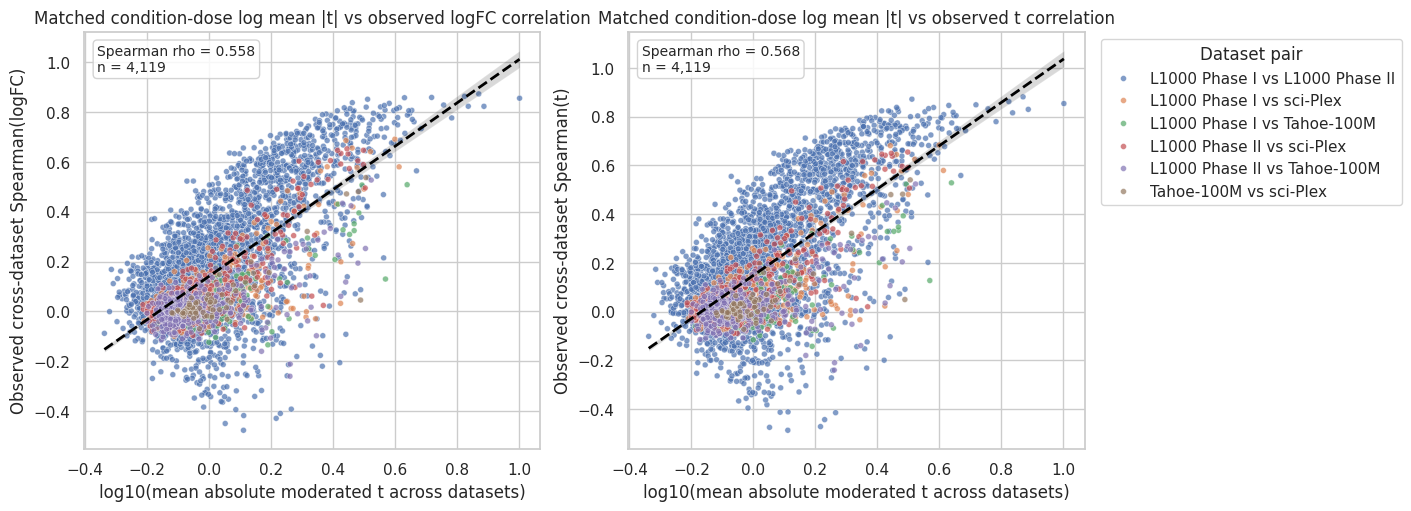

In [21]:
plot_frame = matched_condition_t_strength_summary.copy()
plot_frame = plot_frame.loc[
    np.isfinite(plot_frame["mean_pair_mean_abs_t"].to_numpy(dtype=float))
    & (plot_frame["mean_pair_mean_abs_t"].to_numpy(dtype=float) > 0)
].copy()
plot_frame["log10_mean_pair_mean_abs_t"] = np.log10(plot_frame["mean_pair_mean_abs_t"].to_numpy(dtype=float))
plot_frame["dataset_pair"] = plot_frame["dataset_a"].map(pretty_label) + " vs " + plot_frame["dataset_b"].map(pretty_label)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

sns.scatterplot(
    data=plot_frame,
    x="log10_mean_pair_mean_abs_t",
    y="mean_observed_spearman_logfc",
    hue="dataset_pair",
    alpha=0.7,
    s=18,
    ax=axes[0],
)
sns.regplot(
    data=plot_frame,
    x="log10_mean_pair_mean_abs_t",
    y="mean_observed_spearman_logfc",
    scatter=False,
    color="black",
    line_kws={"linewidth": 2.0, "linestyle": "--"},
    ax=axes[0],
)
logfc_rho = safe_column_spearman(plot_frame, "log10_mean_pair_mean_abs_t", "mean_observed_spearman_logfc")
logfc_subset = plot_frame[["log10_mean_pair_mean_abs_t", "mean_observed_spearman_logfc"]].replace([np.inf, -np.inf], np.nan).dropna()
axes[0].text(
    0.03,
    0.97,
    f"Spearman rho = {logfc_rho:.3f}\nn = {len(logfc_subset):,}",
    transform=axes[0].transAxes,
    ha="left",
    va="top",
    fontsize=10,
    bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "alpha": 0.85, "edgecolor": "0.8"},
)
axes[0].set_title("Matched condition-dose log mean |t| vs observed logFC correlation")
axes[0].set_xlabel("log10(mean absolute moderated t across datasets)")
axes[0].set_ylabel("Observed cross-dataset Spearman(logFC)")

sns.scatterplot(
    data=plot_frame,
    x="log10_mean_pair_mean_abs_t",
    y="mean_observed_spearman_t",
    hue="dataset_pair",
    alpha=0.7,
    s=18,
    ax=axes[1],
)
sns.regplot(
    data=plot_frame,
    x="log10_mean_pair_mean_abs_t",
    y="mean_observed_spearman_t",
    scatter=False,
    color="black",
    line_kws={"linewidth": 2.0, "linestyle": "--"},
    ax=axes[1],
)
t_rho = safe_column_spearman(plot_frame, "log10_mean_pair_mean_abs_t", "mean_observed_spearman_t")
t_subset = plot_frame[["log10_mean_pair_mean_abs_t", "mean_observed_spearman_t"]].replace([np.inf, -np.inf], np.nan).dropna()
axes[1].text(
    0.03,
    0.97,
    f"Spearman rho = {t_rho:.3f}\nn = {len(t_subset):,}",
    transform=axes[1].transAxes,
    ha="left",
    va="top",
    fontsize=10,
    bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "alpha": 0.85, "edgecolor": "0.8"},
)
axes[1].set_title("Matched condition-dose log mean |t| vs observed t correlation")
axes[1].set_xlabel("log10(mean absolute moderated t across datasets)")
axes[1].set_ylabel("Observed cross-dataset Spearman(t)")

handles, labels = axes[1].get_legend_handles_labels()
if axes[0].legend_ is not None:
    axes[0].legend_.remove()
axes[1].legend(handles=handles, labels=labels, title="Dataset pair", bbox_to_anchor=(1.02, 1), loc="upper left")

t_strength_scatter_path = OUTPUT_DIR / "matched_condition_log10_mean_abs_t_vs_observed_spearman_scatter.pdf"
fig.savefig(t_strength_scatter_path, bbox_inches="tight")
print(f"Saved plot to {t_strength_scatter_path}")

t_strength_scatter_description_path = OUTPUT_DIR / "matched_condition_log10_mean_abs_t_vs_observed_spearman_scatter_description.txt"
description_lines = [
    "Plot: matched-condition perturbation strength vs cross-dataset signature similarity.",
    "",
    f"Source table: {matched_pair_metrics_path}",
    f"Output plot: {t_strength_scatter_path}",
    f"Number of plotted matched condition-dose points: {len(plot_frame):,}",
    "",
    "Generation steps:",
    "1. Start from matched_sample_pair_metrics.tsv, which contains precomputed pairwise signature-similarity metrics for matched sample pairs across datasets.",
    "2. Aggregate sample-pair rows to matched condition-dose rows grouped by dataset_a, dataset_b, cell_type, time_key, pubchem_cid, left_dose_key, right_dose_key, and matched_condition_key.",
    "3. For each matched condition-dose row, average pair_mean_abs_t, observed_spearman_logfc, and observed_spearman_t over the available matched sample pairs.",
    "4. Keep rows with finite, positive mean_pair_mean_abs_t and plot log10(mean_pair_mean_abs_t) on the x-axis.",
    "5. Draw two scatter panels: observed cross-dataset Spearman(logFC) on the left and observed cross-dataset Spearman(moderated t) on the right.",
    "6. Color points by dataset pair and overlay a dashed black linear regression trend line for visual orientation.",
    "7. Report Spearman rho in each panel using the plotted matched condition-dose points, after dropping non-finite x/y values.",
    "",
    "What the plot shows:",
    f"- Left panel: association between log10 mean absolute moderated t and observed cross-dataset Spearman(logFC); Spearman rho = {logfc_rho:.3f}, n = {len(logfc_subset):,}.",
    f"- Right panel: association between log10 mean absolute moderated t and observed cross-dataset Spearman(moderated t); Spearman rho = {t_rho:.3f}, n = {len(t_subset):,}.",
    "- Higher mean absolute moderated t corresponds to stronger perturbation signal across the two datasets for a matched compound, cell type, time, and dose pair.",
    "- The positive Spearman correlations indicate that stronger perturbation signals tend to be more reproducible across datasets, but the scatter remains broad, so t-strength is only a partial explanation of cross-dataset similarity.",
    "- The figure is descriptive and uses already precomputed signature-similarity outputs; it does not recompute signatures or add uncertainty intervals.",
]
t_strength_scatter_description_path.write_text("\n".join(description_lines) + "\n")
print(f"Saved plot description to {t_strength_scatter_description_path}")
plt.show()


Optional cleanup:

```python
close_all_line_sources()
```


**Dataset-Pair Heatmaps**

These heatmaps summarize the dataset-pair means for `Spearman(logFC)` at three levels:
- observed cross-dataset score
- pair baseline score
- observed minus baseline pair score

They use the same dataset labels and lower-triangular layout as [plot_overlap_heatmaps.ipynb](./plot_overlap_heatmaps.ipynb). The diagonal is masked because these are cross-dataset summaries only.

In [22]:
HEATMAP_OUTPUT_PATHS = {
    "mean_observed_spearman_logfc": OUTPUT_DIR / "dataset_pair_mean_observed_spearman_logfc_heatmap.pdf",
    "mean_baseline_pair_spearman_logfc": OUTPUT_DIR / "dataset_pair_mean_baseline_pair_spearman_logfc_heatmap.pdf",
    "mean_delta_pair_mean_spearman_logfc": OUTPUT_DIR / "dataset_pair_mean_delta_pair_mean_spearman_logfc_heatmap.pdf",
}


def build_symmetric_pair_metric_matrix(
    summary_frame: pd.DataFrame,
    value_col: str,
    dataset_order: list[str],
) -> pd.DataFrame:
    matrix = pd.DataFrame(np.nan, index=dataset_order, columns=dataset_order, dtype=float)
    for _, row in summary_frame.iterrows():
        dataset_a = str(row["dataset_a"])
        dataset_b = str(row["dataset_b"])
        if dataset_a not in matrix.index or dataset_b not in matrix.columns:
            continue
        value = pd.to_numeric(pd.Series([row[value_col]]), errors="coerce").iloc[0]
        matrix.loc[dataset_a, dataset_b] = value
        matrix.loc[dataset_b, dataset_a] = value
    return matrix


heatmap_dataset_order = [dataset_name for dataset_name in DATASET_ORDER if dataset_name in active_datasets]

observed_baseline_values = pd.concat(
    [
        pair_metric_summary["mean_observed_spearman_logfc"],
        pair_metric_summary["mean_baseline_pair_spearman_logfc"],
    ],
    ignore_index=True,
).replace([np.inf, -np.inf], np.nan)
observed_baseline_values = observed_baseline_values.dropna()
if observed_baseline_values.empty:
    observed_baseline_vmin = None
    observed_baseline_vmax = None
else:
    observed_baseline_vmin = float(observed_baseline_values.min())
    observed_baseline_vmax = float(observed_baseline_values.max())


delta_values = (
    pair_metric_baseline_adjusted_summary["mean_delta_pair_mean_spearman_logfc"]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)
if delta_values.empty:
    delta_abs_max = None
else:
    delta_abs_max = float(np.nanmax(np.abs(delta_values.to_numpy(dtype=float))))



def plot_pair_metric_heatmap(
    summary_frame: pd.DataFrame,
    value_col: str,
    title: str,
    cmap: str,
    output_path: Path,
    *,
    dataset_order: Optional[list[str]] = None,
    vmin: Optional[float] = None,
    vmax: Optional[float] = None,
    center: Optional[float] = None,
    cbar_label: Optional[str] = None,
):
    dataset_order = dataset_order or heatmap_dataset_order
    matrix = build_symmetric_pair_metric_matrix(summary_frame, value_col, dataset_order)
    display_matrix = matrix.rename(index=pretty_label, columns=pretty_label).iloc[1:, :-1]
    mask = np.triu(np.ones(display_matrix.shape, dtype=bool), k=1)

    fig_width = max(5.5, 1.35 * len(display_matrix.columns))
    fig_height = max(4.5, 1.15 * len(display_matrix.index))
    fig, ax = plt.subplots(figsize=(fig_width, fig_height), constrained_layout=True)
    sns.heatmap(
        display_matrix,
        mask=mask,
        annot=True,
        fmt=".3f",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        center=center,
        linewidths=0.5,
        linecolor="white",
        square=True,
        cbar_kws={"shrink": 0.85},
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    ax.grid(False)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, bbox_inches="tight")
    plt.show()
    print(f"Saved heatmap to {output_path}")


print("Heatmap datasets:", ", ".join(pretty_label(dataset_name) for dataset_name in heatmap_dataset_order))


Heatmap datasets: L1000 Phase I, L1000 Phase II, Tahoe-100M, sci-Plex


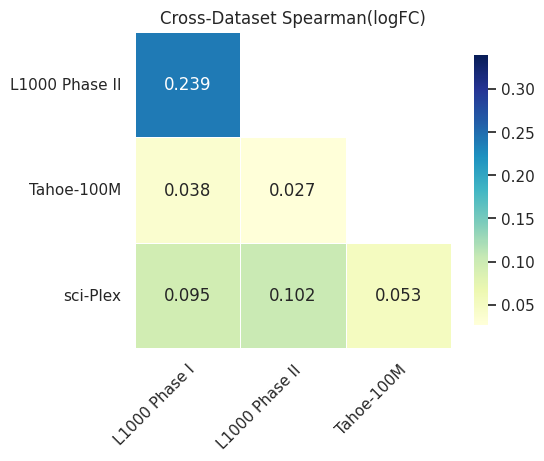

Saved heatmap to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_signature_similarity_group_rep/l1000_phase1__l1000_phase2__tahoe__novartis_batch_2500__vcpi_0001__vcpi_0002__sciplex__op3/dataset_pair_mean_observed_spearman_logfc_heatmap.pdf


In [23]:
plot_pair_metric_heatmap(
    pair_metric_summary,
    value_col="mean_observed_spearman_logfc",
    title="Cross-Dataset Spearman(logFC)",
    cmap="YlGnBu",
    output_path=HEATMAP_OUTPUT_PATHS["mean_observed_spearman_logfc"],
    dataset_order=heatmap_dataset_order,
    vmin=observed_baseline_vmin,
    vmax=observed_baseline_vmax,
    cbar_label="Mean observed Spearman(logFC)",
)


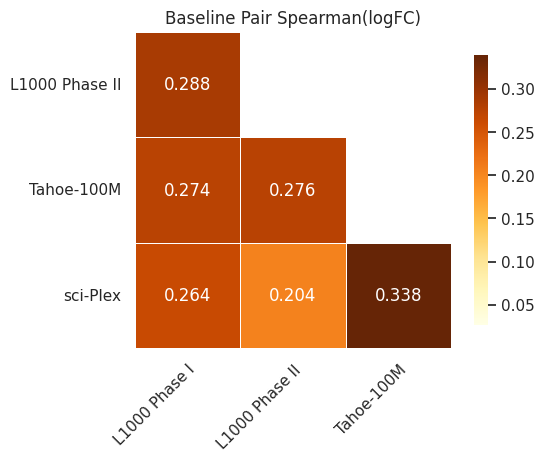

Saved heatmap to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_signature_similarity_group_rep/l1000_phase1__l1000_phase2__tahoe__novartis_batch_2500__vcpi_0001__vcpi_0002__sciplex__op3/dataset_pair_mean_baseline_pair_spearman_logfc_heatmap.pdf


In [24]:
plot_pair_metric_heatmap(
    pair_metric_summary,
    value_col="mean_baseline_pair_spearman_logfc",
    title="Baseline Pair Spearman(logFC)",
    cmap="YlOrBr",
    output_path=HEATMAP_OUTPUT_PATHS["mean_baseline_pair_spearman_logfc"],
    dataset_order=heatmap_dataset_order,
    vmin=observed_baseline_vmin,
    vmax=observed_baseline_vmax,
    cbar_label="Mean baseline pair Spearman(logFC)",
)


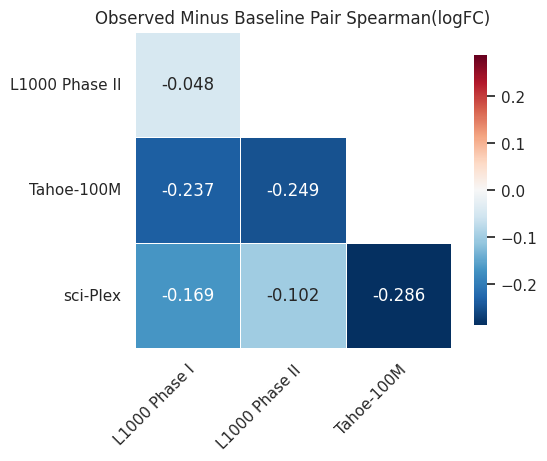

Saved heatmap to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_signature_similarity_group_rep/l1000_phase1__l1000_phase2__tahoe__novartis_batch_2500__vcpi_0001__vcpi_0002__sciplex__op3/dataset_pair_mean_delta_pair_mean_spearman_logfc_heatmap.pdf


In [25]:
plot_pair_metric_heatmap(
    pair_metric_baseline_adjusted_summary,
    value_col="mean_delta_pair_mean_spearman_logfc",
    title="Observed Minus Baseline Pair Spearman(logFC)",
    cmap="RdBu_r",
    output_path=HEATMAP_OUTPUT_PATHS["mean_delta_pair_mean_spearman_logfc"],
    dataset_order=heatmap_dataset_order,
    vmin=None if delta_abs_max is None else -delta_abs_max,
    vmax=None if delta_abs_max is None else delta_abs_max,
    center=0.0,
    cbar_label="Mean delta Spearman(logFC)",
)


## Per-peer and target-side baselines for all-gene logFC Spearman

This section mirrors the peer-baseline analysis in
[overlap_group_rep_deg_metrics_reviewer_additions.ipynb](./overlap_group_rep_deg_metrics_reviewer_additions.ipynb)
for the all-gene `logFC` Spearman metric, which is the whole-signature counterpart of the
DEG-restricted agreement tables.

Everything above is unchanged. The same matched sample pairs are rescored against four
baselines -- `source_centroid` (the published one, recomputed as a parity check),
`target_centroid` (the same mean built from the other dataset's peers), `source_peer`
(every own-dataset peer scored separately), and `target_peer` (every other-dataset peer
scored separately) -- with the mean, standard deviation, fraction of peer scores below the
observed score, and the add-one corrected percentile `(1 + #{m(i, x) < m(i, j)}) / (K + 1)`
reported for the per-peer variants.

In [26]:
import importlib
import sys

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import scripts.notebook_cache as notebook_cache_module
import scripts.peer_baselines as peer_baselines_module

# Support resuming this section in a kernel that imported the pre-optimization helpers.
importlib.reload(notebook_cache_module)
importlib.reload(peer_baselines_module)
cached_frame = notebook_cache_module.cached_frame
cache_summary = notebook_cache_module.cache_summary
resumable_context_frame = notebook_cache_module.resumable_context_frame
stable_json_fingerprint = notebook_cache_module.stable_json_fingerprint
frame_identity_fingerprint = notebook_cache_module.frame_identity_fingerprint

from scripts.peer_baselines import (
    empty_peer_score_summary,
    prepare_spearman_rows,
    select_peer_indices,
    spearman_against_prepared_peers,
    summarize_peer_scores,
)

# Table 6 reports all-gene logFC Spearman on the pairwise shared gene set.
PEER_BASELINE_VARIANTS = (
    "source_centroid",
    "target_centroid",
    "source_peer",
    "target_peer",
)
MAX_BASELINE_PEERS: Optional[int] = 512
PEER_SAMPLING_SEED = 20260505


def baseline_peer_stratum(
    source: LineSource,
    *,
    dose_key: str,
    time_key: str,
) -> tuple[np.ndarray, np.ndarray]:
    """Load one line/dose/time stratum's logFC matrix and compound labels, once.

    A sample's peer set is this stratum minus its own compound, so every query in the
    stratum shares the same underlying matrix. Caching per stratum rather than per query
    turns thousands of reads of the same rows into one.
    """
    stratum = source.get_value_stratum("logFC", str(dose_key), str(time_key))
    return stratum.compounds, stratum.values


def baseline_peer_selection(
    source: LineSource,
    obs_id: str,
    *,
    pubchem_cid: str,
    dose_key: str,
    time_key: str,
) -> tuple[SignatureStratum, np.ndarray, int]:
    """Return the shared stratum and deterministic peer row positions.

    The peer set is identical to the one `LineSource.get_baseline_vector` averages: same
    line file, same dose key, same time key, different `pubchem_cid`. Returns the matrix in
    unique-gene order with the total and retained peer counts, so a capped run records how
    many peers existed as well as how many were scored.

    `MAX_BASELINE_PEERS` is read at call time rather than bound as a default argument, so
    changing the cap is enough to rescore after invalidating the peer stage cache.
    """
    row_pos = source.resolve_row_pos(
        obs_id,
        pubchem_cid=pubchem_cid,
        dose_key=dose_key,
        time_key=time_key,
    )
    row = source.obs.loc[row_pos]
    compounds, stratum_matrix = baseline_peer_stratum(
        source,
        dose_key=str(row["dose_key"]),
        time_key=str(row["time_key"]),
    )

    peer_positions = np.flatnonzero(compounds != str(row["pubchem_cid"]))
    n_total_peers = int(peer_positions.size)
    if n_total_peers == 0:
        return source.get_value_stratum("logFC", str(row["dose_key"]), str(row["time_key"])), np.empty(0, dtype=np.int64), 0

    selected = select_peer_indices(
        n_total_peers,
        MAX_BASELINE_PEERS,
        "|".join(
            [
                source.dataset_name,
                source.cell_type,
                str(row["dose_key"]),
                str(row["time_key"]),
                str(row["pubchem_cid"]),
            ]
        ),
        sampling_seed=PEER_SAMPLING_SEED,
    )
    chosen = peer_positions[selected]
    stratum = source.get_value_stratum("logFC", str(row["dose_key"]), str(row["time_key"]))
    return stratum, chosen, n_total_peers


def baseline_peer_logfc_matrix(
    source: LineSource,
    obs_id: str,
    *,
    pubchem_cid: str,
    dose_key: str,
    time_key: str,
) -> tuple[np.ndarray, int, int]:
    stratum, chosen, n_total = baseline_peer_selection(
        source,
        obs_id,
        pubchem_cid=pubchem_cid,
        dose_key=dose_key,
        time_key=time_key,
    )
    return stratum.values[chosen], n_total, int(chosen.size)


def compute_peer_baseline_record(match_row: pd.Series) -> dict[str, object]:
    """Score one matched sample pair's all-gene logFC Spearman against four baselines.

      source_centroid -- the published baseline: mean of the sample's own-dataset peers.
      target_centroid -- the same mean built in the other dataset.
      source_peer     -- every own-dataset peer scored separately.
      target_peer     -- every other-dataset peer scored separately.
    """
    dataset_a = str(match_row["dataset_a"])
    dataset_b = str(match_row["dataset_b"])
    cell_type = str(match_row["cell_type"])
    left_source = get_line_source(dataset_a, cell_type)
    right_source = get_line_source(dataset_b, cell_type)
    shared_genes, left_gene_pos, right_gene_pos = shared_gene_positions(left_source, right_source)
    if shared_genes.size < 2:
        raise ValueError(
            f"Fewer than two shared genes for {dataset_a} vs {dataset_b} / {cell_type}"
        )

    left_obs_id = str(match_row["left_obs_id"])
    right_obs_id = str(match_row["right_obs_id"])
    pubchem_cid = str(match_row["pubchem_cid"])
    time_key = str(match_row["time_key"])
    left_lookup = {
        "pubchem_cid": pubchem_cid,
        "dose_key": str(match_row["left_dose_key"]),
        "time_key": time_key,
    }
    right_lookup = {
        "pubchem_cid": pubchem_cid,
        "dose_key": str(match_row["right_dose_key"]),
        "time_key": time_key,
    }

    left_logfc = left_source.get_vector(left_obs_id, "logFC", **left_lookup)[left_gene_pos]
    right_logfc = right_source.get_vector(right_obs_id, "logFC", **right_lookup)[right_gene_pos]

    left_centroid_full = left_source.get_baseline_vector(left_obs_id, "logFC", **left_lookup)
    right_centroid_full = right_source.get_baseline_vector(right_obs_id, "logFC", **right_lookup)
    left_centroid = None if left_centroid_full is None else np.asarray(left_centroid_full, dtype=np.float32)[left_gene_pos]
    right_centroid = None if right_centroid_full is None else np.asarray(right_centroid_full, dtype=np.float32)[right_gene_pos]

    left_peer_stratum, left_peer_rows, left_n_total_peers = baseline_peer_selection(
        left_source,
        left_obs_id,
        **left_lookup,
    )
    right_peer_stratum, right_peer_rows, right_n_total_peers = baseline_peer_selection(
        right_source,
        right_obs_id,
        **right_lookup,
    )
    left_n_scored_peers = int(left_peer_rows.size)
    right_n_scored_peers = int(right_peer_rows.size)
    left_peers = left_peer_stratum.values[left_peer_rows][:, left_gene_pos]
    right_peers = right_peer_stratum.values[right_peer_rows][:, right_gene_pos]
    prepared_peer_matrices = {
        "left": (left_peer_stratum.prepared_spearman(left_gene_pos), left_peer_rows),
        "right": (right_peer_stratum.prepared_spearman(right_gene_pos), right_peer_rows),
    }

    # The peer set must be exactly the set the published centroid averaged. Comparing
    # counts checks that membership without recomputing the centroid mean per pair, and it
    # keeps working when MAX_BASELINE_PEERS caps how many peers are scored.
    for side, source, obs_id, lookup, n_total in (
        ("left", left_source, left_obs_id, left_lookup, left_n_total_peers),
        ("right", right_source, right_obs_id, right_lookup, right_n_total_peers),
    ):
        expected_peers = int(source.baseline_peer_count(obs_id, **lookup))
        if int(n_total) != expected_peers:
            raise AssertionError(
                f"Peer set does not match the published centroid for {side} side of "
                f"{dataset_a} vs {dataset_b} / {cell_type} / {pubchem_cid}: "
                f"{int(n_total)} peers vs {expected_peers} averaged by get_baseline_vector."
            )

    observed = signed_spearman(left_logfc, right_logfc)
    record: dict[str, object] = {
        **match_row.to_dict(),
        "n_common_genes": int(shared_genes.size),
        "left_peer_total_count": left_n_total_peers,
        "right_peer_total_count": right_n_total_peers,
        "left_peer_scored_count": left_n_scored_peers,
        "right_peer_scored_count": right_n_scored_peers,
        "peer_sampling_seed": PEER_SAMPLING_SEED,
        "max_baseline_peers": MAX_BASELINE_PEERS,
        "pb_observed_spearman_logfc": observed,
    }

    side_specs = {
        "left": {
            "sample_logfc": left_logfc,
            "source_centroid": left_centroid,
            "target_centroid": right_centroid,
            "source_peers": left_peers,
            "target_peers": right_peers,
        },
        "right": {
            "sample_logfc": right_logfc,
            "source_centroid": right_centroid,
            "target_centroid": left_centroid,
            "source_peers": right_peers,
            "target_peers": left_peers,
        },
    }

    for variant in PEER_BASELINE_VARIANTS:
        side_values: list[float] = []
        side_sds: list[float] = []
        side_fractions: list[float] = []
        side_percentiles: list[float] = []
        for side, spec in side_specs.items():
            column_stem = f"pb_{variant}_spearman_logfc_{side}"
            if variant.endswith("_centroid"):
                centroid = spec[variant]
                value = (
                    float("nan")
                    if centroid is None
                    else signed_spearman(spec["sample_logfc"], centroid)
                )
                record[column_stem] = value
                side_values.append(value)
                continue

            peer_matrix = spec["source_peers" if variant == "source_peer" else "target_peers"]
            if peer_matrix.shape[0] == 0:
                record.update(empty_peer_score_summary(column_stem))
                side_values.append(float("nan"))
                side_sds.append(float("nan"))
                side_fractions.append(float("nan"))
                side_percentiles.append(float("nan"))
                continue
            prepared_peers, prepared_peer_rows = prepared_peer_matrices[
                "left" if peer_matrix is left_peers else "right"
            ]
            peer_scores = spearman_against_prepared_peers(
                spec["sample_logfc"], prepared_peers, row_indices=prepared_peer_rows
            )
            summary = summarize_peer_scores(observed, peer_scores, column_stem)
            record.update(summary)
            side_values.append(summary[f"{column_stem}_mean_score"])
            side_sds.append(summary[f"{column_stem}_sd_score"])
            side_fractions.append(summary[f"{column_stem}_fraction_below_observed"])
            side_percentiles.append(summary[f"{column_stem}_corrected_percentile"])

        pair_stem = f"pb_{variant}_spearman_logfc_pair"
        pair_value = mean_available(side_values)
        record[pair_stem] = pair_value
        record[f"pb_delta_vs_{variant}_spearman_logfc"] = (
            float("nan")
            if (pd.isna(observed) or pd.isna(pair_value))
            else float(observed - pair_value)
        )
        if not variant.endswith("_centroid"):
            record[f"{pair_stem}_sd_score"] = mean_available(side_sds)
            record[f"{pair_stem}_fraction_below_observed"] = mean_available(side_fractions)
            record[f"{pair_stem}_corrected_percentile"] = mean_available(side_percentiles)

    return record


print(f"All-gene logFC per-peer baselines configured with max_peers={MAX_BASELINE_PEERS}")

All-gene logFC per-peer baselines configured with max_peers=512


In [27]:
peer_baseline_unresolved: list[dict[str, object]] = []

PEER_BASELINE_INPUT_FINGERPRINT = stable_json_fingerprint(
    {
        "version": "signature-peer-v4",
        "cap": MAX_BASELINE_PEERS,
        "seed": PEER_SAMPLING_SEED,
        "matched_metrics": frame_identity_fingerprint(
            matched_pair_metrics,
            context_join_columns + ["pubchem_cid", "left_obs_id", "right_obs_id"],
        ),
        "sources": sorted(
            (
                str(path.resolve()),
                int(path.stat().st_size),
                int(path.stat().st_mtime_ns),
            )
            for dataset_name, cell_type in matched_pairs[["dataset_a", "cell_type"]]
            .drop_duplicates()
            .itertuples(index=False, name=None)
            for path in [resolve_line_path(str(dataset_name), str(cell_type))]
        )
        + sorted(
            (
                str(path.resolve()),
                int(path.stat().st_size),
                int(path.stat().st_mtime_ns),
            )
            for dataset_name, cell_type in matched_pairs[["dataset_b", "cell_type"]]
            .drop_duplicates()
            .itertuples(index=False, name=None)
            for path in [resolve_line_path(str(dataset_name), str(cell_type))]
        ),
    }
)
peer_baseline_contexts = [
    (tuple(str(value) for value in context_key), group.copy())
    for context_key, group in matched_pairs.groupby(context_join_columns, sort=False)
]


def build_peer_baseline_context(context_item) -> pd.DataFrame:
    context_key, group = context_item
    dataset_a, dataset_b, cell_type, time_key, left_dose_key, right_dose_key = context_key
    print(
        f"Peer baselines for {pretty_label(dataset_a)} vs {pretty_label(dataset_b)} / {cell_type} / "
        f"time={time_key} / doses={left_dose_key} vs {right_dose_key}: {len(group)} matched sample pairs",
        flush=True,
    )
    records: list[dict[str, object]] = []
    row_progress = notebook_cache_module.ProgressReporter(
        total=len(group),
        label="peer_baseline_rows",
        every=100,
        min_interval_seconds=20.0,
    )
    for _, match_row in group.iterrows():
        try:
            records.append(compute_peer_baseline_record(match_row))
        except KeyError as exc:
            peer_baseline_unresolved.append({**match_row.to_dict(), "error": str(exc)})
        finally:
            row_progress.update(detail=f"{dataset_a} vs {dataset_b} / {cell_type}")
    return pd.DataFrame(records)


def build_peer_baselines() -> pd.DataFrame:
    return resumable_context_frame(
        "peer_baselines",
        OUTPUT_DIR / ".checkpoints" / "peer_baselines",
        peer_baseline_contexts,
        context_key=lambda item: item[0],
        build_context=build_peer_baseline_context,
        fingerprint=PEER_BASELINE_INPUT_FINGERPRINT,
        context_label=lambda item: " / ".join(item[0]),
    )


matched_pair_peer_baselines_path = OUTPUT_DIR / "matched_sample_pair_peer_baselines.tsv"
matched_pair_peer_baselines = cached_frame(
    "peer_baselines",
    matched_pair_peer_baselines_path,
    build_peer_baselines,
    fingerprint=PEER_BASELINE_INPUT_FINGERPRINT,
    required_columns=[
        "pb_observed_spearman_logfc",
        "pb_source_peer_spearman_logfc_pair",
        "pb_source_peer_spearman_logfc_pair_sd_score",
        "pb_target_peer_spearman_logfc_pair",
    ],
)
if matched_pair_peer_baselines.empty:
    raise ValueError("No matched sample pairs could be scored against the per-peer baselines.")

print(f"Scored {len(matched_pair_peer_baselines):,} matched sample pairs")

if peer_baseline_unresolved:
    peer_baseline_unresolved_frame = pd.DataFrame(peer_baseline_unresolved)
    peer_baseline_unresolved_path = OUTPUT_DIR / "unresolved_peer_baseline_pairs.tsv"
    peer_baseline_unresolved_frame.to_csv(peer_baseline_unresolved_path, sep="\t", index=False)
    print(
        f"Skipped {len(peer_baseline_unresolved_frame):,} matched sample pairs; "
        f"saved details to {peer_baseline_unresolved_path}"
    )

# Parity: the recomputed observed and source-centroid columns must reproduce the published
# ones, so any change in the reported deltas comes from the new baselines only.
peer_baseline_join_columns = [
    "dataset_a",
    "dataset_b",
    "cell_type",
    "time_key",
    "pubchem_cid",
    "left_obs_id",
    "right_obs_id",
    "left_dose_key",
    "right_dose_key",
]
parity_column_pairs = [
    ("pb_observed_spearman_logfc", "observed_spearman_logfc"),
    ("pb_source_centroid_spearman_logfc_left", "left_baseline_spearman_logfc"),
    ("pb_source_centroid_spearman_logfc_right", "right_baseline_spearman_logfc"),
    ("pb_source_centroid_spearman_logfc_pair", "baseline_pair_mean_spearman_logfc"),
]
parity_frame = matched_pair_peer_baselines.merge(
    matched_pair_metrics[peer_baseline_join_columns + [published for _, published in parity_column_pairs]],
    on=peer_baseline_join_columns,
    how="inner",
    validate="one_to_one",
)
if len(parity_frame) != len(matched_pair_peer_baselines):
    raise AssertionError(
        f"Parity join matched {len(parity_frame):,} of {len(matched_pair_peer_baselines):,} peer-baseline rows."
    )

parity_rows: list[dict[str, object]] = []
for recomputed_column, published_column in parity_column_pairs:
    recomputed = parity_frame[recomputed_column].to_numpy(dtype=np.float64)
    published = parity_frame[published_column].to_numpy(dtype=np.float64)
    both_finite = np.isfinite(recomputed) & np.isfinite(published)
    parity_rows.append(
        {
            "recomputed_column": recomputed_column,
            "published_column": published_column,
            "n_both_finite": int(both_finite.sum()),
            "n_finite_mismatch": int(np.sum(np.isfinite(recomputed) != np.isfinite(published))),
            "max_abs_diff": (
                float(np.max(np.abs(recomputed[both_finite] - published[both_finite])))
                if both_finite.any()
                else float("nan")
            ),
        }
    )
peer_baseline_parity = pd.DataFrame(parity_rows)
display(peer_baseline_parity)

if int(peer_baseline_parity["n_finite_mismatch"].sum()) > 0:
    raise AssertionError("Recomputed and published columns disagree on which rows are defined.")
worst_parity_diff = float(np.nanmax(peer_baseline_parity["max_abs_diff"].to_numpy(dtype=np.float64)))
if worst_parity_diff > 1e-6:
    raise AssertionError(
        f"Recomputed source-centroid parity check failed with max abs diff {worst_parity_diff:.3g}."
    )
print(f"Parity check passed; largest absolute difference {worst_parity_diff:.3g}.")

Peer baselines for L1000 Phase I vs L1000 Phase II / CVCL_0023 / time=24 / doses=10 vs 10: 5788 matched sample pairs
Peer baselines for L1000 Phase I vs L1000 Phase II / CVCL_0031 / time=24 / doses=10 vs 10: 7803 matched sample pairs
Peer baselines for L1000 Phase I vs L1000 Phase II / CVCL_0031 / time=24 / doses=2 vs 3.33: 746 matched sample pairs
Peer baselines for L1000 Phase I vs L1000 Phase II / CVCL_0031 / time=24 / doses=0.4 vs 0.37037: 278 matched sample pairs
Peer baselines for L1000 Phase I vs L1000 Phase II / CVCL_0031 / time=24 / doses=0.08 vs 0.12: 807 matched sample pairs
Peer baselines for L1000 Phase I vs L1000 Phase II / CVCL_0035 / time=24 / doses=10 vs 10: 5660 matched sample pairs
Peer baselines for L1000 Phase I vs L1000 Phase II / CVCL_U602 / time=24 / doses=10 vs 10: 763 matched sample pairs
Peer baselines for L1000 Phase I vs L1000 Phase II / NEU / time=24 / doses=10 vs 10: 573 matched sample pairs
Peer baselines for L1000 Phase I vs L1000 Phase II / NPC / time=

,recomputed_column,published_column,n_both_finite,n_finite_mismatch,max_abs_diff
0,pb_observed_spearman_logfc,observed_spearman_logfc,58734,0,0.0
1,pb_source_centroid_spearman_logfc_left,left_baseline_spearman_logfc,58606,0,0.0
2,pb_source_centroid_spearman_logfc_right,right_baseline_spearman_logfc,58647,0,0.0
3,pb_source_centroid_spearman_logfc_pair,baseline_pair_mean_spearman_logfc,58734,0,0.0


Parity check passed; largest absolute difference 0.


In [28]:
peer_baseline_value_columns = [
    column_name
    for column_name in matched_pair_peer_baselines.columns
    if column_name.startswith("pb_")
    or column_name.endswith("_peer_total_count")
    or column_name.endswith("_peer_scored_count")
    or column_name == "n_common_genes"
]

peer_drug_line_time_agg: dict[str, tuple[str, object]] = {
    "n_matched_sample_pairs": ("left_obs_id", "size"),
    "n_matching_conditions": ("matched_condition_key", "nunique"),
}
for column_name in peer_baseline_value_columns:
    peer_drug_line_time_agg[f"mean_{column_name}"] = (column_name, "mean")

peer_drug_line_time_summary = (
    matched_pair_peer_baselines.groupby(drug_line_time_group_columns, as_index=False)
    .agg(**peer_drug_line_time_agg)
    .sort_values(drug_line_time_group_columns)
    .reset_index(drop=True)
)

peer_summary_mean_columns = [
    column_name
    for column_name in peer_drug_line_time_summary.columns
    if column_name.startswith("mean_")
]

peer_pair_agg: dict[str, tuple[str, object]] = {
    "n_matched_sample_pairs": ("n_matched_sample_pairs", "sum"),
    "n_matching_lines": ("cell_type", "nunique"),
    "n_matching_drugs": ("pubchem_cid", "nunique"),
    "n_matching_conditions": ("n_matching_conditions", "sum"),
    "n_matching_drug_line_times": ("pubchem_cid", "size"),
}
for column_name in peer_summary_mean_columns:
    peer_pair_agg[column_name] = (column_name, "mean")

peer_pair_summary = (
    peer_drug_line_time_summary.groupby(["dataset_a", "dataset_b"], as_index=False)
    .agg(**peer_pair_agg)
    .sort_values(["dataset_a", "dataset_b"])
    .reset_index(drop=True)
)

peer_line_agg: dict[str, tuple[str, object]] = {
    "n_matched_sample_pairs": ("n_matched_sample_pairs", "sum"),
    "n_matching_drugs": ("pubchem_cid", "nunique"),
    "n_matching_conditions": ("n_matching_conditions", "sum"),
    "n_matching_drug_line_times": ("pubchem_cid", "size"),
}
for column_name in peer_summary_mean_columns:
    peer_line_agg[column_name] = (column_name, "mean")

peer_line_summary = (
    peer_drug_line_time_summary.groupby(["dataset_a", "dataset_b", "cell_type"], as_index=False)
    .agg(**peer_line_agg)
    .sort_values(["dataset_a", "dataset_b", "cell_type"])
    .reset_index(drop=True)
)

for filename, frame in {
    "matched_drug_line_time_peer_baseline_summary.tsv": peer_drug_line_time_summary,
    "dataset_pair_peer_baseline_summary.tsv": peer_pair_summary,
    "dataset_pair_line_peer_baseline_summary.tsv": peer_line_summary,
}.items():
    output_path = OUTPUT_DIR / filename
    frame.to_csv(output_path, sep="\t", index=False)
    print(f"Saved peer-baseline summary to {output_path}")

peer_baseline_ci_stems = ["pb_observed_spearman_logfc"]
for variant in PEER_BASELINE_VARIANTS:
    peer_baseline_ci_stems.append(f"pb_{variant}_spearman_logfc_pair")
    peer_baseline_ci_stems.append(f"pb_delta_vs_{variant}_spearman_logfc")
    if not variant.endswith("_centroid"):
        peer_baseline_ci_stems.append(f"pb_{variant}_spearman_logfc_pair_sd_score")
        peer_baseline_ci_stems.append(f"pb_{variant}_spearman_logfc_pair_fraction_below_observed")
        peer_baseline_ci_stems.append(f"pb_{variant}_spearman_logfc_pair_corrected_percentile")

peer_baseline_ci_metrics = {stem: f"mean_{stem}" for stem in peer_baseline_ci_stems}
missing_ci_columns = sorted(
    set(peer_baseline_ci_metrics.values()) - set(peer_drug_line_time_summary.columns)
)
if missing_ci_columns:
    raise KeyError(f"Missing peer-baseline CI columns: {missing_ci_columns}")

def build_peer_ci() -> pd.DataFrame:
    peer_baseline_cluster_bca_ci = pd.concat(
        [
            cluster_bca_nested_mean_ci_table(
                peer_drug_line_time_summary,
                group_cols=["dataset_a", "dataset_b"],
                metric_cols=peer_baseline_ci_metrics,
                cluster_col="pubchem_cid",
                n_boot=BOOTSTRAP_ITERATIONS,
                seed=BOOTSTRAP_RANDOM_SEED,
                summary_level="peer_baseline_dataset_pair",
            ),
            cluster_bca_nested_mean_ci_table(
                peer_drug_line_time_summary,
                group_cols=["dataset_a", "dataset_b", "cell_type"],
                metric_cols=peer_baseline_ci_metrics,
                cluster_col="pubchem_cid",
                n_boot=BOOTSTRAP_ITERATIONS,
                seed=BOOTSTRAP_RANDOM_SEED,
                summary_level="peer_baseline_dataset_pair_line",
            ),
        ],
        ignore_index=True,
    )
    return peer_baseline_cluster_bca_ci


peer_baseline_cluster_bca_ci_path = OUTPUT_DIR / "peer_baseline_cluster_bca_ci.tsv"
peer_baseline_cluster_bca_ci = cached_frame("peer_ci", peer_baseline_cluster_bca_ci_path, build_peer_ci)

peer_baseline_ci_ranges = summarize_ci_half_width_ranges(peer_baseline_cluster_bca_ci)
peer_baseline_ci_ranges_path = OUTPUT_DIR / "peer_baseline_cluster_bca_ci_ranges.tsv"
peer_baseline_ci_ranges.to_csv(peer_baseline_ci_ranges_path, sep="\t", index=False)
print(f"Saved peer-baseline CI half-width ranges to {peer_baseline_ci_ranges_path}")


def format_ci_cell(row: pd.Series) -> str:
    if not np.isfinite(row["mean"]):
        return ""
    if not (np.isfinite(row["ci_low"]) and np.isfinite(row["ci_high"])):
        return f"{row['mean']:.3f}"
    return f"{row['mean']:.3f} [{row['ci_low']:.3f}, {row['ci_high']:.3f}]"


pair_level_ci = peer_baseline_cluster_bca_ci.loc[
    peer_baseline_cluster_bca_ci["summary_level"] == "peer_baseline_dataset_pair"
].copy()
pair_level_ci["cell"] = pair_level_ci.apply(format_ci_cell, axis=1)
ci_lookup = {
    (str(row["dataset_a"]), str(row["dataset_b"]), str(row["metric"])): str(row["cell"])
    for _, row in pair_level_ci.iterrows()
}

rebuttal_rows: list[dict[str, object]] = []
for _, pair_row in peer_pair_summary.iterrows():
    dataset_a = str(pair_row["dataset_a"])
    dataset_b = str(pair_row["dataset_b"])
    record: dict[str, object] = {
        "dataset_a": pretty_label(dataset_a),
        "dataset_b": pretty_label(dataset_b),
        "metric": "all_gene_spearman_logfc",
        "n_compounds": int(pair_row["n_matching_drugs"]),
        "n_drug_line_times": int(pair_row["n_matching_drug_line_times"]),
        "observed": ci_lookup.get((dataset_a, dataset_b, "pb_observed_spearman_logfc"), ""),
    }
    for variant in PEER_BASELINE_VARIANTS:
        record[variant] = ci_lookup.get(
            (dataset_a, dataset_b, f"pb_{variant}_spearman_logfc_pair"), ""
        )
        record[f"delta_vs_{variant}"] = ci_lookup.get(
            (dataset_a, dataset_b, f"pb_delta_vs_{variant}_spearman_logfc"), ""
        )
    for variant in ("source_peer", "target_peer"):
        record[f"{variant}_fraction_below_observed"] = ci_lookup.get(
            (dataset_a, dataset_b, f"pb_{variant}_spearman_logfc_pair_fraction_below_observed"), ""
        )
        record[f"{variant}_corrected_percentile"] = ci_lookup.get(
            (dataset_a, dataset_b, f"pb_{variant}_spearman_logfc_pair_corrected_percentile"), ""
        )
    record["mean_peers_source"] = float(
        np.nanmean(
            [
                pair_row.get("mean_left_peer_scored_count", np.nan),
                pair_row.get("mean_right_peer_scored_count", np.nan),
            ]
        )
    )
    rebuttal_rows.append(record)

peer_baseline_rebuttal_table = pd.DataFrame(rebuttal_rows)
peer_baseline_rebuttal_table_path = OUTPUT_DIR / "peer_baseline_rebuttal_table.tsv"
peer_baseline_rebuttal_table.to_csv(peer_baseline_rebuttal_table_path, sep="\t", index=False)
print(f"Saved rebuttal-ready peer-baseline table to {peer_baseline_rebuttal_table_path}")
display(peer_baseline_rebuttal_table)

display(cache_summary())

Saved peer-baseline summary to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_signature_similarity_group_rep/l1000_phase1__l1000_phase2__tahoe__novartis_batch_2500__vcpi_0001__vcpi_0002__sciplex__op3/matched_drug_line_time_peer_baseline_summary.tsv
Saved peer-baseline summary to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_signature_similarity_group_rep/l1000_phase1__l1000_phase2__tahoe__novartis_batch_2500__vcpi_0001__vcpi_0002__sciplex__op3/dataset_pair_peer_baseline_summary.tsv
Saved peer-baseline summary to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_signature_similarity_group_rep/l1000_phase1__l1000_phase2__tahoe__novartis_batch_2500__vcpi_0001__vcpi_0002__sciplex__op3/dataset_pair_line_peer_baseline_summary.tsv
[peer_ci] computed and saved 465 rows to peer_baseline_cluster_bca_ci.tsv
Saved peer-baseline CI half-width ranges to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_signature_similarity_gr

,dataset_a,dataset_b,metric,n_compounds,n_drug_line_times,observed,source_centroid,delta_vs_source_centroid,target_centroid,delta_vs_target_centroid,source_peer,delta_vs_source_peer,target_peer,delta_vs_target_peer,source_peer_fraction_below_observed,source_peer_corrected_percentile,target_peer_fraction_below_observed,target_peer_corrected_percentile,mean_peers_source
0,L1000 Phase I,L1000 Phase II,all_gene_spearman_logfc,257,1060,"0.239 [0.213, 0.272]","0.288 [0.270, 0.307]","-0.048 [-0.067, -0.028]","0.164 [0.146, 0.185]","0.075 [0.060, 0.093]","0.096 [0.090, 0.101]","0.144 [0.119, 0.171]","0.046 [0.041, 0.051]","0.193 [0.169, 0.224]","0.673 [0.646, 0.699]","0.676 [0.650, 0.703]","0.766 [0.743, 0.790]","0.768 [0.745, 0.791]",326.256569
1,L1000 Phase I,sci-Plex,all_gene_spearman_logfc,90,162,"0.095 [0.072, 0.124]","0.264 [0.238, 0.289]","-0.169 [-0.189, -0.146]","0.085 [0.071, 0.100]","0.010 [-0.005, 0.029]","0.070 [0.065, 0.076]","0.024 [0.004, 0.051]","0.021 [0.018, 0.024]","0.074 [0.053, 0.102]","0.515 [0.473, 0.555]","0.518 [0.480, 0.563]","0.672 [0.622, 0.719]","0.674 [0.627, 0.724]",309.753772
2,L1000 Phase I,Tahoe-100M,all_gene_spearman_logfc,86,114,"0.038 [0.020, 0.064]","0.274 [0.253, 0.298]","-0.237 [-0.260, -0.211]","-0.017 [-0.025, -0.008]","0.054 [0.037, 0.076]","0.104 [0.098, 0.111]","-0.067 [-0.085, -0.044]","-0.003 [-0.005, -0.000]","0.041 [0.022, 0.066]","0.349 [0.311, 0.395]","0.351 [0.315, 0.401]","0.622 [0.559, 0.684]","0.623 [0.562, 0.684]",404.412202
3,L1000 Phase II,sci-Plex,all_gene_spearman_logfc,83,127,"0.102 [0.079, 0.133]","0.204 [0.180, 0.228]","-0.102 [-0.121, -0.082]","0.078 [0.064, 0.095]","0.024 [0.009, 0.044]","0.056 [0.051, 0.060]","0.046 [0.025, 0.077]","0.018 [0.015, 0.022]","0.084 [0.061, 0.113]","0.558 [0.522, 0.601]","0.560 [0.524, 0.604]","0.699 [0.656, 0.738]","0.701 [0.661, 0.741]",290.368988
4,L1000 Phase II,Tahoe-100M,all_gene_spearman_logfc,110,134,"0.027 [0.017, 0.043]","0.276 [0.259, 0.292]","-0.249 [-0.266, -0.234]","0.011 [0.005, 0.017]","0.016 [0.004, 0.030]","0.116 [0.112, 0.121]","-0.089 [-0.101, -0.073]","-0.001 [-0.003, 0.000]","0.028 [0.018, 0.045]","0.286 [0.259, 0.318]","0.288 [0.263, 0.324]","0.595 [0.558, 0.635]","0.596 [0.562, 0.638]",419.723450
5,Tahoe-100M,sci-Plex,all_gene_spearman_logfc,23,23,"0.053 [0.024, 0.119]","0.338 [0.314, 0.357]","-0.286 [-0.317, -0.227]","0.016 [0.003, 0.032]","0.036 [0.013, 0.087]","0.134 [0.125, 0.142]","-0.082 [-0.111, -0.012]","0.003 [-0.002, 0.008]","0.050 [0.022, 0.112]","0.324 [0.262, 0.427]","0.327 [0.264, 0.437]","0.671 [0.603, 0.754]","0.672 [0.603, 0.756]",278.440217


,stage,status
0,peer_baselines,computed
1,peer_ci,computed


## W4: per-gene population standardization at two scopes

This additive sensitivity analysis keeps every raw-logFC result above unchanged. For each
dataset, it fits gene-wise population statistics both within each cellular context and
across all eligible cell types (`ddof=0`), then reports both transforms before computing
Table 6 all-gene logFC Spearman.

The same matched pairs, shared-gene sets, peer membership, peer cap, aggregation, and
compound-clustered BCa procedure are reused. Source/target centroids and individual peers
are all transformed with their own source-context statistics. This is a condition-level
analogue of the gene-wise population axis in L1000 Level 4, not a reconstruction of its
plate-level raw-expression pipeline.


In [29]:
import hashlib
import json
import importlib

import scripts.peer_baselines as peer_baselines_module
import scripts.population_zscore as population_zscore_module
importlib.reload(peer_baselines_module)
importlib.reload(population_zscore_module)

from scripts.peer_baselines import (
    empty_peer_score_summary,
    finite_column_totals,
    prepare_spearman_rows,
    select_peer_indices,
    spearman_against_prepared_peers,
    summarize_peer_scores,
)
from scripts.population_zscore import (
    ENGINE_VERSION as W4_ENGINE_VERSION,
    align_population_stats,
    discover_dataset_population_sources,
    load_or_fit_dataset_population_stats,
    load_or_fit_population_stats,
    standardize_matrix,
    standardize_vector,
    stats_qc_record,
)

W4_SCALE_VARIANTS = (
    "per_gene_population_zscore_dataset_cell_type",
    "per_gene_population_zscore_dataset",
)
ACTIVE_W4_SCALE_VARIANT = W4_SCALE_VARIANTS[0]
W4_SMOKE_COMPARISON_POPULATION = os.environ.get(
    "CPB_W4_SMOKE_COMPARISON_POPULATION", ""
).strip().lower() in {"1", "true", "yes"}
if W4_SMOKE_COMPARISON_POPULATION and TEST_DATASET_SUBSET is None:
    raise ValueError(
        "CPB_W4_SMOKE_COMPARISON_POPULATION is smoke-only and requires "
        "CPB_DATASET_SUBSET."
    )
W4_STATS_CACHE_ROOT = (
    OUTPUT_DIR / "w4_population_zscore_stats_smoke"
    if W4_SMOKE_COMPARISON_POPULATION
    else REPO_ROOT / "results" / "w4_population_zscore_stats"
)
W4_POPULATION_POLICY = (
    "comparison_retained_lines_smoke"
    if W4_SMOKE_COMPARISON_POPULATION
    else "all_dataset_lines"
)
if W4_SMOKE_COMPARISON_POPULATION:
    print(
        "WARNING: W4 smoke population enabled; results are execution checks, "
        "not production reviewer estimates."
    )
W4_STATS_BY_SOURCE: dict[tuple[str, str, str], object] = {}
W4_POOLED_STATS_BY_DATASET: dict[str, object] = {}


def w4_dataset_population_source_paths(dataset_name: str) -> dict[str, Path]:
    if not W4_SMOKE_COMPARISON_POPULATION:
        return discover_dataset_population_sources(SOURCE_DATASET_DIRS[dataset_name])
    cell_types = sorted(set(retained_lines.get(dataset_name, [])))
    if not cell_types:
        raise ValueError(f"No comparison-retained lines for {dataset_name}")
    return {
        cell_type: resolve_line_path(dataset_name, cell_type)
        for cell_type in cell_types
    }


def get_w4_population_stats(source: LineSource):
    key = (ACTIVE_W4_SCALE_VARIANT, source.dataset_name, source.cell_type)
    if key not in W4_STATS_BY_SOURCE:
        if ACTIVE_W4_SCALE_VARIANT.endswith("_dataset_cell_type"):
            stats = load_or_fit_population_stats(
                source_path=source.path,
                dataset_name=source.dataset_name,
                cell_type=source.cell_type,
                cache_root=W4_STATS_CACHE_ROOT,
            )
        elif ACTIVE_W4_SCALE_VARIANT.endswith("_dataset"):
            if source.dataset_name not in W4_POOLED_STATS_BY_DATASET:
                W4_POOLED_STATS_BY_DATASET[source.dataset_name] = (
                    load_or_fit_dataset_population_stats(
                        source_paths=w4_dataset_population_source_paths(
                            source.dataset_name
                        ),
                        dataset_name=source.dataset_name,
                        cache_root=W4_STATS_CACHE_ROOT,
                    )
                )
            pooled = W4_POOLED_STATS_BY_DATASET[source.dataset_name]
            stats = align_population_stats(
                pooled,
                np.asarray(source.unique_gene_keys).astype(str),
            )
        else:
            raise ValueError(f"Unknown W4 scale variant: {ACTIVE_W4_SCALE_VARIANT}")
        if not np.array_equal(
            stats.gene_keys,
            np.asarray(source.unique_gene_keys).astype(str),
        ):
            raise AssertionError(
                f"W4 gene order disagrees with LineSource for {key}"
            )
        W4_STATS_BY_SOURCE[key] = stats
    return W4_STATS_BY_SOURCE[key]


def w4_standardize_selected_vector(
    source: LineSource,
    values: np.ndarray,
    gene_positions: np.ndarray,
) -> np.ndarray:
    stats = get_w4_population_stats(source)
    positions = np.asarray(gene_positions, dtype=np.int64)
    selected = np.asarray(values, dtype=np.float64).reshape(-1)[positions]
    standardized = np.full(selected.shape, np.nan, dtype=np.float64)
    valid = stats.valid_mask[positions] & np.isfinite(selected)
    with np.errstate(invalid="ignore", divide="ignore", over="ignore"):
        standardized[valid] = (
            selected[valid] - stats.means[positions][valid]
        ) / stats.population_sds[positions][valid]
    standardized[~np.isfinite(standardized)] = np.nan
    return standardized


def w4_standardize_selected_matrix(
    source: LineSource,
    values: np.ndarray,
    gene_positions: np.ndarray,
) -> np.ndarray:
    stats = get_w4_population_stats(source)
    positions = np.asarray(gene_positions, dtype=np.int64)
    selected = np.atleast_2d(np.asarray(values, dtype=np.float64))[:, positions]
    standardized = np.full(selected.shape, np.nan, dtype=np.float64)
    valid_genes = stats.valid_mask[positions]
    with np.errstate(invalid="ignore", divide="ignore", over="ignore"):
        standardized[:, valid_genes] = (
            selected[:, valid_genes] - stats.means[positions][None, valid_genes]
        ) / stats.population_sds[positions][None, valid_genes]
    standardized[~np.isfinite(selected) | ~np.isfinite(standardized)] = np.nan
    return standardized


@dataclass(frozen=True)
class W4PreparedSignatureStratum:
    key: tuple[str, ...]
    compounds: np.ndarray
    raw_matrix: np.ndarray
    standardized_matrix: np.ndarray
    prepared_spearman: object
    total_sums: np.ndarray
    total_finite_counts: np.ndarray
    population_means: np.ndarray
    population_sds: np.ndarray
    population_valid_mask: np.ndarray


W4_SIGNATURE_STRATUM_CACHE: dict[tuple[str, ...], W4PreparedSignatureStratum] = {}
W4_SIGNATURE_STRATUM_CACHE_LIMIT = 4
W4_ASSERTED_CENTROID_STRATA: set[tuple[str, ...]] = set()


def get_w4_prepared_signature_stratum(
    source: LineSource,
    *,
    dose_key: str,
    time_key: str,
    gene_positions: np.ndarray,
) -> W4PreparedSignatureStratum:
    positions = np.asarray(gene_positions, dtype=np.int64)
    position_hash = hashlib.sha256(positions.tobytes()).hexdigest()
    key = (
        ACTIVE_W4_SCALE_VARIANT,
        source.dataset_name,
        source.cell_type,
        str(dose_key),
        str(time_key),
        position_hash,
    )
    if key in W4_SIGNATURE_STRATUM_CACHE:
        return W4_SIGNATURE_STRATUM_CACHE[key]

    compounds, raw_full = baseline_peer_stratum(
        source,
        dose_key=str(dose_key),
        time_key=str(time_key),
    )
    raw_matrix = np.asarray(raw_full[:, positions], dtype=np.float64)
    standardized_matrix = w4_standardize_selected_matrix(
        source,
        raw_full,
        positions,
    )
    total_sums, total_finite_counts = finite_column_totals(
        standardized_matrix
    )
    stats = get_w4_population_stats(source)
    prepared = W4PreparedSignatureStratum(
        key=key,
        compounds=np.asarray(compounds).astype(str),
        raw_matrix=raw_matrix,
        standardized_matrix=standardized_matrix,
        prepared_spearman=prepare_spearman_rows(standardized_matrix),
        total_sums=total_sums,
        total_finite_counts=total_finite_counts,
        population_means=stats.means[positions],
        population_sds=stats.population_sds[positions],
        population_valid_mask=stats.valid_mask[positions],
    )
    if len(W4_SIGNATURE_STRATUM_CACHE) >= W4_SIGNATURE_STRATUM_CACHE_LIMIT:
        W4_SIGNATURE_STRATUM_CACHE.pop(next(iter(W4_SIGNATURE_STRATUM_CACHE)))
    W4_SIGNATURE_STRATUM_CACHE[key] = prepared
    print(
        f"[w4_signature] prepared {source.dataset_name}/{source.cell_type}/"
        f"time={time_key}/dose={dose_key}: "
        f"{standardized_matrix.shape[0]:,} rows x "
        f"{standardized_matrix.shape[1]:,} shared genes"
    )
    return prepared


def w4_signature_peer_selection(
    prepared: W4PreparedSignatureStratum,
    source: LineSource,
    obs_id: str,
    lookup: dict[str, str],
) -> tuple[np.ndarray, int, int, Optional[np.ndarray], np.ndarray]:
    row_pos = source.resolve_row_pos(obs_id, **lookup)
    row = source.obs.loc[row_pos]
    compound = str(row["pubchem_cid"])
    excluded_mask = prepared.compounds == compound
    peer_positions = np.flatnonzero(~excluded_mask)
    n_total = int(peer_positions.size)
    if n_total == 0:
        return np.empty(0, dtype=np.int64), 0, 0, None, peer_positions

    selected_offsets = select_peer_indices(
        n_total,
        MAX_BASELINE_PEERS,
        "|".join(
            [
                source.dataset_name,
                source.cell_type,
                str(row["dose_key"]),
                str(row["time_key"]),
                compound,
            ]
        ),
        sampling_seed=PEER_SAMPLING_SEED,
    )
    selected_positions = peer_positions[selected_offsets]

    excluded_sums, excluded_counts = finite_column_totals(
        prepared.standardized_matrix[excluded_mask]
    )
    remaining_sums = prepared.total_sums - excluded_sums
    remaining_counts = prepared.total_finite_counts - excluded_counts
    centroid = np.full(prepared.standardized_matrix.shape[1], np.nan)
    fully_finite = remaining_counts == n_total
    centroid[fully_finite] = remaining_sums[fully_finite] / n_total
    return selected_positions, n_total, int(selected_positions.size), centroid, peer_positions


def assert_w4_centroid_equivalence(
    prepared: W4PreparedSignatureStratum,
    peer_positions: np.ndarray,
    standardized_centroid: Optional[np.ndarray],
) -> None:
    """Check affine equivalence once per prepared source-context stratum."""
    if standardized_centroid is None or prepared.key in W4_ASSERTED_CENTROID_STRATA:
        return
    raw_centroid = prepared.raw_matrix[peer_positions].mean(
        axis=0,
        dtype=np.float64,
    )
    expected = np.full(raw_centroid.shape, np.nan, dtype=np.float64)
    valid = prepared.population_valid_mask & np.isfinite(raw_centroid)
    with np.errstate(invalid="ignore", divide="ignore", over="ignore"):
        expected[valid] = (
            raw_centroid[valid] - prepared.population_means[valid]
        ) / prepared.population_sds[valid]
    if not np.allclose(
        expected,
        standardized_centroid,
        rtol=1e-6,
        atol=1e-6,
        equal_nan=True,
    ):
        raise AssertionError(
            f"W4 centroid affine-equivalence check failed for {prepared.key}"
        )
    W4_ASSERTED_CENTROID_STRATA.add(prepared.key)

def w4_source_inventory_fingerprint() -> str:
    inventory: list[dict[str, object]] = []
    for dataset_name in active_datasets:
        for cell_type in retained_lines.get(dataset_name, []):
            source_path = resolve_line_path(dataset_name, cell_type)
            source_stat = source_path.stat()
            inventory.append(
                {
                    "dataset": dataset_name,
                    "cell_type": cell_type,
                    "name": source_path.name,
                    "path": str(source_path.resolve()),
                    "size": int(source_stat.st_size),
                    "mtime_ns": int(source_stat.st_mtime_ns),
                }
            )
    population_inventory: list[dict[str, object]] = []
    for dataset_name in active_datasets:
        for cell_type, source_path in w4_dataset_population_source_paths(
            dataset_name
        ).items():
            source_stat = source_path.stat()
            population_inventory.append(
                {
                    "dataset": dataset_name,
                    "cell_type": cell_type,
                    "path": str(source_path.resolve()),
                    "size": int(source_stat.st_size),
                    "mtime_ns": int(source_stat.st_mtime_ns),
                }
            )
    payload = {
        "w4_engine": W4_ENGINE_VERSION,
        "datasets": list(active_datasets),
        "sources": inventory,
        "population_sources": population_inventory,
        "population_policy": W4_POPULATION_POLICY,
        "max_baseline_peers": MAX_BASELINE_PEERS,
        "peer_sampling_seed": PEER_SAMPLING_SEED,
        "metric": "table6_all_gene_spearman_logfc",
        "scale_variants": list(W4_SCALE_VARIANTS),
    }
    return hashlib.sha256(
        json.dumps(payload, sort_keys=True, separators=(",", ":")).encode("utf-8")
    ).hexdigest()


W4_SIGNATURE_FINGERPRINT = w4_source_inventory_fingerprint()
print(f"W4 signature fingerprint: {W4_SIGNATURE_FINGERPRINT[:12]}")


W4 signature fingerprint: be93d392c211


In [30]:
def compute_w4_signature_record(match_row: pd.Series) -> dict[str, object]:
    dataset_a = str(match_row["dataset_a"])
    dataset_b = str(match_row["dataset_b"])
    cell_type = str(match_row["cell_type"])
    left_source = get_line_source(dataset_a, cell_type)
    right_source = get_line_source(dataset_b, cell_type)
    shared_genes, left_gene_pos, right_gene_pos = shared_gene_positions(
        left_source,
        right_source,
    )

    left_obs_id = str(match_row["left_obs_id"])
    right_obs_id = str(match_row["right_obs_id"])
    pubchem_cid = str(match_row["pubchem_cid"])
    time_key = str(match_row["time_key"])
    left_lookup = {
        "pubchem_cid": pubchem_cid,
        "dose_key": str(match_row["left_dose_key"]),
        "time_key": time_key,
    }
    right_lookup = {
        "pubchem_cid": pubchem_cid,
        "dose_key": str(match_row["right_dose_key"]),
        "time_key": time_key,
    }

    left_stats = get_w4_population_stats(left_source)
    right_stats = get_w4_population_stats(right_source)
    left_logfc = w4_standardize_selected_vector(
        left_source,
        left_source.get_vector(left_obs_id, "logFC", **left_lookup),
        left_gene_pos,
    )
    right_logfc = w4_standardize_selected_vector(
        right_source,
        right_source.get_vector(right_obs_id, "logFC", **right_lookup),
        right_gene_pos,
    )
    observed = signed_spearman(left_logfc, right_logfc)

    left_prepared = get_w4_prepared_signature_stratum(
        left_source,
        dose_key=left_lookup["dose_key"],
        time_key=left_lookup["time_key"],
        gene_positions=left_gene_pos,
    )
    right_prepared = get_w4_prepared_signature_stratum(
        right_source,
        dose_key=right_lookup["dose_key"],
        time_key=right_lookup["time_key"],
        gene_positions=right_gene_pos,
    )
    (
        left_peer_positions,
        left_n_total,
        left_n_scored,
        left_centroid,
        left_all_peer_positions,
    ) = w4_signature_peer_selection(
        left_prepared,
        left_source,
        left_obs_id,
        left_lookup,
    )
    (
        right_peer_positions,
        right_n_total,
        right_n_scored,
        right_centroid,
        right_all_peer_positions,
    ) = w4_signature_peer_selection(
        right_prepared,
        right_source,
        right_obs_id,
        right_lookup,
    )

    assert_w4_centroid_equivalence(
        left_prepared,
        left_all_peer_positions,
        left_centroid,
    )
    assert_w4_centroid_equivalence(
        right_prepared,
        right_all_peer_positions,
        right_centroid,
    )

    record: dict[str, object] = {
        **match_row.to_dict(),
        "scale_variant": ACTIVE_W4_SCALE_VARIANT,
        "n_common_genes": int(shared_genes.size),
        "n_w4_common_genes": int(
            np.sum(np.isfinite(left_logfc) & np.isfinite(right_logfc))
        ),
        "left_population_row_count": left_stats.population_row_count,
        "right_population_row_count": right_stats.population_row_count,
        "left_population_valid_genes": left_stats.n_valid_genes,
        "right_population_valid_genes": right_stats.n_valid_genes,
        "left_peer_total_count": left_n_total,
        "right_peer_total_count": right_n_total,
        "left_peer_scored_count": left_n_scored,
        "right_peer_scored_count": right_n_scored,
        "peer_sampling_seed": PEER_SAMPLING_SEED,
        "max_baseline_peers": MAX_BASELINE_PEERS,
        "w4_observed_spearman_logfc": observed,
    }

    side_specs = {
        "left": {
            "sample": left_logfc,
            "source_centroid": left_centroid,
            "target_centroid": right_centroid,
            "source_peer": (left_prepared.prepared_spearman, left_peer_positions),
            "target_peer": (right_prepared.prepared_spearman, right_peer_positions),
        },
        "right": {
            "sample": right_logfc,
            "source_centroid": right_centroid,
            "target_centroid": left_centroid,
            "source_peer": (right_prepared.prepared_spearman, right_peer_positions),
            "target_peer": (left_prepared.prepared_spearman, left_peer_positions),
        },
    }
    for variant in PEER_BASELINE_VARIANTS:
        side_means: list[float] = []
        side_sds: list[float] = []
        side_fractions: list[float] = []
        side_percentiles: list[float] = []
        for side, spec in side_specs.items():
            stem = f"w4_{variant}_spearman_logfc_{side}"
            if variant.endswith("_centroid"):
                centroid = spec[variant]
                value = (
                    float("nan")
                    if centroid is None
                    else signed_spearman(spec["sample"], centroid)
                )
                record[stem] = value
                side_means.append(value)
                continue

            prepared_spearman, peer_positions = spec[variant]
            if len(peer_positions) == 0:
                record.update(empty_peer_score_summary(stem))
                summary = {
                    f"{stem}_mean_score": float("nan"),
                    f"{stem}_sd_score": float("nan"),
                    f"{stem}_fraction_below_observed": float("nan"),
                    f"{stem}_corrected_percentile": float("nan"),
                }
            else:
                peer_scores = spearman_against_prepared_peers(
                    spec["sample"],
                    prepared_spearman,
                    row_indices=peer_positions,
                )
                summary = summarize_peer_scores(observed, peer_scores, stem)
                record.update(summary)
            side_means.append(summary[f"{stem}_mean_score"])
            side_sds.append(summary[f"{stem}_sd_score"])
            side_fractions.append(summary[f"{stem}_fraction_below_observed"])
            side_percentiles.append(summary[f"{stem}_corrected_percentile"])

        pair_stem = f"w4_{variant}_spearman_logfc_pair"
        pair_mean = mean_available(side_means)
        record[pair_stem] = pair_mean
        record[f"w4_delta_vs_{variant}_spearman_logfc"] = (
            float("nan")
            if pd.isna(observed) or pd.isna(pair_mean)
            else float(observed - pair_mean)
        )
        if not variant.endswith("_centroid"):
            record[f"{pair_stem}_sd_score"] = mean_available(side_sds)
            record[f"{pair_stem}_fraction_below_observed"] = mean_available(
                side_fractions
            )
            record[f"{pair_stem}_corrected_percentile"] = mean_available(
                side_percentiles
            )
    return record


# W4 must use the rows that the raw Table 6 metric stage successfully resolved.
# matched_pairs also contains candidates that were skipped there because their
# h5ad observation IDs could not be resolved.
w4_signature_missing_input_columns = sorted(
    set(matched_pairs.columns) - set(matched_pair_metrics.columns)
)
if w4_signature_missing_input_columns:
    raise AssertionError(
        "The raw Table 6 metric cache is missing matched-pair input columns: "
        f"{w4_signature_missing_input_columns}"
    )
w4_signature_input_pairs = matched_pair_metrics.loc[:, matched_pairs.columns].copy()
w4_signature_excluded_count = len(matched_pairs) - len(w4_signature_input_pairs)
if w4_signature_excluded_count < 0:
    raise AssertionError("Raw Table 6 contains more rows than the matched-pair input")
print(
    f"W4 Table 6 input: {len(w4_signature_input_pairs):,} resolved raw pairs; "
    f"excluded {w4_signature_excluded_count:,} unresolved candidates"
)


def build_w4_signature_metrics() -> pd.DataFrame:
    global ACTIVE_W4_SCALE_VARIANT
    records: list[dict[str, object]] = []
    n_completed = 0
    n_total = len(w4_signature_input_pairs) * len(W4_SCALE_VARIANTS)
    progress = notebook_cache_module.ProgressReporter(
        total=n_total,
        label="w4_signature",
        every=100,
        min_interval_seconds=20.0,
    )
    for scale_variant in W4_SCALE_VARIANTS:
        ACTIVE_W4_SCALE_VARIANT = scale_variant
        W4_SIGNATURE_STRATUM_CACHE.clear()
        W4_ASSERTED_CENTROID_STRATA.clear()
        print(f"[w4_signature] starting {scale_variant}", flush=True)
        for context_key, group in w4_signature_input_pairs.groupby(
            context_join_columns,
            sort=False,
        ):
            dataset_a, dataset_b, cell_type, time_key, left_dose, right_dose = context_key
            print(
                f"W4 Table 6 ({scale_variant}) for {pretty_label(dataset_a)} vs "
                f"{pretty_label(dataset_b)} / {cell_type} / time={time_key} / "
                f"doses={left_dose} vs {right_dose}: {len(group)} pairs",
                flush=True,
            )
            for _, match_row in group.iterrows():
                records.append(compute_w4_signature_record(match_row))
                n_completed += 1
                progress.update(
                    completed=n_completed,
                    detail=scale_variant,
                )
    return pd.DataFrame(records)


w4_signature_metrics_path = OUTPUT_DIR / "w4_matched_sample_pair_metrics.tsv"
w4_signature_metrics = cached_frame(
    "w4_signature_metrics",
    w4_signature_metrics_path,
    build_w4_signature_metrics,
    fingerprint=(
        f"w4-signature-v4|source={W4_SIGNATURE_FINGERPRINT}"
        f"|cap={MAX_BASELINE_PEERS}|seed={PEER_SAMPLING_SEED}"
    ),
    required_columns=[
        "scale_variant",
        "w4_observed_spearman_logfc",
        "w4_source_centroid_spearman_logfc_pair",
        "w4_target_centroid_spearman_logfc_pair",
        "w4_source_peer_spearman_logfc_pair",
        "w4_target_peer_spearman_logfc_pair",
    ],
)

w4_identity_columns = [
    "dataset_a",
    "dataset_b",
    "cell_type",
    "time_key",
    "pubchem_cid",
    "left_obs_id",
    "right_obs_id",
    "left_dose_key",
    "right_dose_key",
]
expected_w4_keys = {
    (scale_variant, *identity)
    for scale_variant in W4_SCALE_VARIANTS
    for identity in map(
        tuple,
        w4_signature_input_pairs[w4_identity_columns].astype(str).to_numpy(),
    )
}
observed_w4_keys = set(
    map(
        tuple,
        w4_signature_metrics[["scale_variant", *w4_identity_columns]].astype(str).to_numpy(),
    )
)
if (
    expected_w4_keys != observed_w4_keys
    or len(w4_signature_metrics) != len(w4_signature_input_pairs) * len(W4_SCALE_VARIANTS)
):
    raise AssertionError(
        "W4 Table 6 did not preserve the successfully scored raw matched-pair population"
    )

# The existing raw parity result must remain intact; W4 is appended, never substituted.
if "worst_parity_diff" in globals() and float(worst_parity_diff) > 1e-6:
    raise AssertionError("Raw Table 6 parity was not preserved before W4 scoring")

print(
    f"W4 Table 6 scored {len(w4_signature_metrics):,} rows across "
    f"{len(W4_SCALE_VARIANTS)} standardization scopes"
)


W4 Table 6 for L1000 Phase I vs L1000 Phase II / CVCL_0023 / time=24 / doses=10 vs 10: 5788 pairs


/home/cirro/Chem-PerturBridge_analysis/.venv/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


[w4_stats] reloaded l1000_phase1/CVCL_0023: 978/978 valid genes


/home/cirro/Chem-PerturBridge_analysis/.venv/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


[w4_stats] reloaded l1000_phase2/CVCL_0023: 978/978 valid genes
W4 Table 6 for L1000 Phase I vs L1000 Phase II / CVCL_0031 / time=24 / doses=10 vs 10: 7803 pairs


...

/home/cirro/Chem-PerturBridge_analysis/.venv/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


[w4_stats] reloaded l1000_phase1/CVCL_VU89: 978/978 valid genes


/home/cirro/Chem-PerturBridge_analysis/.venv/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


[w4_stats] reloaded l1000_phase2/CVCL_VU89: 978/978 valid genes
W4 Table 6 for L1000 Phase I vs L1000 Phase II / CVCL_0598 / time=24 / doses=2 vs 1.11: 12 pairs
W4 Table 6 for L1000 Phase I vs L1000 Phase II / CVCL_0023 / time=24 / doses=9.1 vs 10: 9 pairs
W4 Table 6 for L1000 Phase I vs L1000 Phase II / NEU / time=24 / doses=10 vs 1.11: 6 pairs
W4 Table 6 for L1000 Phase I vs L1000 Phase II / CVCL_0132 / time=24 / doses=10 vs 10: 1475 pairs
W4 Table 6 for L1000 Phase I vs L1000 Phase II / CVCL_0320 / time=24 / doses=10 vs 10: 1147 pairs
W4 Table 6 for L1000 Phase I vs L1000 Phase II / CVCL_5136 / time=24 / doses=10 vs 10: 627 pairs
W4 Table 6 for L1000 Phase I vs L1000 Phase II / CVCL_VU89 / time=24 / doses=10 vs 10: 1020 pairs
W4 Table 6 for L1000 Phase I vs L1000 Phase II / CVCL_0023 / time=24 / doses=11.1 vs 10: 36 pairs
W4 Table 6 for L1000 Phase I vs L1000 Phase II / CVCL_0035 / time=24 / doses=11.1 vs 10: 84 pairs
W4 Table 6 for L1000 Phase I vs L1000 Phase II / CVCL_0132 / time

KeyError: "Could not resolve obs_id='plate34_plate4_A9_Danusertib_CVCL_0023' in /home/cirro/Chem-PerturBridge_analysis/data/theislab_temp/sciplex/group_rep/CVCL_0023_de.h5ad. Tried ['plate34_plate4_A9_Danusertib_CVCL_0023', '11442891|10|24|CVCL_0023']. Available lookup keys: 2,742"

In [ ]:
w4_signature_value_columns = [
    column
    for column in w4_signature_metrics.columns
    if column.startswith("w4_")
    or column.endswith("_peer_total_count")
    or column.endswith("_peer_scored_count")
    or column
    in {
        "n_common_genes",
        "n_w4_common_genes",
        "left_population_row_count",
        "right_population_row_count",
        "left_population_valid_genes",
        "right_population_valid_genes",
    }
]
w4_signature_drug_agg: dict[str, tuple[str, object]] = {
    "n_matched_sample_pairs": ("left_obs_id", "size"),
    "n_matching_conditions": ("matched_condition_key", "nunique"),
}
for column in w4_signature_value_columns:
    w4_signature_drug_agg[f"mean_{column}"] = (column, "mean")

w4_signature_drug_summary = (
    w4_signature_metrics.groupby(["scale_variant", *drug_line_time_group_columns], as_index=False)
    .agg(**w4_signature_drug_agg)
    .sort_values(drug_line_time_group_columns)
    .reset_index(drop=True)
)
w4_signature_mean_columns = [
    column
    for column in w4_signature_drug_summary.columns
    if column.startswith("mean_")
]
w4_signature_pair_agg: dict[str, tuple[str, object]] = {
    "n_matched_sample_pairs": ("n_matched_sample_pairs", "sum"),
    "n_matching_lines": ("cell_type", "nunique"),
    "n_matching_drugs": ("pubchem_cid", "nunique"),
    "n_matching_conditions": ("n_matching_conditions", "sum"),
    "n_matching_drug_line_times": ("pubchem_cid", "size"),
}
for column in w4_signature_mean_columns:
    w4_signature_pair_agg[column] = (column, "mean")
w4_signature_pair_summary = (
    w4_signature_drug_summary.groupby(["dataset_a", "dataset_b", "scale_variant"], as_index=False)
    .agg(**w4_signature_pair_agg)
    .sort_values(["dataset_a", "dataset_b"])
    .reset_index(drop=True)
)
w4_signature_pair_summary.to_csv(
    OUTPUT_DIR / "w4_dataset_pair_summary.tsv",
    sep="\t",
    index=False,
)

w4_signature_ci_stems = ["w4_observed_spearman_logfc"]
for variant in PEER_BASELINE_VARIANTS:
    w4_signature_ci_stems.extend(
        [
            f"w4_{variant}_spearman_logfc_pair",
            f"w4_delta_vs_{variant}_spearman_logfc",
        ]
    )
    if not variant.endswith("_centroid"):
        w4_signature_ci_stems.extend(
            [
                f"w4_{variant}_spearman_logfc_pair_sd_score",
                f"w4_{variant}_spearman_logfc_pair_fraction_below_observed",
                f"w4_{variant}_spearman_logfc_pair_corrected_percentile",
            ]
        )
w4_signature_ci_metrics = {
    stem: f"mean_{stem}" for stem in w4_signature_ci_stems
}


def build_w4_signature_ci() -> pd.DataFrame:
    return cluster_bca_nested_mean_ci_table(
        w4_signature_drug_summary,
        group_cols=["dataset_a", "dataset_b", "scale_variant"],
        metric_cols=w4_signature_ci_metrics,
        cluster_col="pubchem_cid",
        n_boot=BOOTSTRAP_ITERATIONS,
        seed=BOOTSTRAP_RANDOM_SEED,
        summary_level="w4_signature_dataset_pair",
    )


w4_signature_ci_path = OUTPUT_DIR / "w4_cluster_bca_ci.tsv"
w4_signature_ci = cached_frame(
    "w4_signature_ci",
    w4_signature_ci_path,
    build_w4_signature_ci,
    fingerprint=(
        f"w4-signature-ci-v2|source={W4_SIGNATURE_FINGERPRINT}"
        f"|boot={BOOTSTRAP_ITERATIONS}|seed={BOOTSTRAP_RANDOM_SEED}"
    ),
)


def w4_ci_lookup(frame: pd.DataFrame) -> dict[tuple[str, str, str, str], str]:
    lookup_frame = frame.copy()
    lookup_frame["cell"] = lookup_frame.apply(format_ci_cell, axis=1)
    return {
        (str(row["dataset_a"]), str(row["dataset_b"]), str(row["scale_variant"]), str(row["metric"])): str(
            row["cell"]
        )
        for _, row in lookup_frame.iterrows()
    }


w4_signature_lookup = w4_ci_lookup(w4_signature_ci)
w4_standardized_rows: list[dict[str, object]] = []
for _, pair_row in w4_signature_pair_summary.iterrows():
    dataset_a = str(pair_row["dataset_a"])
    dataset_b = str(pair_row["dataset_b"])
    scale_variant = str(pair_row["scale_variant"])
    row: dict[str, object] = {
        "dataset_a": pretty_label(dataset_a),
        "dataset_b": pretty_label(dataset_b),
        "metric": "all_gene_spearman_logfc",
        "scale_variant": scale_variant,
        "n_compounds": int(pair_row["n_matching_drugs"]),
        "n_drug_line_times": int(pair_row["n_matching_drug_line_times"]),
        "observed": w4_signature_lookup.get(
            (dataset_a, dataset_b, scale_variant, "w4_observed_spearman_logfc"),
            "",
        ),
    }
    for variant in PEER_BASELINE_VARIANTS:
        row[variant] = w4_signature_lookup.get(
            (dataset_a, dataset_b, scale_variant, f"w4_{variant}_spearman_logfc_pair"),
            "",
        )
        row[f"delta_vs_{variant}"] = w4_signature_lookup.get(
            (dataset_a, dataset_b, scale_variant, f"w4_delta_vs_{variant}_spearman_logfc"),
            "",
        )
    for variant in ("source_peer", "target_peer"):
        row[f"{variant}_fraction_below_observed"] = w4_signature_lookup.get(
            (
                dataset_a,
                dataset_b,
                scale_variant,
                f"w4_{variant}_spearman_logfc_pair_fraction_below_observed",
            ),
            "",
        )
        row[f"{variant}_corrected_percentile"] = w4_signature_lookup.get(
            (
                dataset_a,
                dataset_b,
                scale_variant,
                f"w4_{variant}_spearman_logfc_pair_corrected_percentile",
            ),
            "",
        )
    w4_standardized_rows.append(row)

w4_raw_table6 = peer_baseline_rebuttal_table.copy()
w4_raw_table6["scale_variant"] = "raw_logfc"
w4_table6 = pd.concat(
    [w4_raw_table6, pd.DataFrame(w4_standardized_rows)],
    ignore_index=True,
    sort=False,
)
w4_table6["w4_population_policy"] = W4_POPULATION_POLICY
w4_table6_path = OUTPUT_DIR / "w4_table_6_standardization.tsv"
w4_table6.to_csv(w4_table6_path, sep="\t", index=False)

# Materialize a transparent QC manifest even when the metric stage was reloaded.
for scale_variant in W4_SCALE_VARIANTS:
    ACTIVE_W4_SCALE_VARIANT = scale_variant
    for dataset_name in active_datasets:
        for cell_type in retained_lines.get(dataset_name, []):
            get_w4_population_stats(get_line_source(dataset_name, cell_type))
w4_stats_qc = pd.DataFrame(
    [
        {
            **stats_qc_record(stats),
            "scale_variant": cache_key[0],
            "applied_cell_type": cache_key[2],
            "population_policy": W4_POPULATION_POLICY,
        }
        for cache_key, stats in sorted(W4_STATS_BY_SOURCE.items())
    ]
)
w4_stats_qc.to_csv(
    OUTPUT_DIR / "w4_population_stats_qc.tsv",
    sep="\t",
    index=False,
)

print(f"Saved raw-versus-standardized Table 6 to {w4_table6_path}")
display(w4_table6)
display(cache_summary())
